In [2]:
#Imports
import os
import re
import pandas as pd
import numpy as np
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt

In [2]:
#M181
Base_path = "/media/veit/Data/Segmentation_results/M181"
Image_path = "/mnt/filer/M181/M181-PISCO-Profiles"


In [8]:
# Constants
MICRONS_PER_PIXEL = 22.5  # µm/pixel
DEPTH_MM = 500  # mm, sampled depth (all in focus)

def extract_pressure_from_filename(filename):
    """Extract pressure value in bar from filename."""
    match = re.search(r'(\d+\.\d+)bar', filename)
    if match:
        return float(match.group(1))
    return None

def get_mask_radius(profile_path):
    """Read mask_radius from settings.csv in the profile folder."""
    settings_file = Path(profile_path) / 'settings.csv'
    
    if not settings_file.exists():
        print(f"    settings.csv not found at {settings_file}")
        return None
    
    try:
        df = pd.read_csv(settings_file)
        # Settings file has 'Field Name' and 'Value' columns
        mask_row = df[df['Field Name'] == 'mask_radius']
        if not mask_row.empty:
            return float(mask_row['Value'].iloc[0])
        else:
            print(f"    mask_radius field not found in settings.csv")
            return None
    except Exception as e:
        print(f"    Error reading settings.csv: {e}")
        return None

def calculate_volume(mask_radius_pixels):
    """Calculate sampled volume in liters.
    
    Volume = π * r² * depth
    where r is in mm and depth is in mm
    """
    # Convert radius from pixels to mm
    radius_microns = mask_radius_pixels * MICRONS_PER_PIXEL
    radius_mm = radius_microns / 1000  # µm to mm
    
    # Calculate volume in mm³
    volume_mm3 = np.pi * (radius_mm ** 2) * DEPTH_MM
    
    # Convert to liters (1 L = 1,000,000 mm³)
    volume_liters = volume_mm3 / 1_000_000
    
    return volume_liters

def calculate_sampled_volumes(image_path, depth_bin_size=5):
    """Calculate sampled volume per depth bin for each profile.
    
    Args:
        base_path: Base path containing profile folders with settings.csv
        image_path: Base path containing profile folders with PNG images
        depth_bin_size: Depth bin size in dbar (default: 5 dbar)
    
    Returns:
        DataFrame with profile, depth bins and sampled volumes
    """
    all_results = []
    
    # Iterate through all profile folders
    for profile_folder in Path(image_path).iterdir():
        if not profile_folder.is_dir():
            continue
            
        print(f"Processing {profile_folder.name}...")
        
        # Get mask_radius for this profile from base_path
        mask_radius = get_mask_radius(profile_folder)
        if mask_radius is None:
            print(f"  Warning: Could not find mask_radius for {profile_folder.name}")
            mask_radius = 1550  # Default to 0 to avoid errors
        
        # Calculate volume per image
        volume_per_image = calculate_volume(mask_radius)
        print(f"  Mask radius: {mask_radius} pixels, Volume per image: {volume_per_image:.6f} L")
        
        # Find corresponding PNG folder in image_path
        image_profile_folder = Path(image_path) / profile_folder.name
        png_folder = image_profile_folder / 'PNG'
        
        if not png_folder.exists():
            print(f"  Warning: PNG folder not found at {png_folder}")
            continue
            
        image_files = list(png_folder.glob('*.png'))
        print(f"  Found {len(image_files)} images")
        
        # Track volumes per depth bin for this profile
        volumes_by_depth = defaultdict(float)
        
        for image_file in image_files:
            pressure_bar = extract_pressure_from_filename(image_file.name)
            if pressure_bar is not None:
                # Convert pressure in bar to dbar (1 bar = 10 dbar)
                pressure_dbar = pressure_bar * 10
                
                # Assign to depth bin
                depth_bin = int(pressure_dbar // depth_bin_size) * depth_bin_size
                volumes_by_depth[depth_bin] += volume_per_image
        
        # Add results for this profile
        for depth_bin, volume in sorted(volumes_by_depth.items()):
            all_results.append({
                'profile': profile_folder.name,
                'depth_bin_start_dbar': depth_bin,
                'depth_bin_end_dbar': depth_bin + depth_bin_size,
                'sampled_volume_L': volume
            })
    
    # Create DataFrame
    df = pd.DataFrame(all_results)
    
    return df

# Calculate volumes
volume_df = calculate_sampled_volumes(Image_path, depth_bin_size=100)
print("\nSampled volumes per depth bin per profile:")
print(volume_df)

# Optional: Save to CSV
# output_file = os.path.join(Base_path, 'sampled_volumes_by_depth_per_profile.csv')
# volume_df.to_csv(output_file, index=False)
# print(f"\nResults saved to: {output_file}")

NameError: name 'Image_path' is not defined

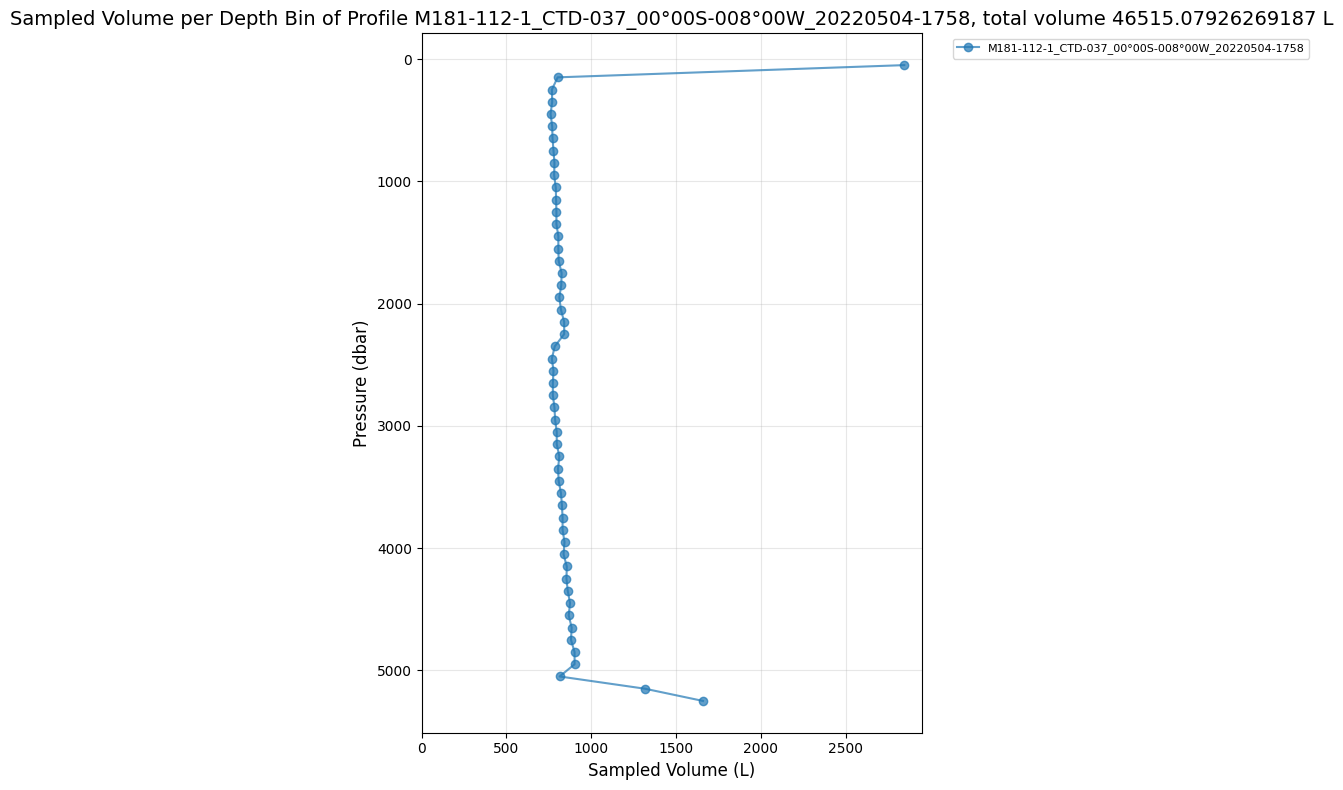

308.25912777342086


In [4]:
import matplotlib.pyplot as plt
import random

# Plot all profiles
fig, ax = plt.subplots(figsize=(10, 8))

# Randomly select 10 profiles
all_profiles = volume_df['profile'].unique()
selected_profiles = ['M181-112-1_CTD-037_00°00S-008°00W_20220504-1758']#random.sample(list(all_profiles), min(10, len(all_profiles)))

# Plot each selected profile
for profile in selected_profiles:
    profile_data = volume_df[volume_df['profile'] == profile]
    # Use the middle of each depth bin for plotting
    depth_mid = (profile_data['depth_bin_start_dbar'] + profile_data['depth_bin_end_dbar']) / 2
    ax.plot(profile_data['sampled_volume_L'], depth_mid, marker='o', label=profile, alpha=0.7)

ax.set_xlabel('Sampled Volume (L)', fontsize=12)
ax.set_ylabel('Pressure (dbar)', fontsize=12)
ax.set_title(f'Sampled Volume per Depth Bin of Profile {selected_profiles[0]}, total volume {profile_data['sampled_volume_L'].sum()} L', fontsize=14)
ax.invert_yaxis()  # Invert y-axis so surface is at top
ax.set_xlim(left=0)
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()
print(profile_data['sampled_volume_L'].std())
# Save the figure
# fig_path = os.path.join(Base_path, 'sampled_volumes_by_depth_profiles.png')
# fig.savefig(fig_path, dpi=300, bbox_inches='tight')
# print(f"\nFigure saved to: {fig_path}")
# print(f"Selected profiles: {', '.join(selected_profiles)}")

In [ ]:
import matplotlib.pyplot as plt
import random

# Plot one random profile
fig, ax = plt.subplots(figsize=(10, 8))

# Randomly select 1 profile
all_profiles = volume_df['profile'].unique()
selected_profile = random.choice(all_profiles)

# Plot the selected profile
profile_data = volume_df[volume_df['profile'] == selected_profile]
# Use the middle of each depth bin for plotting
depth_mid = (profile_data['depth_bin_start_dbar'] + profile_data['depth_bin_end_dbar']) / 2
ax.plot(profile_data['sampled_volume_L'], depth_mid, marker='o', linewidth=2, markersize=6)

ax.set_xlabel('Sampled Volume (L)', fontsize=12)
ax.set_ylabel('Pressure (dbar)', fontsize=12)
ax.set_title(f'Sampled Volume per Depth Bin\n{selected_profile}', fontsize=14)
ax.invert_yaxis()  # Invert y-axis so surface is at top
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Save the figure
fig_path = os.path.join(Base_path, f'sampled_volumes_{selected_profile}.png')
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\nFigure saved to: {fig_path}")
print(f"Selected profile: {selected_profile}")

In [33]:
def count_zooplankton_by_depth(base_path, depth_bin_size=5):
    """Count zooplankton occurrences per depth bin for each profile.
    
    Args:
        base_path: Base path containing profile folders with EcoTaxa CSV files
        depth_bin_size: Depth bin size in dbar (default: 5 dbar)
    
    Returns:
        DataFrame with profile, depth bins, category and counts
    """
    all_results = []
    
    # Iterate through all profile folders
    for profile_folder in Path(base_path).iterdir():
        #check directory and look for csv file
        if not profile_folder.is_dir():
            continue
            
        print(f"Processing {profile_folder.name}...")
        
        # Find *_Results folder
        results_folders = list(profile_folder.glob('*_Results'))
        if not results_folders:
            print(f"  Warning: No *_Results folder found")
            continue
        
        # Find EcoTaxa CSV file in Results/EcoTaxa folder
        ecotaxa_folder = results_folders[0] / 'EcoTaxa'
        if not ecotaxa_folder.exists():
            print(f"  Warning: EcoTaxa folder not found")
            continue
            
        # Look for both naming patterns
        csv_files = list(ecotaxa_folder.glob('*_crops_metadata_ET.csv'))
        if not csv_files:
            csv_files = list(ecotaxa_folder.glob('*_crops_metadata.csv'))
        
        if not csv_files:
            print(f"  Warning: No EcoTaxa CSV file found")
            continue
            
        csv_file = csv_files[0]
        print(f"  Reading {csv_file.name}")
        
        try:
            # Read CSV, skipping the second row (datatype indicator)
            df = pd.read_csv(csv_file, skiprows=[1])
            
            # Check for required columns
            if 'object_pressure' not in df.columns or 'object_annotation_category' not in df.columns:
                print(f"  Warning: Required columns not found in CSV")
                continue
            
            # Convert pressure to dbar (assuming it's in bar)
            df['pressure_dbar'] = df['object_pressure']
            
            # Assign to depth bins
            df['depth_bin'] = (df['pressure_dbar'] // depth_bin_size) * depth_bin_size
            
            # Count occurrences per depth bin and category
            counts = df.groupby(['depth_bin', 'object_annotation_category']).size().reset_index(name='count')
            
            # Add profile name and depth bin end
            counts['profile'] = profile_folder.name
            counts['depth_bin_start_dbar'] = counts['depth_bin']
            counts['depth_bin_end_dbar'] = counts['depth_bin'] + depth_bin_size
            
            # Reorder columns
            counts = counts[['profile', 'depth_bin_start_dbar', 'depth_bin_end_dbar', 
                           'object_annotation_category', 'count']]
            
            all_results.append(counts)
            print(f"  Found {len(df)} objects in {len(counts['object_annotation_category'].unique())} categories")
            
        except Exception as e:
            print(f"  Error reading CSV: {e}")
            continue
    
    # Combine all results
    if all_results:
        result_df = pd.concat(all_results, ignore_index=True)
        return result_df
    else:
        return pd.DataFrame()

# Count zooplankton occurrences - use Image_path for this
output_path = "/home/veit/PIScO_dev/Segmentation_results"
counts_df = count_zooplankton_by_depth(Image_path, depth_bin_size=100)

# Sort by profile, depth bin, and category for better organization
counts_df = counts_df.sort_values(['profile', 'depth_bin_start_dbar', 'object_annotation_category'])

print("\nZooplankton counts per depth bin per profile:")
print(counts_df.head(40))

# Save to CSV
output_file = os.path.join(output_path, 'zooplankton_counts_by_depth_per_profile.csv')
counts_df.to_csv(output_file, index=False)
print(f"\nResults saved to: {output_file}")

# Summary statistics per profile
print("\nSummary by profile:")
profile_summary = counts_df.groupby('profile').agg({
    'count': 'sum',
    'object_annotation_category': 'nunique'
}).rename(columns={'count': 'total_objects', 'object_annotation_category': 'n_categories'})
print(profile_summary)

# Overall summary
print("\nOverall Summary:")
print(f"Total profiles: {counts_df['profile'].nunique()}")
print(f"Total categories: {counts_df['object_annotation_category'].nunique()}")
print(f"Total objects: {counts_df['count'].sum()}")
print(f"\nTop 10 categories by count:")
print(counts_df.groupby('object_annotation_category')['count'].sum().sort_values(ascending=False).head(10))

# Show example of one profile's data
print("\nExample: Data for one profile:")
example_profile = counts_df['profile'].iloc[0]
example_data = counts_df[counts_df['profile'] == example_profile]
print(f"\nProfile: {example_profile}")
print(example_data.to_string(index=False))

Processing M181-083-1_CTD-028_00°00S-000°00E_20220501-0638...
  Reading M181-083-1_CTD-028_00°00S-000°00E_20220501-0638_crops_metadata.csv
  Found 65354 objects in 14 categories
Processing M181-061-1_CTD-023_06°00S-010°58E_20220427-1906...
  Reading M181-061-1_CTD-023_06°00S-010°58E_20220427-1906_crops_metadata_ET.csv
  Found 624497 objects in 14 categories
Processing M181-153-1_CTD-045_00°00S-015°00W_20220507-1251...
  Reading M181-153-1_CTD-045_00°00S-015°00W_20220507-1251_crops_metadata.csv
  Found 47754 objects in 14 categories
Processing M181-052-1_CTD-021_11°45S-011°38E_20220426-0640...
  Reading M181-052-1_CTD-021_11°45S-011°38E_20220426-0640_crops_metadata_ET.csv
  Found 234892 objects in 14 categories
Processing M181-294-1_CTD-079_00°00S-040°50W_20220518-1608...
  Reading M181-294-1_CTD-079_00°00S-040°50W_20220518-1608_crops_metadata_ET.csv
  Found 29564 objects in 14 categories
Processing M181-272-1_CTD-071_00°00S-036°00W_20220516-1313...
  Reading M181-272-1_CTD-071_00°00S-0

/tmp/ipykernel_360982/21581953.py:47: DtypeWarning: Columns (74,75,76,77) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file, skiprows=[1])


  Found 65596 objects in 14 categories
Processing M181-009-1_CTD-004_14°00S-012°12E_20220422-1342...
  Reading M181-009-1_CTD-004_14°00S-012°12E_20220422-1342_crops_metadata_ET.csv
  Found 490731 objects in 14 categories
Processing M181-185-1_CTD-052_00°00S-020°00W_20220509-1641...
  Reading M181-185-1_CTD-052_00°00S-020°00W_20220509-1641_crops_metadata.csv
  Found 122211 objects in 14 categories
Processing M181-255-1_CTD-067_00°00S-033°00W_20220515-0504...
  Reading M181-255-1_CTD-067_00°00S-033°00W_20220515-0504_crops_metadata_ET.csv
  Found 54061 objects in 14 categories
Processing M181-265-1_CTD-069_00°00S-035°00W_20220516-0101...
  Reading M181-265-1_CTD-069_00°00S-035°00W_20220516-0101_crops_metadata.csv
  Found 49187 objects in 14 categories
Processing M181-276-1_CTD-072_00°00S-037°00W_20220516-2214...
  Reading M181-276-1_CTD-072_00°00S-037°00W_20220516-2214_crops_metadata.csv
  Found 30817 objects in 14 categories
Processing M181-194-1_CTD-054_00°00S-022°00W_20220510-1440...
 

In [7]:
# Merge volume and count data
merged_df = pd.merge(
    volume_df,
    counts_df,
    on=['profile', 'depth_bin_start_dbar', 'depth_bin_end_dbar'],
    how='outer'  # Use outer join to keep all depth bins from both datasets
)

# Sort by profile, depth bin, and category
merged_df = merged_df.sort_values(['profile', 'depth_bin_start_dbar', 'object_annotation_category'])

# Calculate concentration (organisms per liter) where we have both volume and counts
merged_df['concentration_per_L'] = merged_df['count'] / merged_df['sampled_volume_L']

print("\nMerged data (volume + counts):")
print(merged_df.head(40))

# Save merged data
output_file = os.path.join(output_path, 'merged_volume_counts_by_depth_per_profile.csv')
merged_df.to_csv(output_file, index=False)
print(f"\nMerged results saved to: {output_file}")

# Summary: Check for mismatches
print("\nData quality check:")
print(f"Rows with volume but no counts: {merged_df['sampled_volume_L'].notna().sum() - merged_df['count'].notna().sum()}")
print(f"Rows with counts but no volume: {merged_df['count'].notna().sum() - merged_df['sampled_volume_L'].notna().sum()}")

# Summary per profile with concentrations
print("\nSummary by profile (with concentrations):")
profile_summary_merged = merged_df.groupby('profile').agg({
    'sampled_volume_L': 'sum',
    'count': 'sum',
    'object_annotation_category': 'nunique'
}).rename(columns={
    'sampled_volume_L': 'total_volume_L',
    'count': 'total_objects',
    'object_annotation_category': 'n_categories'
})
profile_summary_merged['avg_concentration_per_L'] = profile_summary_merged['total_objects'] / profile_summary_merged['total_volume_L']
print(profile_summary_merged)

# Show example of one profile's merged data
print("\nExample: Merged data for one profile:")
example_profile = merged_df['profile'].iloc[0]
example_merged = merged_df[merged_df['profile'] == example_profile]
print(f"\nProfile: {example_profile}")
print(example_merged.to_string(index=False))


Merged data (volume + counts):
                                            profile  depth_bin_start_dbar  \
0   M181-002-1_CTD-001_17°00S-011°11E_20220421-1614                     5   
1   M181-002-1_CTD-001_17°00S-011°11E_20220421-1614                     5   
2   M181-002-1_CTD-001_17°00S-011°11E_20220421-1614                     5   
3   M181-002-1_CTD-001_17°00S-011°11E_20220421-1614                     5   
4   M181-002-1_CTD-001_17°00S-011°11E_20220421-1614                    10   
5   M181-002-1_CTD-001_17°00S-011°11E_20220421-1614                    10   
6   M181-002-1_CTD-001_17°00S-011°11E_20220421-1614                    10   
7   M181-002-1_CTD-001_17°00S-011°11E_20220421-1614                    10   
8   M181-002-1_CTD-001_17°00S-011°11E_20220421-1614                    10   
9   M181-002-1_CTD-001_17°00S-011°11E_20220421-1614                    10   
10  M181-002-1_CTD-001_17°00S-011°11E_20220421-1614                    10   
11  M181-002-1_CTD-001_17°00S-011°11E_202204

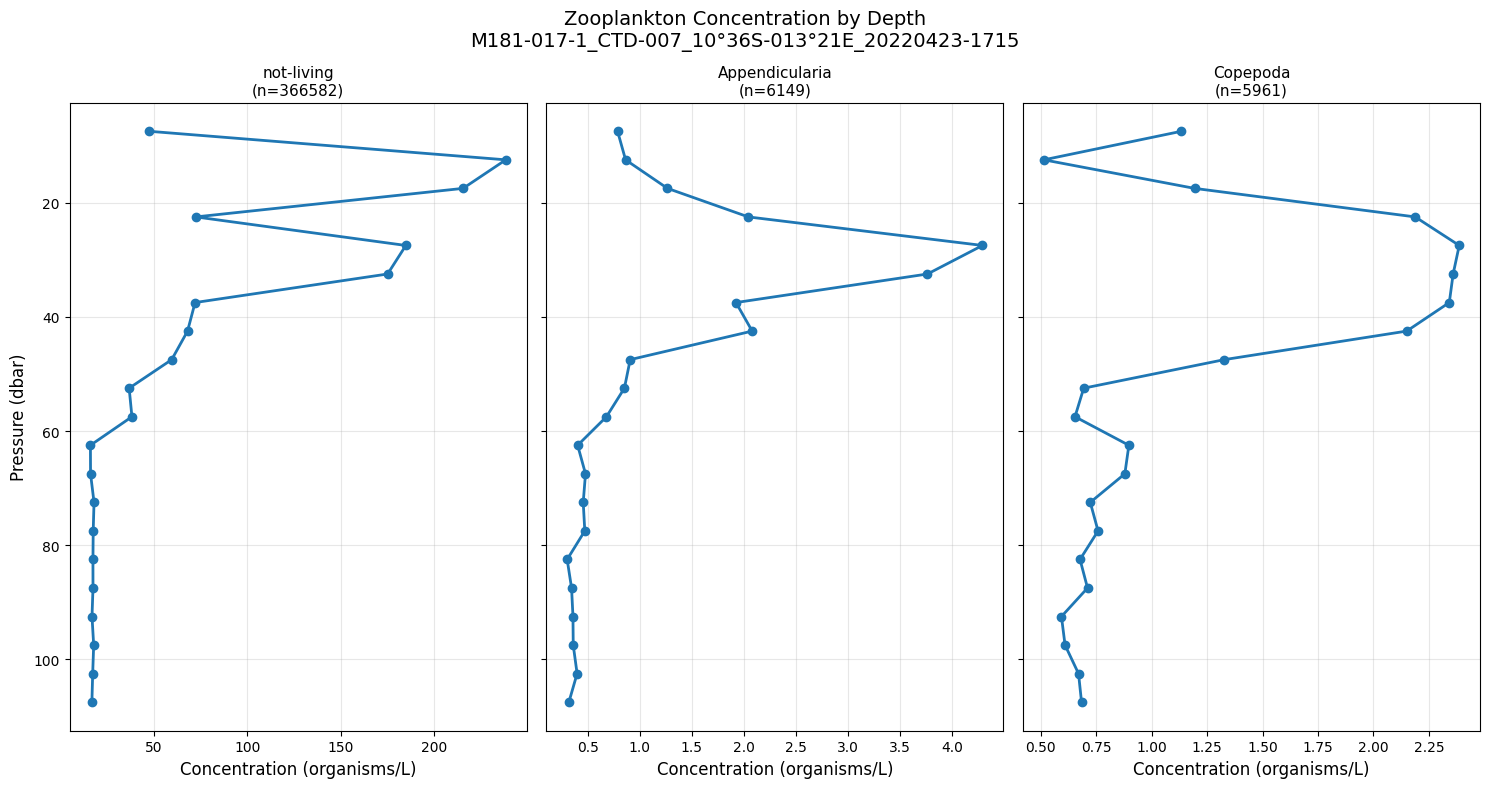


Figure saved to: /home/veit/PIScO_dev/Segmentation_results/concentration_profile_M181-017-1_CTD-007_10°36S-013°21E_20220423-1715.png
Selected profile: M181-017-1_CTD-007_10°36S-013°21E_20220423-1715
Categories shown: not-living, Appendicularia, Copepoda


In [12]:
import matplotlib.pyplot as plt
import random

# Select a random profile that has concentration data
profiles_with_data = merged_df[merged_df['concentration_per_L'].notna()]['profile'].unique()
selected_profile = random.choice(profiles_with_data)

# Get data for selected profile
profile_data = merged_df[merged_df['profile'] == selected_profile].copy()

# Calculate depth midpoints
profile_data['depth_mid'] = (profile_data['depth_bin_start_dbar'] + profile_data['depth_bin_end_dbar']) / 2

# Create figure with subplots for each category
categories = profile_data['object_annotation_category'].dropna().unique()
n_categories = len(categories)

fig, axes = plt.subplots(1, min(3, n_categories), figsize=(15, 8), sharey=True)
if n_categories == 1:
    axes = [axes]
elif n_categories == 2:
    axes = list(axes)

# Plot up to 3 most abundant categories
category_totals = profile_data.groupby('object_annotation_category')['count'].sum().sort_values(ascending=False)
top_categories = category_totals.head(3).index

for idx, category in enumerate(top_categories):
    ax = axes[idx]
    cat_data = profile_data[profile_data['object_annotation_category'] == category]
    
    ax.plot(cat_data['concentration_per_L'], cat_data['depth_mid'], 
            marker='o', linewidth=2, markersize=6, label=category)
    ax.set_xlabel('Concentration (organisms/L)', fontsize=12)
    if idx == 0:
        ax.set_ylabel('Pressure (dbar)', fontsize=12)
    ax.set_title(f'{category}\n(n={int(cat_data["count"].sum())})', fontsize=11)
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Zooplankton Concentration by Depth\n{selected_profile}', fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

# Save the figure
fig_path = os.path.join(output_path, f'concentration_profile_{selected_profile}.png')
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\nFigure saved to: {fig_path}")
print(f"Selected profile: {selected_profile}")
print(f"Categories shown: {', '.join(top_categories)}")

In [7]:
def process_single_profile_tsv(tsv_file_path, image_folder_path, profile_name, mask_radius, depth_bin_size=5):
    """Process a single profile TSV file and calculate concentrations per depth bin.
    
    Args:
        tsv_file_path: Path to the TSV file (EcoTaxa format)
        image_folder_path: Path to folder containing PNG images for this profile
        profile_name: Name/identifier for the profile
        mask_radius: Mask radius in pixels (for volume calculation)
        depth_bin_size: Depth bin size in dbar (default: 5 dbar)
    
    Returns:
        DataFrame with profile, depth bins, categories, counts, volumes and concentrations
    """
    print(f"Processing {profile_name}...")
    
    # Calculate volume per image
    volume_per_image = calculate_volume(mask_radius)
    print(f"  Mask radius: {mask_radius} pixels, Volume per image: {volume_per_image:.6f} L")
    
    # Calculate exact volumes per depth bin from actual images
    png_folder = Path(image_folder_path) / 'PNG'
    if not png_folder.exists():
        print(f"  Error: PNG folder not found at {png_folder}")
        return pd.DataFrame()
    
    image_files = list(png_folder.glob('*.png'))
    print(f"  Found {len(image_files)} images")
    
    # Track volumes per depth bin
    volumes_by_depth = defaultdict(float)
    
    for image_file in image_files:
        pressure_bar = extract_pressure_from_filename(image_file.name)
        if pressure_bar is not None:
            # Convert pressure in bar to dbar (1 bar = 10 dbar)
            pressure_dbar = pressure_bar * 10
            
            # Assign to depth bin
            depth_bin = int(pressure_dbar // depth_bin_size) * depth_bin_size
            volumes_by_depth[depth_bin] += volume_per_image
    
    print(f"  Calculated volumes for {len(volumes_by_depth)} depth bins")
    
    # Now process the TSV file for counts
    try:
        # Read TSV file, skipping the second row (datatype indicator)
        df = pd.read_csv(tsv_file_path, sep='\t', skiprows=[1])
        
        # Check for required columns
        if 'object_pressure' not in df.columns or 'object_annotation_category' not in df.columns:
            print(f"  Error: Required columns not found in TSV")
            return pd.DataFrame()
        
        # Convert pressure to dbar (assuming it's in bar)
        df['pressure_dbar'] = df['object_pressure']
        
        # Calculate individual biovolume from ESD (assuming ESD is in mm)
        # Volume of sphere = (4/3) * π * r³ = (π/6) * d³
        if 'object_esd' in df.columns:
            esd_mm = df['object_esd'] / 1000  # µm to mm
            df['biovolume_mm3'] = (np.pi / 6) * (esd_mm ** 3)
        else:
            print(f"  Warning: object_esd column not found, biovolume will not be calculated")
            df['biovolume_mm3'] = 0
        
        # Assign to depth bins
        df['depth_bin'] = (df['pressure_dbar'] // depth_bin_size) * depth_bin_size
        
        # Count occurrences and sum biovolume per depth bin and category
        counts = df.groupby(['depth_bin', 'object_annotation_category']).agg({
            'biovolume_mm3': 'sum',  # Total biovolume in mm³
            'object_annotation_category': 'size',  # Count of objects
        }).rename(columns={'object_annotation_category': 'count'}).reset_index()
        
        # Add sampled volume from our calculated volumes
        counts['sampled_volume_L'] = counts['depth_bin'].map(volumes_by_depth)
        
        # Add profile information
        counts['profile'] = profile_name
        counts['depth_bin_start_dbar'] = counts['depth_bin']
        counts['depth_bin_end_dbar'] = counts['depth_bin'] + depth_bin_size
        
        # Calculate concentration (organisms per liter)
        counts['concentration_per_L'] = counts['count'] / counts['sampled_volume_L']
        
        # Calculate biovolume per liter (mm³/L)
        counts['biovolume_mm3_per_L'] = counts['biovolume_mm3'] / counts['sampled_volume_L']
        
        # Reorder columns
        counts = counts[['profile', 'depth_bin_start_dbar', 'depth_bin_end_dbar', 
                        'object_annotation_category', 'count', 'biovolume_mm3',
                        'sampled_volume_L', 'concentration_per_L', 'biovolume_mm3_per_L']]
        
        print(f"  Found {len(df)} objects in {len(counts['object_annotation_category'].unique())} categories")
        print(f"  Depth range: {df['pressure_dbar'].min():.1f} - {df['pressure_dbar'].max():.1f} dbar")
        print(f"  Total organisms: {counts['count'].sum()}")
        print(f"  total sampled volume: {counts.groupby(['depth_bin_start_dbar', 'depth_bin_end_dbar'])['sampled_volume_L'].first().sum():.2f} L") 
        print(f"  Total biovolume: {counts['biovolume_mm3'].sum():.2f} mm³")
        
        return counts
        
    except Exception as e:
        print(f"  Error processing TSV: {e}")
        return pd.DataFrame()


# Example usage:
tsv_path = "/home/veit/PIScO_dev/Segmentation_results/PISCO_CTD037_data.tsv"
image_folder_path = "/mnt/filer/M181/M181-PISCO-Profiles/M181-112-1_CTD-037_00°00S-008°00W_20220504-1758"
profile_name = "M181-112-1_CTD-037_00°00S-008°00W_20220504-1758"
mask_radius = 1550  # pixels

result_df = process_single_profile_tsv(tsv_path, image_folder_path, profile_name, mask_radius, depth_bin_size=1000)

# Display results
print("\nResults:")
print(result_df)

# Save to CSV
output_file = "/home/veit/PIScO_dev/Segmentation_results/profile_concentrations.csv"
result_df.to_csv(output_file, index=False)
print(f"\nSaved to: {output_file}")

# Summary statistics
print("\nSummary:")
print(f"Total organisms: {result_df['count'].sum()}")
print(f"Total biovolume: {result_df['biovolume_mm3'].sum():.2f} mm³")
print(f"Average biovolume per organism: {result_df['biovolume_mm3'].sum() / result_df['count'].sum():.4f} mm³")
print(f"\nTop categories by biovolume:")
print(result_df.groupby('object_annotation_category')['biovolume_mm3'].sum().sort_values(ascending=False).head(10))

Processing M181-112-1_CTD-037_00°00S-008°00W_20220504-1758...
  Mask radius: 1550 pixels, Volume per image: 1.910506 L
  Found 24347 images
  Calculated volumes for 6 depth bins
  Found 3550 objects in 6 categories
  Depth range: 10.3 - 5277.5 dbar
  Total organisms: 3550
  total sampled volume: 46515.08 L
  Total biovolume: 13060.52 mm³

Results:
                                            profile  depth_bin_start_dbar  \
0   M181-112-1_CTD-037_00°00S-008°00W_20220504-1758                   0.0   
1   M181-112-1_CTD-037_00°00S-008°00W_20220504-1758                   0.0   
2   M181-112-1_CTD-037_00°00S-008°00W_20220504-1758                   0.0   
3   M181-112-1_CTD-037_00°00S-008°00W_20220504-1758                   0.0   
4   M181-112-1_CTD-037_00°00S-008°00W_20220504-1758                   0.0   
5   M181-112-1_CTD-037_00°00S-008°00W_20220504-1758                   0.0   
6   M181-112-1_CTD-037_00°00S-008°00W_20220504-1758                1000.0   
7   M181-112-1_CTD-037_00°00S-008°

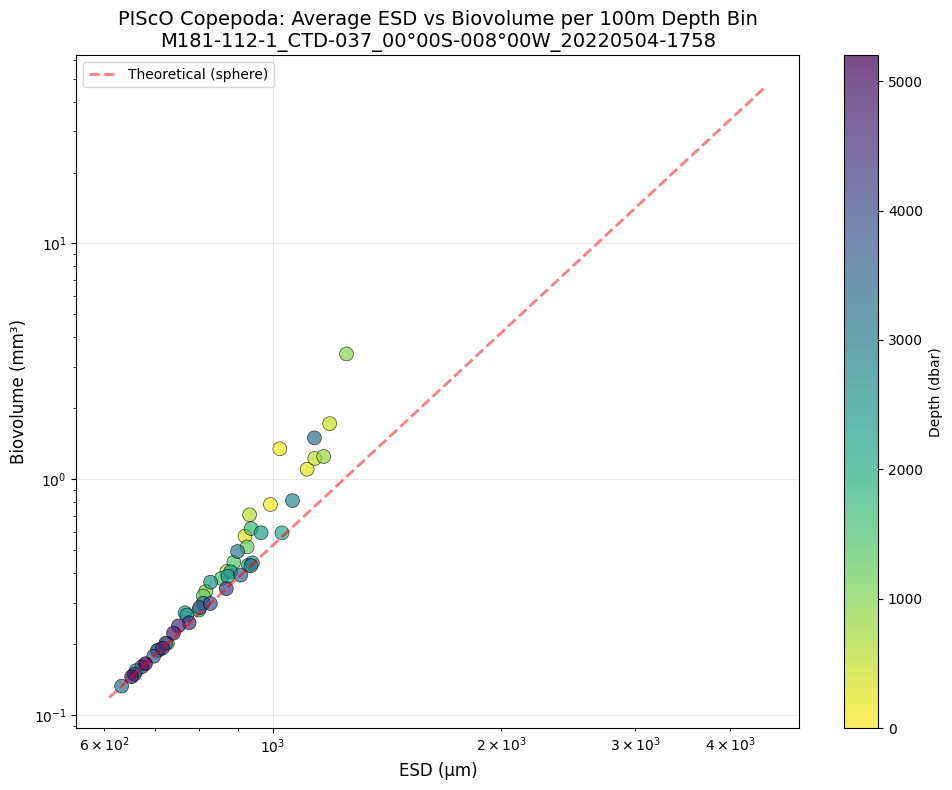


Figure saved to: /home/veit/PIScO_dev/Segmentation_results/copepod_esd_biovolume_by_depth.png

Copepoda statistics per 100m depth bin:
 depth_bin_100m  object_esd  biovolume_mm3
            0.0  993.302366       0.781628
          100.0 1022.146292       1.346569
          200.0  919.900930       0.573756
          300.0 1110.287551       1.102845
          400.0 1188.684444       1.722272
          500.0 1136.203889       1.226180
          600.0  932.592308       0.706922
          700.0  870.906250       0.406881
          800.0 1167.270000       1.249258
          900.0  816.688000       0.334477
         1000.0 1250.964000       3.400981
         1100.0  726.955000       0.201577
         1200.0  925.647500       0.516472
         1300.0  810.535000       0.319838
         1400.0  889.123333       0.444586
         1500.0  856.243333       0.379765
         1600.0  707.820000       0.188637
         1700.0  936.845000       0.617959
         1800.0  799.875000       0.278930
    

In [22]:
import matplotlib.pyplot as plt

# Filter for Copepoda and create 100m depth bins
copepod_data = result_df[result_df['object_annotation_category'].str.contains('Copepod', case=False, na=False)].copy()

# Read the original TSV to get individual ESD values
df_full = pd.read_csv(tsv_path, sep='\t', skiprows=[1])
df_full['pressure_dbar'] = df_full['object_pressure']

# Filter for Copepoda
copepod_individuals = df_full[df_full['object_annotation_category'].str.contains('Copepod', case=False, na=False)].copy()

# Create 100m depth bins (100 dbar ≈ 100m)
copepod_individuals['depth_bin_100m'] = (copepod_individuals['pressure_dbar'] // 100) * 100

# Calculate biovolume for each individual
if 'object_esd' in copepod_individuals.columns:
    esd_mm = copepod_individuals['object_esd'] / 1000  # µm to mm
    copepod_individuals['biovolume_mm3'] = (np.pi / 6) * (esd_mm ** 3)
    
    # Calculate average per 100m depth bin
    depth_averages = copepod_individuals.groupby('depth_bin_100m').agg({
        'object_esd': 'mean',  # Average ESD in µm
        'biovolume_mm3': 'mean'  # Average biovolume in mm³
    }).reset_index()
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Color code by depth
    scatter = ax.scatter(depth_averages['object_esd'], 
                        depth_averages['biovolume_mm3'],
                        c=depth_averages['depth_bin_100m'],
                        cmap='viridis_r',  # reversed so shallow is yellow, deep is blue
                        s=100,
                        alpha=0.7,
                        edgecolors='black',
                        linewidth=0.5)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax, label='Depth (dbar)')
    
    # Add theoretical line (sphere volume formula)
    esd_range = np.linspace(copepod_individuals['object_esd'].min(), 
                           copepod_individuals['object_esd'].max(), 100)
    theoretical_biovol = (np.pi / 6) * ((esd_range / 1000) ** 3)  # Convert µm to mm
    ax.plot(esd_range, theoretical_biovol, 'r--', alpha=0.5, 
            label='Theoretical (sphere)', linewidth=2)
    
    ax.set_xlabel('ESD (µm)', fontsize=12)
    ax.set_ylabel('Biovolume (mm³)', fontsize=12)
    ax.set_title(f'PIScO Copepoda: Average ESD vs Biovolume per 100m Depth Bin\n{profile_name}', 
                fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Log scale might be better for large range
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    plt.tight_layout()
    plt.show()
    
    # Save figure
    fig_path = "/home/veit/PIScO_dev/Segmentation_results/copepod_esd_biovolume_by_depth.png"
    fig.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f"\nFigure saved to: {fig_path}")
    
    # Print summary statistics
    print("\nCopepoda statistics per 100m depth bin:")
    print(depth_averages.to_string(index=False))
    print(f"\nTotal copepods analyzed: {len(copepod_individuals)}")
    
else:
    print("Error: object_esd column not found")

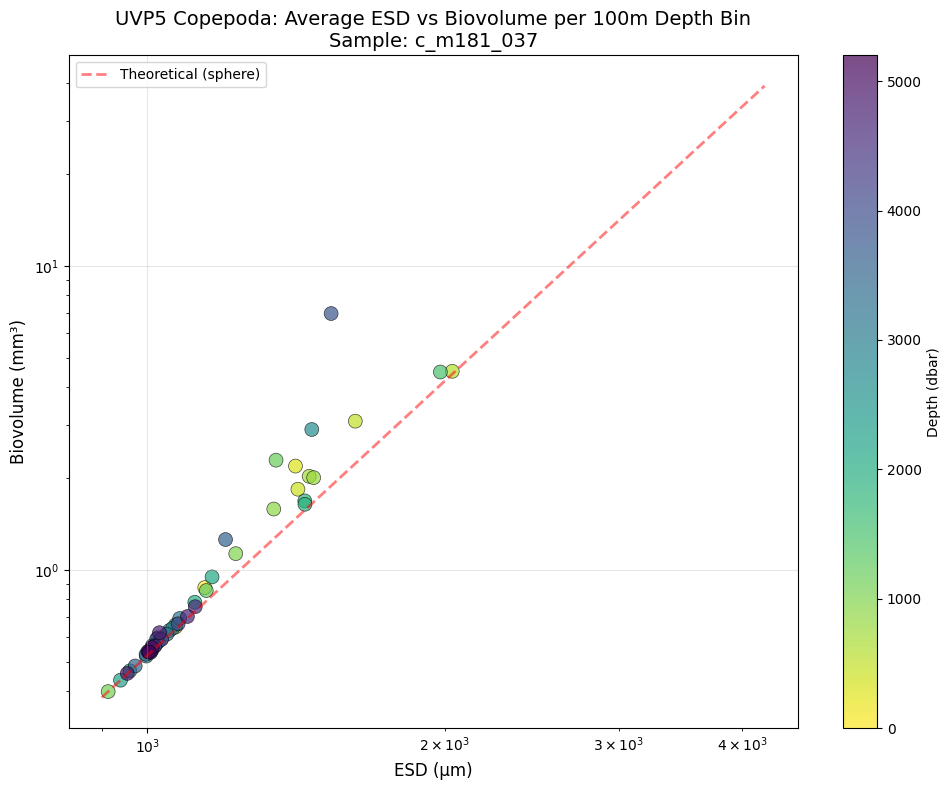


Figure saved to: /home/veit/PIScO_dev/Segmentation_results/c_m181_037_copepod_esd_biovolume_by_depth.png

Copepoda statistics per 100m depth bin:
 depth_bin_100m      esd_um  biovolume_mm3
            0.0 1143.130490       0.875438
          100.0 1034.245065       0.597582
          200.0 1068.057612       0.649523
          300.0 1412.151911       2.197338
          400.0 1420.111060       1.844195
          500.0 1623.302567       3.087385
          600.0 2034.651387       4.504648
          700.0 1457.867337       2.033706
          800.0 1473.202619       2.012866
          900.0 1342.497044       1.587032
         1000.0 1228.703509       1.131974
         1100.0  912.775943       0.398201
         1200.0 1349.610665       2.297776
         1300.0 1147.098296       0.856016
         1500.0 1979.019137       4.480898
         1600.0 1019.700631       0.567221
         1700.0 1067.802661       0.659873
         1800.0 1443.094468       1.687966
         1900.0 1443.617476       1.

In [23]:
tsv_path_multi = "/home/veit/PIScO_dev/Segmentation_results/ecotaxa_export__TSV_17905_20251113_1239.tsv"
sample_id = "c_m181_037"

# Read the TSV file
df_full = pd.read_csv(tsv_path_multi, sep='\t', skiprows=[1])

# Filter for specific sample
df_full = df_full[df_full['sample_id'] == sample_id].copy()

# Combine Calanoida and Copepoda<Maxillopoda
df_full.loc[df_full['object_annotation_category'] == 'Calanoida', 'object_annotation_category'] = 'Copepoda<Maxillopoda'

# Filter for Copepoda
copepod_individuals = df_full[df_full['object_annotation_category'].str.contains('Copepod', case=False, na=False)].copy()

# Convert depth to dbar (object_depth_min is already in dbar)
copepod_individuals['pressure_dbar'] = copepod_individuals['object_depth_min']

# Create 100m depth bins (100 dbar ≈ 100m)
copepod_individuals['depth_bin_100m'] = (copepod_individuals['pressure_dbar'] // 100) * 100

# Calculate biovolume for each individual
if 'object_esd' in copepod_individuals.columns:
    # ESD is in pixels, convert to mm: pixels * 88 µm/pixel / 1000
    esd_mm = copepod_individuals['object_esd'] * 88 / 1000  # pixels to mm
    copepod_individuals['biovolume_mm3'] = (np.pi / 6) * (esd_mm ** 3)
    
    # Convert ESD to µm for plotting
    copepod_individuals['esd_um'] = copepod_individuals['object_esd'] * 88  # pixels to µm
    
    # Calculate average per 100m depth bin
    depth_averages = copepod_individuals.groupby('depth_bin_100m').agg({
        'esd_um': 'mean',  # Average ESD in µm
        'biovolume_mm3': 'mean'  # Average biovolume in mm³
    }).reset_index()
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Color code by depth
    scatter = ax.scatter(depth_averages['esd_um'], 
                        depth_averages['biovolume_mm3'],
                        c=depth_averages['depth_bin_100m'],
                        cmap='viridis_r',  # reversed so shallow is yellow, deep is blue
                        s=100,
                        alpha=0.7,
                        edgecolors='black',
                        linewidth=0.5)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax, label='Depth (dbar)')
    
    # Add theoretical line (sphere volume formula)
    esd_range_um = np.linspace(copepod_individuals['esd_um'].min(), 
                               copepod_individuals['esd_um'].max(), 100)
    theoretical_biovol = (np.pi / 6) * ((esd_range_um / 1000) ** 3)  # Convert µm to mm
    ax.plot(esd_range_um, theoretical_biovol, 'r--', alpha=0.5, 
            label='Theoretical (sphere)', linewidth=2)
    
    ax.set_xlabel('ESD (µm)', fontsize=12)
    ax.set_ylabel('Biovolume (mm³)', fontsize=12)
    ax.set_title(f'UVP5 Copepoda: Average ESD vs Biovolume per 100m Depth Bin\nSample: {sample_id}', 
                fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Log scale for better visualization
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    plt.tight_layout()
    plt.show()
    
    # Save figure
    fig_path = f"/home/veit/PIScO_dev/Segmentation_results/{sample_id}_copepod_esd_biovolume_by_depth.png"
    fig.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f"\nFigure saved to: {fig_path}")
    
    # Print summary statistics
    print("\nCopepoda statistics per 100m depth bin:")
    print(depth_averages.to_string(index=False))
    print(f"\nTotal copepods analyzed: {len(copepod_individuals)}")
    
else:
    print("Error: object_esd column not found")

/tmp/ipykernel_247054/1609659171.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(fontsize=10)


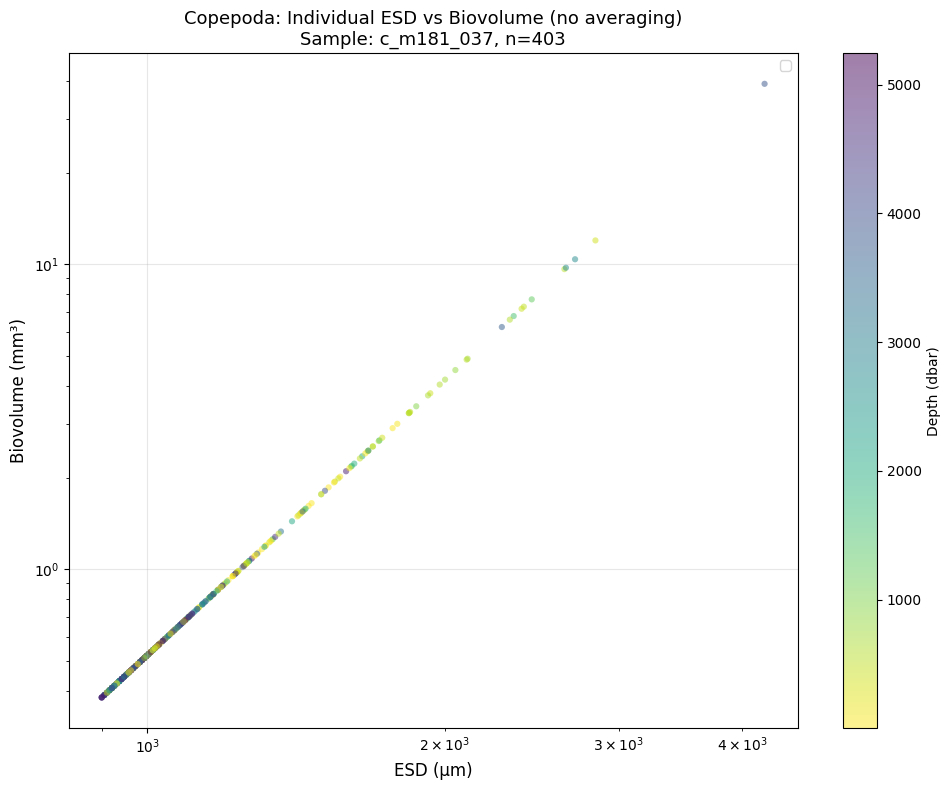


Figure 1 (individual points) saved to: /home/veit/PIScO_dev/Segmentation_results/c_m181_037_copepod_esd_biovolume_individual.png


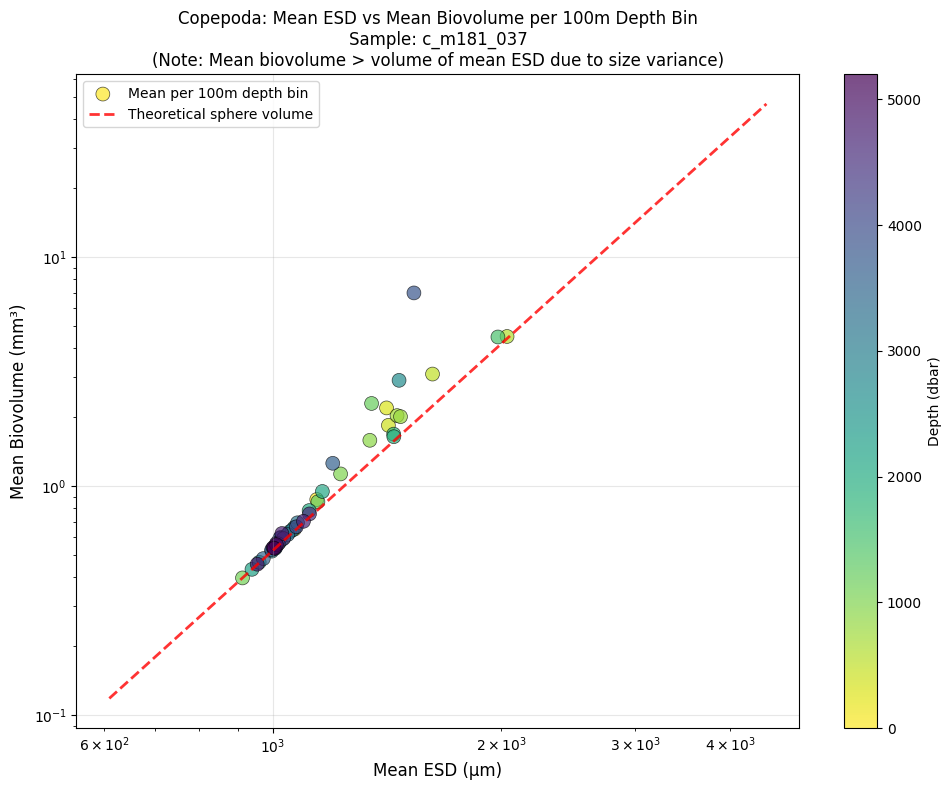

Figure 2 (depth bin averages) saved to: /home/veit/PIScO_dev/Segmentation_results/c_m181_037_copepod_esd_biovolume_by_depth.png

INDIVIDUAL COPEPODS:
Total copepods analyzed: 403
ESD range: 899.2 - 4211.7 µm
Biovolume range: 0.380656 - 39.116371 mm³

DEPTH BIN AVERAGES (100m):
 depth_bin_100m      esd_um  biovolume_mm3
            0.0 1143.130490       0.875438
          100.0 1034.245065       0.597582
          200.0 1068.057612       0.649523
          300.0 1412.151911       2.197338
          400.0 1420.111060       1.844195
          500.0 1623.302567       3.087385
          600.0 2034.651387       4.504648
          700.0 1457.867337       2.033706
          800.0 1473.202619       2.012866
          900.0 1342.497044       1.587032
         1000.0 1228.703509       1.131974
         1100.0  912.775943       0.398201
         1200.0 1349.610665       2.297776
         1300.0 1147.098296       0.856016
         1500.0 1979.019137       4.480898
         1600.0 1019.700631       

In [28]:
tsv_path_multi = "/home/veit/PIScO_dev/Segmentation_results/ecotaxa_export__TSV_17905_20251113_1239.tsv"
sample_id = "c_m181_037"

# Read the TSV file
df_full = pd.read_csv(tsv_path_multi, sep='\t', skiprows=[1])

# Filter for specific sample
df_full = df_full[df_full['sample_id'] == sample_id].copy()

# Combine Calanoida and Copepoda<Maxillopoda
df_full.loc[df_full['object_annotation_category'] == 'Calanoida', 'object_annotation_category'] = 'Copepoda<Maxillopoda'

# Filter for Copepoda
copepod_individuals = df_full[df_full['object_annotation_category'].str.contains('Copepod', case=False, na=False)].copy()

# Convert depth to dbar (object_depth_min is already in dbar)
copepod_individuals['pressure_dbar'] = copepod_individuals['object_depth_min']

# Calculate biovolume for each individual
if 'object_esd' in copepod_individuals.columns:
    # ESD is in pixels, convert to mm: pixels * 88 µm/pixel / 1000
    esd_mm = copepod_individuals['object_esd'] * 88 / 1000  # pixels to mm
    copepod_individuals['biovolume_mm3'] = (np.pi / 6) * (esd_mm ** 3)
    
    # Convert ESD to µm for plotting
    copepod_individuals['esd_um'] = copepod_individuals['object_esd'] * 88  # pixels to µm
    
    # Create TWO plots: one with individual points, one with depth bin averages
    
    # ============ PLOT 1: Individual copepods (no averaging) ============
    fig1, ax1 = plt.subplots(figsize=(10, 8))
    
    # Plot each individual copepod, color-coded by depth
    scatter1 = ax1.scatter(copepod_individuals['esd_um'], 
                          copepod_individuals['biovolume_mm3'],
                          c=copepod_individuals['pressure_dbar'],
                          cmap='viridis_r',
                          s=20,
                          alpha=0.5,
                          edgecolors='none')
    
    # Add colorbar
    cbar1 = plt.colorbar(scatter1, ax=ax1, label='Depth (dbar)')
    
    # Add theoretical line
    # esd_range_um = np.linspace(copepod_individuals['esd_um'].min(), 
    #                            copepod_individuals['esd_um'].max(), 100)
    # theoretical_biovol = (np.pi / 6) * ((esd_range_um / 1000) ** 3)
    # ax1.plot(esd_range_um, theoretical_biovol, 'r--', alpha=0.8, 
    #         label='Theoretical sphere volume', linewidth=2)
    
    ax1.set_xlabel('ESD (µm)', fontsize=12)
    ax1.set_ylabel('Biovolume (mm³)', fontsize=12)
    ax1.set_title(f'Copepoda: Individual ESD vs Biovolume (no averaging)\nSample: {sample_id}, n={len(copepod_individuals)}', 
                fontsize=13)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    
    plt.tight_layout()
    plt.show()
    
    # Save figure 1
    fig1_path = f"/home/veit/PIScO_dev/Segmentation_results/{sample_id}_copepod_esd_biovolume_individual.png"
    fig1.savefig(fig1_path, dpi=300, bbox_inches='tight')
    print(f"\nFigure 1 (individual points) saved to: {fig1_path}")
    
    
    # ============ PLOT 2: Depth bin averages (100m bins) ============
    # Create 100m depth bins
    copepod_individuals['depth_bin_100m'] = (copepod_individuals['pressure_dbar'] // 100) * 100
    
    # Calculate average per 100m depth bin
    depth_averages = copepod_individuals.groupby('depth_bin_100m').agg({
        'esd_um': 'mean',
        'biovolume_mm3': 'mean'
    }).reset_index()
    
    fig2, ax2 = plt.subplots(figsize=(10, 8))
    
    # Plot depth bin averages
    scatter2 = ax2.scatter(depth_averages['esd_um'], 
                          depth_averages['biovolume_mm3'],
                          c=depth_averages['depth_bin_100m'],
                          cmap='viridis_r',
                          s=100,
                          alpha=0.7,
                          edgecolors='black',
                          linewidth=0.5,
                          label='Mean per 100m depth bin')
    
    # Add colorbar
    cbar2 = plt.colorbar(scatter2, ax=ax2, label='Depth (dbar)')
    
    # Add theoretical line
    ax2.plot(esd_range_um, theoretical_biovol, 'r--', alpha=0.8, 
            label='Theoretical sphere volume', linewidth=2)
    
    ax2.set_xlabel('Mean ESD (µm)', fontsize=12)
    ax2.set_ylabel('Mean Biovolume (mm³)', fontsize=12)
    ax2.set_title(f'Copepoda: Mean ESD vs Mean Biovolume per 100m Depth Bin\nSample: {sample_id}\n(Note: Mean biovolume > volume of mean ESD due to size variance)', 
                fontsize=12)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    
    plt.tight_layout()
    plt.show()
    
    # Save figure 2
    fig2_path = f"/home/veit/PIScO_dev/Segmentation_results/{sample_id}_copepod_esd_biovolume_by_depth.png"
    fig2.savefig(fig2_path, dpi=300, bbox_inches='tight')
    print(f"Figure 2 (depth bin averages) saved to: {fig2_path}")
    
    # Print summary statistics
    print("\n" + "="*60)
    print("INDIVIDUAL COPEPODS:")
    print(f"Total copepods analyzed: {len(copepod_individuals)}")
    print(f"ESD range: {copepod_individuals['esd_um'].min():.1f} - {copepod_individuals['esd_um'].max():.1f} µm")
    print(f"Biovolume range: {copepod_individuals['biovolume_mm3'].min():.6f} - {copepod_individuals['biovolume_mm3'].max():.6f} mm³")
    
    print("\n" + "="*60)
    print("DEPTH BIN AVERAGES (100m):")
    print(depth_averages.to_string(index=False))
    
else:
    print("Error: object_esd column not found")

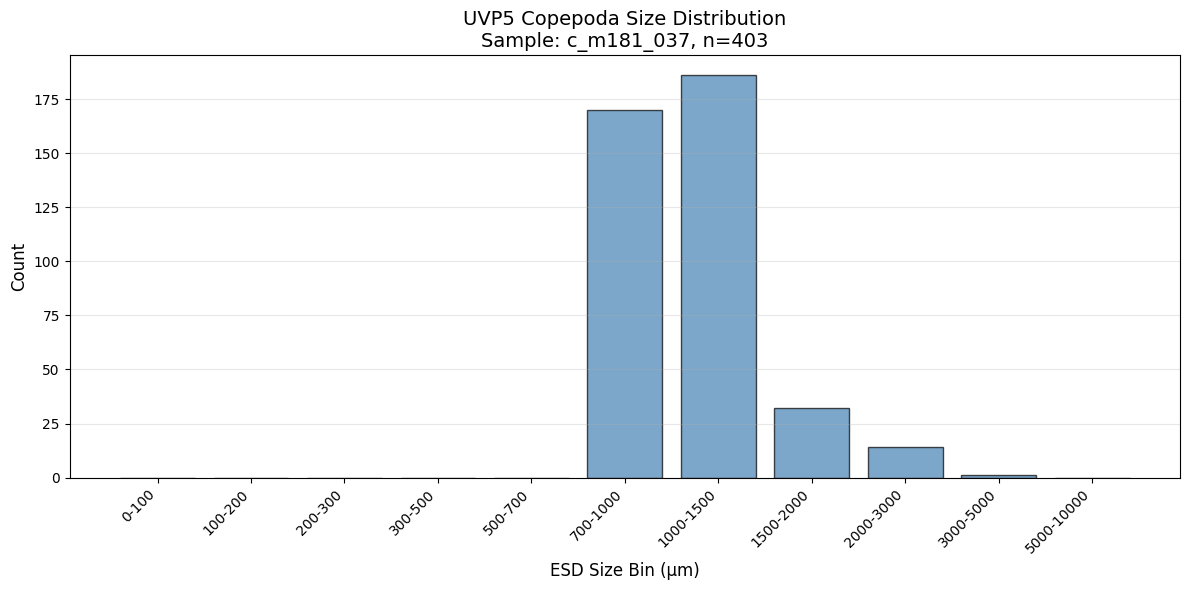


Figure 1 (size distribution) saved to: /home/veit/PIScO_dev/Segmentation_results/c_m181_037_copepod_size_distribution.png


/tmp/ipykernel_247054/1946354377.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_depth_counts = copepod_individuals.groupby(['depth_bin_100m', 'size_bin']).size().unstack(fill_value=0)


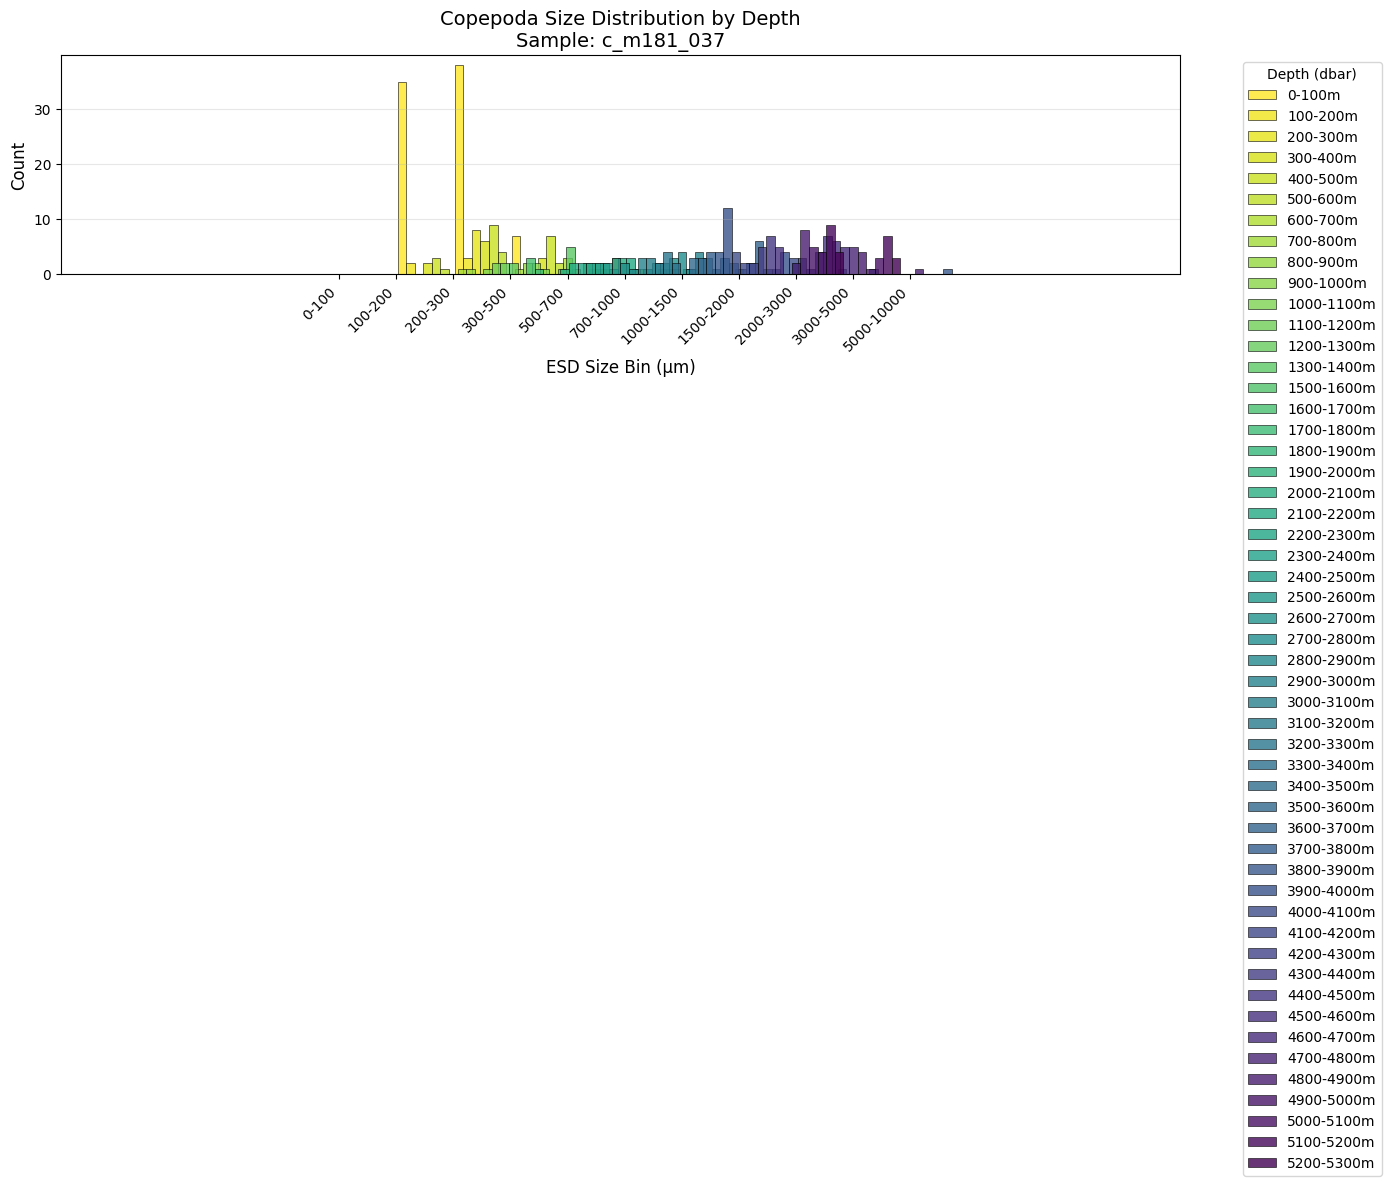

Figure 2 (size by depth) saved to: /home/veit/PIScO_dev/Segmentation_results/c_m181_037_copepod_size_by_depth.png


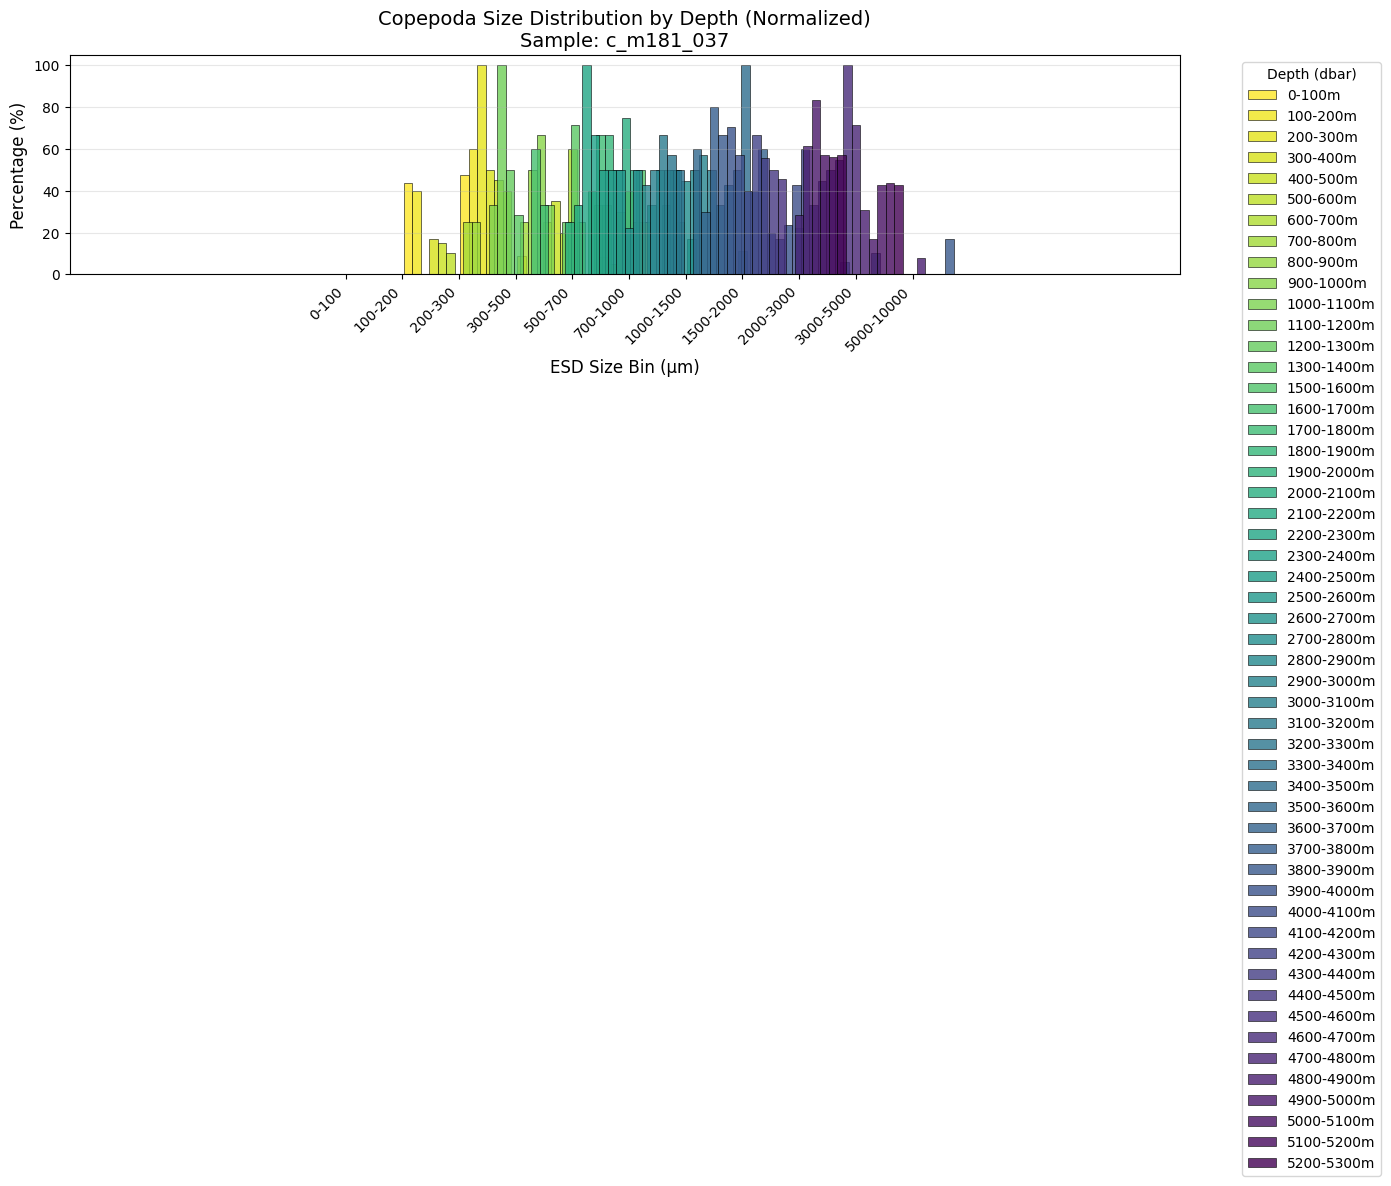

Figure 3 (normalized size by depth) saved to: /home/veit/PIScO_dev/Segmentation_results/c_m181_037_copepod_size_by_depth_normalized.png

SIZE DISTRIBUTION SUMMARY:

Counts per size bin (all depths):
size_bin
0-100           0
100-200         0
200-300         0
300-500         0
500-700         0
700-1000      170
1000-1500     186
1500-2000      32
2000-3000      14
3000-5000       1
5000-10000      0

COUNTS PER SIZE BIN AND DEPTH:
size_bin        0-100  100-200  200-300  300-500  500-700  700-1000  1000-1500  1500-2000  2000-3000  3000-5000  5000-10000
depth_bin_100m                                                                                                             
0.0                 0        0        0        0        0        35         38          7          0          0           0
100.0               0        0        0        0        0         2          3          0          0          0           0
200.0               0        0        0        0        0         

In [27]:
tsv_path_multi = "/home/veit/PIScO_dev/Segmentation_results/ecotaxa_export__TSV_17905_20251113_1239.tsv"
sample_id = "c_m181_037"

# Read the TSV file
df_full = pd.read_csv(tsv_path_multi, sep='\t', skiprows=[1])

# Filter for specific sample
df_full = df_full[df_full['sample_id'] == sample_id].copy()

# Combine Calanoida and Copepoda<Maxillopoda
df_full.loc[df_full['object_annotation_category'] == 'Calanoida', 'object_annotation_category'] = 'Copepoda<Maxillopoda'

# Filter for Copepoda
copepod_individuals = df_full[df_full['object_annotation_category'].str.contains('Copepod', case=False, na=False)].copy()

# Convert depth to dbar (object_depth_min is already in dbar)
copepod_individuals['pressure_dbar'] = copepod_individuals['object_depth_min']

# Calculate biovolume for each individual
if 'object_esd' in copepod_individuals.columns:
    # ESD is in pixels, convert to mm: pixels * 88 µm/pixel / 1000
    esd_mm = copepod_individuals['object_esd'] * 88 / 1000  # pixels to mm
    copepod_individuals['biovolume_mm3'] = (np.pi / 6) * (esd_mm ** 3)
    
    # Convert ESD to µm for plotting
    copepod_individuals['esd_um'] = copepod_individuals['object_esd'] * 88  # pixels to µm
    
    # Create 100m depth bins
    copepod_individuals['depth_bin_100m'] = (copepod_individuals['pressure_dbar'] // 100) * 100
    
    # ============ NEW: Create ESD size bins ============
    # Define size bins (in µm) - logarithmic bins work well for plankton
    size_bins = [0, 100, 200, 300, 500, 700, 1000, 1500, 2000, 3000, 5000, 10000]
    size_bin_labels = [f'{size_bins[i]}-{size_bins[i+1]}' for i in range(len(size_bins)-1)]
    
    # Assign each copepod to a size bin
    copepod_individuals['size_bin'] = pd.cut(copepod_individuals['esd_um'], 
                                              bins=size_bins, 
                                              labels=size_bin_labels,
                                              include_lowest=True)
    
    # ============ PLOT 1: Size distribution (all depths combined) ============
    fig1, ax1 = plt.subplots(figsize=(12, 6))
    
    # Count copepods per size bin
    size_counts = copepod_individuals['size_bin'].value_counts().sort_index()
    
    # Create bar plot
    ax1.bar(range(len(size_counts)), size_counts.values, 
            color='steelblue', alpha=0.7, edgecolor='black')
    ax1.set_xticks(range(len(size_counts)))
    ax1.set_xticklabels(size_counts.index, rotation=45, ha='right')
    ax1.set_xlabel('ESD Size Bin (µm)', fontsize=12)
    ax1.set_ylabel('Count', fontsize=12)
    ax1.set_title(f'UVP5 Copepoda Size Distribution\nSample: {sample_id}, n={len(copepod_individuals)}', 
                  fontsize=14)
    ax1.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Save figure 1
    fig1_path = f"/home/veit/PIScO_dev/Segmentation_results/{sample_id}_copepod_size_distribution.png"
    fig1.savefig(fig1_path, dpi=300, bbox_inches='tight')
    print(f"\nFigure 1 (size distribution) saved to: {fig1_path}")
    
    
    # ============ PLOT 2: Size distribution by depth bin ============
    fig2, ax2 = plt.subplots(figsize=(14, 8))
    
    # Count copepods per size bin AND depth bin
    size_depth_counts = copepod_individuals.groupby(['depth_bin_100m', 'size_bin']).size().unstack(fill_value=0)
    
    # Create grouped bar plot
    x_pos = np.arange(len(size_bin_labels))
    width = 0.15  # Width of bars
    
    depths = sorted(copepod_individuals['depth_bin_100m'].unique())
    colors = plt.cm.viridis_r(np.linspace(0, 1, len(depths)))
    
    for i, depth in enumerate(depths):
        if depth in size_depth_counts.index:
            offset = (i - len(depths)/2) * width
            counts = size_depth_counts.loc[depth, :]
            ax2.bar(x_pos + offset, counts, width, 
                   label=f'{int(depth)}-{int(depth+100)}m',
                   color=colors[i], alpha=0.8, edgecolor='black', linewidth=0.5)
    
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(size_bin_labels, rotation=45, ha='right')
    ax2.set_xlabel('ESD Size Bin (µm)', fontsize=12)
    ax2.set_ylabel('Count', fontsize=12)
    ax2.set_title(f'Copepoda Size Distribution by Depth\nSample: {sample_id}', 
                  fontsize=14)
    ax2.legend(title='Depth (dbar)', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Save figure 2
    fig2_path = f"/home/veit/PIScO_dev/Segmentation_results/{sample_id}_copepod_size_by_depth.png"
    fig2.savefig(fig2_path, dpi=300, bbox_inches='tight')
    print(f"Figure 2 (size by depth) saved to: {fig2_path}")
    
    
    # ============ PLOT 3: Normalized size distribution by depth (% of each depth) ============
    fig3, ax3 = plt.subplots(figsize=(14, 8))
    
    # Calculate percentage within each depth bin
    size_depth_percent = size_depth_counts.div(size_depth_counts.sum(axis=1), axis=0) * 100
    
    for i, depth in enumerate(depths):
        if depth in size_depth_percent.index:
            offset = (i - len(depths)/2) * width
            percents = size_depth_percent.loc[depth, :]
            ax3.bar(x_pos + offset, percents, width,
                   label=f'{int(depth)}-{int(depth+100)}m',
                   color=colors[i], alpha=0.8, edgecolor='black', linewidth=0.5)
    
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(size_bin_labels, rotation=45, ha='right')
    ax3.set_xlabel('ESD Size Bin (µm)', fontsize=12)
    ax3.set_ylabel('Percentage (%)', fontsize=12)
    ax3.set_title(f'Copepoda Size Distribution by Depth (Normalized)\nSample: {sample_id}', 
                  fontsize=14)
    ax3.legend(title='Depth (dbar)', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax3.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Save figure 3
    fig3_path = f"/home/veit/PIScO_dev/Segmentation_results/{sample_id}_copepod_size_by_depth_normalized.png"
    fig3.savefig(fig3_path, dpi=300, bbox_inches='tight')
    print(f"Figure 3 (normalized size by depth) saved to: {fig3_path}")
    
    
    # Print summary statistics
    print("\n" + "="*60)
    print("SIZE DISTRIBUTION SUMMARY:")
    print("\nCounts per size bin (all depths):")
    print(size_counts.to_string())
    
    print("\n" + "="*60)
    print("COUNTS PER SIZE BIN AND DEPTH:")
    print(size_depth_counts.to_string())
    
    print("\n" + "="*60)
    print("PERCENTAGE PER SIZE BIN AND DEPTH:")
    print(size_depth_percent.round(1).to_string())
    
    print(f"\nTotal copepods analyzed: {len(copepod_individuals)}")
    
else:
    print("Error: object_esd column not found")

/tmp/ipykernel_247054/283042441.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(fontsize=10)


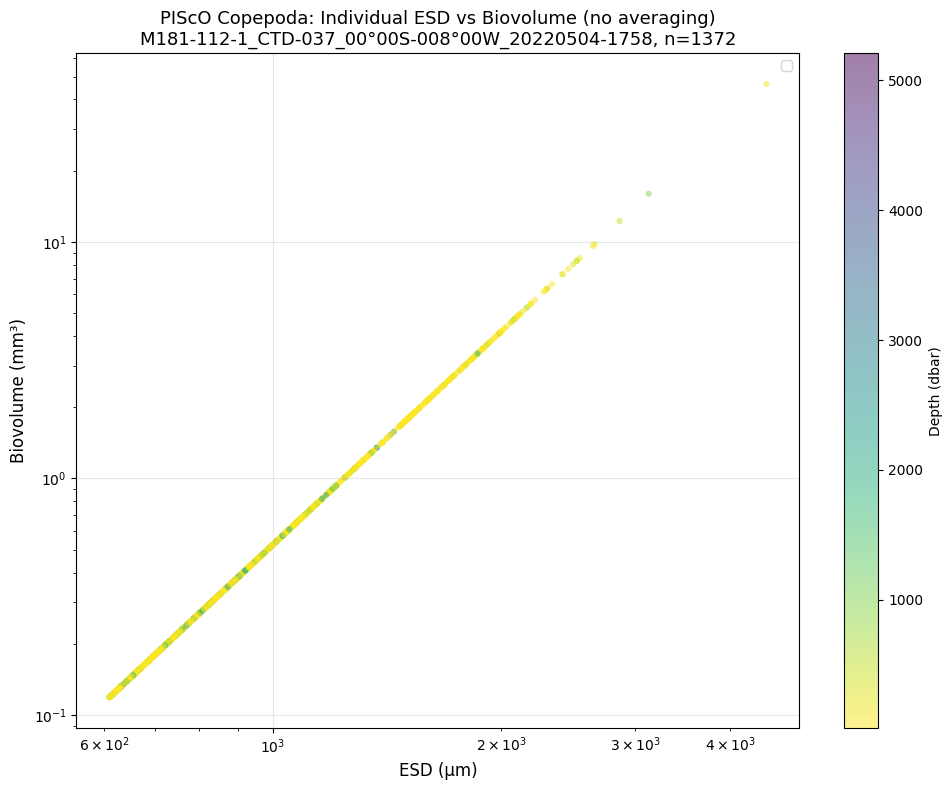


Figure 1 (individual points) saved to: /home/veit/PIScO_dev/Segmentation_results/pisco_copepod_esd_biovolume_individual.png


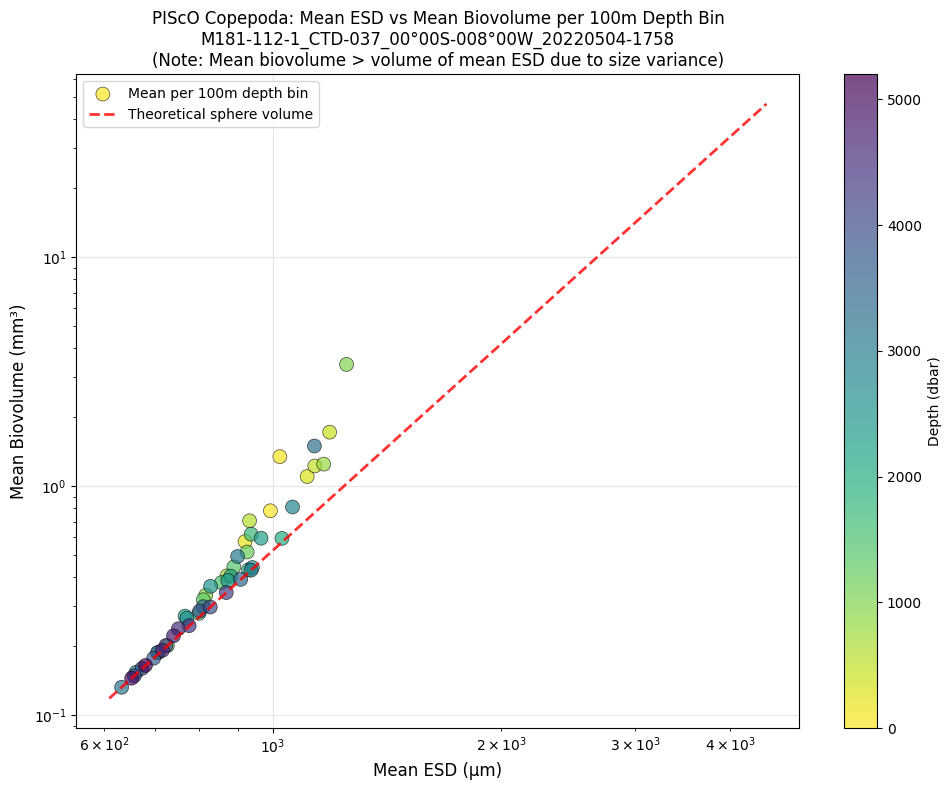

Figure 2 (depth bin averages) saved to: /home/veit/PIScO_dev/Segmentation_results/pisco_copepod_esd_biovolume_by_depth.png

INDIVIDUAL COPEPODS:
Total copepods analyzed: 1372
ESD range: 609.7 - 4464.4 µm
Biovolume range: 0.118678 - 46.590112 mm³

DEPTH BIN AVERAGES (100m):
 depth_bin_100m      esd_um  biovolume_mm3
            0.0  993.302366       0.781628
          100.0 1022.146292       1.346569
          200.0  919.900930       0.573756
          300.0 1110.287551       1.102845
          400.0 1188.684444       1.722272
          500.0 1136.203889       1.226180
          600.0  932.592308       0.706922
          700.0  870.906250       0.406881
          800.0 1167.270000       1.249258
          900.0  816.688000       0.334477
         1000.0 1250.964000       3.400981
         1100.0  726.955000       0.201577
         1200.0  925.647500       0.516472
         1300.0  810.535000       0.319838
         1400.0  889.123333       0.444586
         1500.0  856.243333       0.37

In [29]:
# Cell 9: PIScO single profile - ESD vs Biovolume plots
import matplotlib.pyplot as plt

# Filter for Copepoda and create 100m depth bins
copepod_data = result_df[result_df['object_annotation_category'].str.contains('Copepod', case=False, na=False)].copy()

# Read the original TSV to get individual ESD values
df_full = pd.read_csv(tsv_path, sep='\t', skiprows=[1])
df_full['pressure_dbar'] = df_full['object_pressure']

# Filter for Copepoda
copepod_individuals = df_full[df_full['object_annotation_category'].str.contains('Copepod', case=False, na=False)].copy()

# Create 100m depth bins (100 dbar ≈ 100m)
copepod_individuals['depth_bin_100m'] = (copepod_individuals['pressure_dbar'] // 100) * 100

# Calculate biovolume for each individual
if 'object_esd' in copepod_individuals.columns:
    # ESD is in µm (PIScO), convert to mm
    esd_mm = copepod_individuals['object_esd'] / 1000  # µm to mm
    copepod_individuals['biovolume_mm3'] = (np.pi / 6) * (esd_mm ** 3)
    
    # ESD already in µm for PIScO
    copepod_individuals['esd_um'] = copepod_individuals['object_esd']
    
    # Create TWO plots: one with individual points, one with depth bin averages
    
    # ============ PLOT 1: Individual copepods (no averaging) ============
    fig1, ax1 = plt.subplots(figsize=(10, 8))
    
    # Plot each individual copepod, color-coded by depth
    scatter1 = ax1.scatter(copepod_individuals['esd_um'], 
                          copepod_individuals['biovolume_mm3'],
                          c=copepod_individuals['pressure_dbar'],
                          cmap='viridis_r',
                          s=20,
                          alpha=0.5,
                          edgecolors='none')
    
    # Add colorbar
    cbar1 = plt.colorbar(scatter1, ax=ax1, label='Depth (dbar)')
    
    # Add theoretical line
    # esd_range_um = np.linspace(copepod_individuals['esd_um'].min(), 
    #                            copepod_individuals['esd_um'].max(), 100)
    # theoretical_biovol = (np.pi / 6) * ((esd_range_um / 1000) ** 3)
    # ax1.plot(esd_range_um, theoretical_biovol, 'r--', alpha=0.8, 
    #         label='Theoretical sphere volume', linewidth=2)
    
    ax1.set_xlabel('ESD (µm)', fontsize=12)
    ax1.set_ylabel('Biovolume (mm³)', fontsize=12)
    ax1.set_title(f'PIScO Copepoda: Individual ESD vs Biovolume (no averaging)\n{profile_name}, n={len(copepod_individuals)}', 
                fontsize=13)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    
    plt.tight_layout()
    plt.show()
    
    # Save figure 1
    fig1_path = "/home/veit/PIScO_dev/Segmentation_results/pisco_copepod_esd_biovolume_individual.png"
    fig1.savefig(fig1_path, dpi=300, bbox_inches='tight')
    print(f"\nFigure 1 (individual points) saved to: {fig1_path}")
    
    
    # ============ PLOT 2: Depth bin averages (100m bins) ============
    # Calculate average per 100m depth bin
    depth_averages = copepod_individuals.groupby('depth_bin_100m').agg({
        'esd_um': 'mean',
        'biovolume_mm3': 'mean'
    }).reset_index()
    
    fig2, ax2 = plt.subplots(figsize=(10, 8))
    
    # Plot depth bin averages
    scatter2 = ax2.scatter(depth_averages['esd_um'], 
                          depth_averages['biovolume_mm3'],
                          c=depth_averages['depth_bin_100m'],
                          cmap='viridis_r',
                          s=100,
                          alpha=0.7,
                          edgecolors='black',
                          linewidth=0.5,
                          label='Mean per 100m depth bin')
    
    # Add colorbar
    cbar2 = plt.colorbar(scatter2, ax=ax2, label='Depth (dbar)')
    
    # Add theoretical line
    ax2.plot(esd_range_um, theoretical_biovol, 'r--', alpha=0.8, 
            label='Theoretical sphere volume', linewidth=2)
    
    ax2.set_xlabel('Mean ESD (µm)', fontsize=12)
    ax2.set_ylabel('Mean Biovolume (mm³)', fontsize=12)
    ax2.set_title(f'PIScO Copepoda: Mean ESD vs Mean Biovolume per 100m Depth Bin\n{profile_name}\n(Note: Mean biovolume > volume of mean ESD due to size variance)', 
                fontsize=12)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    
    plt.tight_layout()
    plt.show()
    
    # Save figure 2
    fig2_path = "/home/veit/PIScO_dev/Segmentation_results/pisco_copepod_esd_biovolume_by_depth.png"
    fig2.savefig(fig2_path, dpi=300, bbox_inches='tight')
    print(f"Figure 2 (depth bin averages) saved to: {fig2_path}")
    
    # Print summary statistics
    print("\n" + "="*60)
    print("INDIVIDUAL COPEPODS:")
    print(f"Total copepods analyzed: {len(copepod_individuals)}")
    print(f"ESD range: {copepod_individuals['esd_um'].min():.1f} - {copepod_individuals['esd_um'].max():.1f} µm")
    print(f"Biovolume range: {copepod_individuals['biovolume_mm3'].min():.6f} - {copepod_individuals['biovolume_mm3'].max():.6f} mm³")
    
    print("\n" + "="*60)
    print("DEPTH BIN AVERAGES (100m):")
    print(depth_averages.to_string(index=False))
    
else:
    print("Error: object_esd column not found")

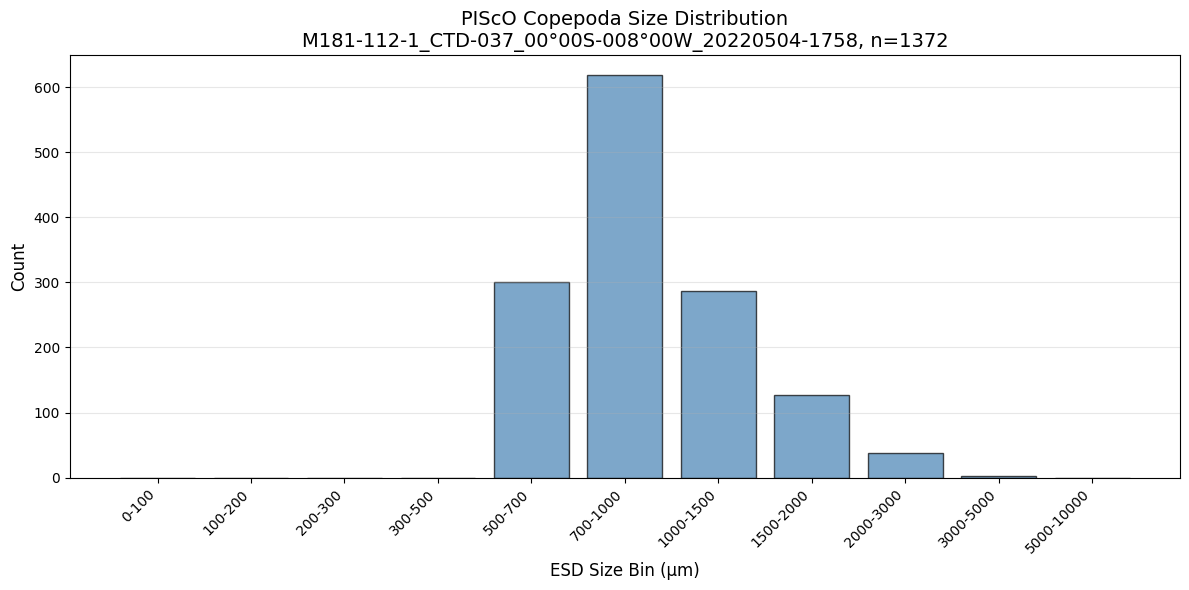


Figure 1 (size distribution) saved to: /home/veit/PIScO_dev/Segmentation_results/pisco_copepod_size_distribution.png


/tmp/ipykernel_247054/3688915015.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_depth_counts = copepod_individuals.groupby(['depth_bin_100m', 'size_bin']).size().unstack(fill_value=0)


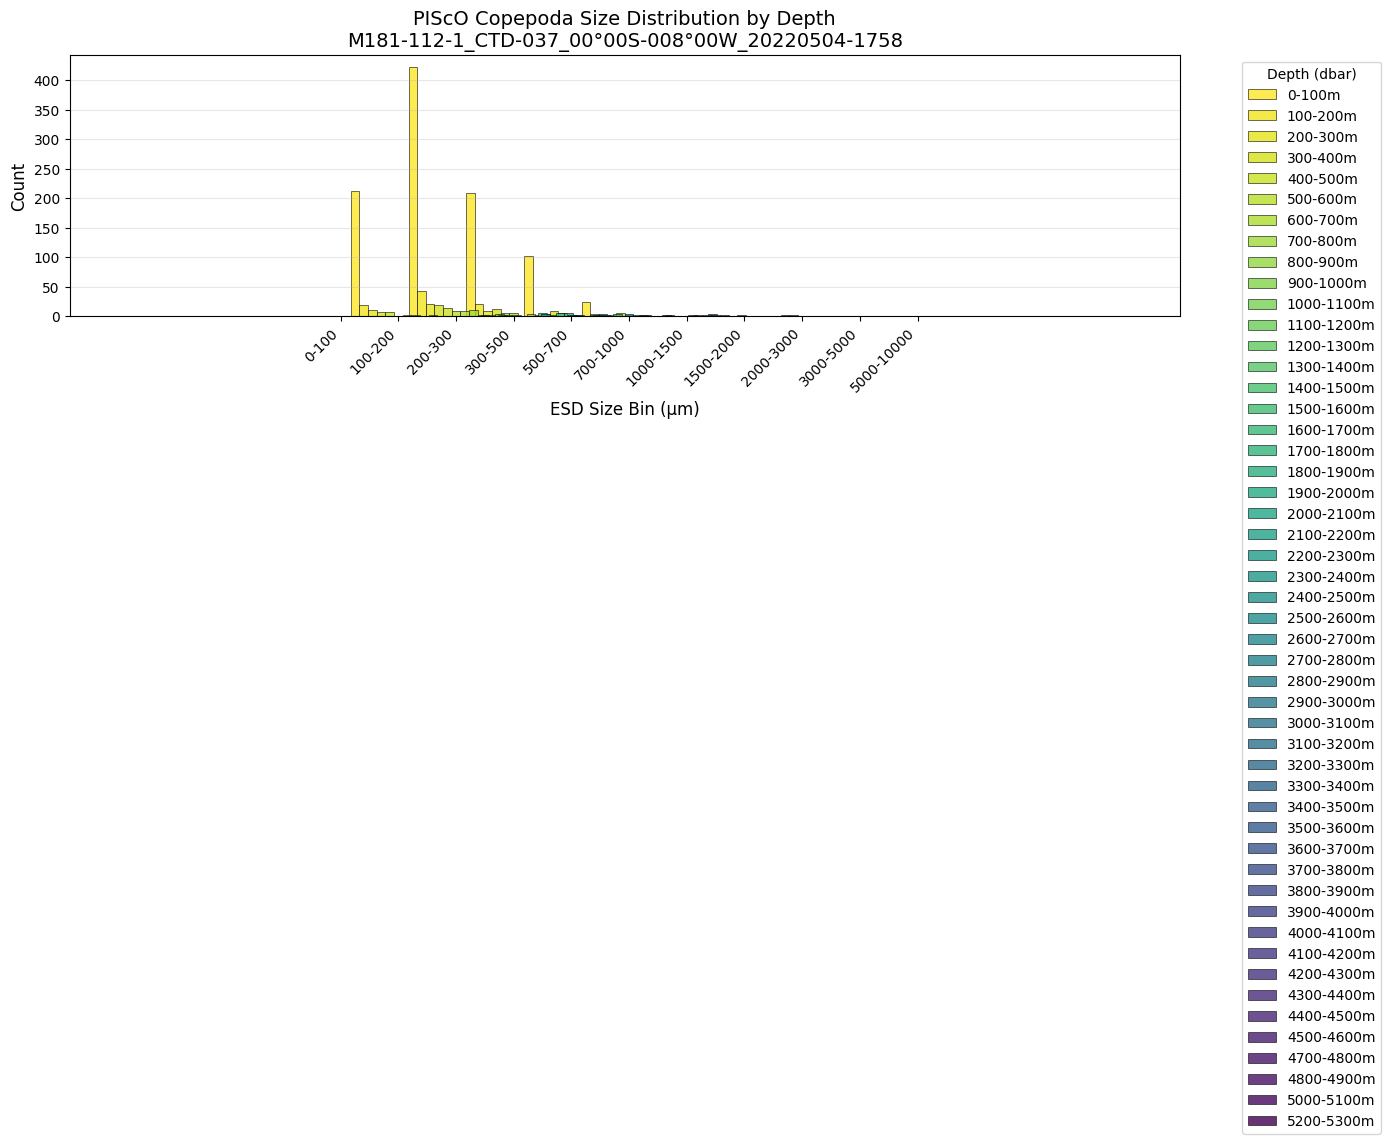

Figure 2 (size by depth) saved to: /home/veit/PIScO_dev/Segmentation_results/pisco_copepod_size_by_depth.png


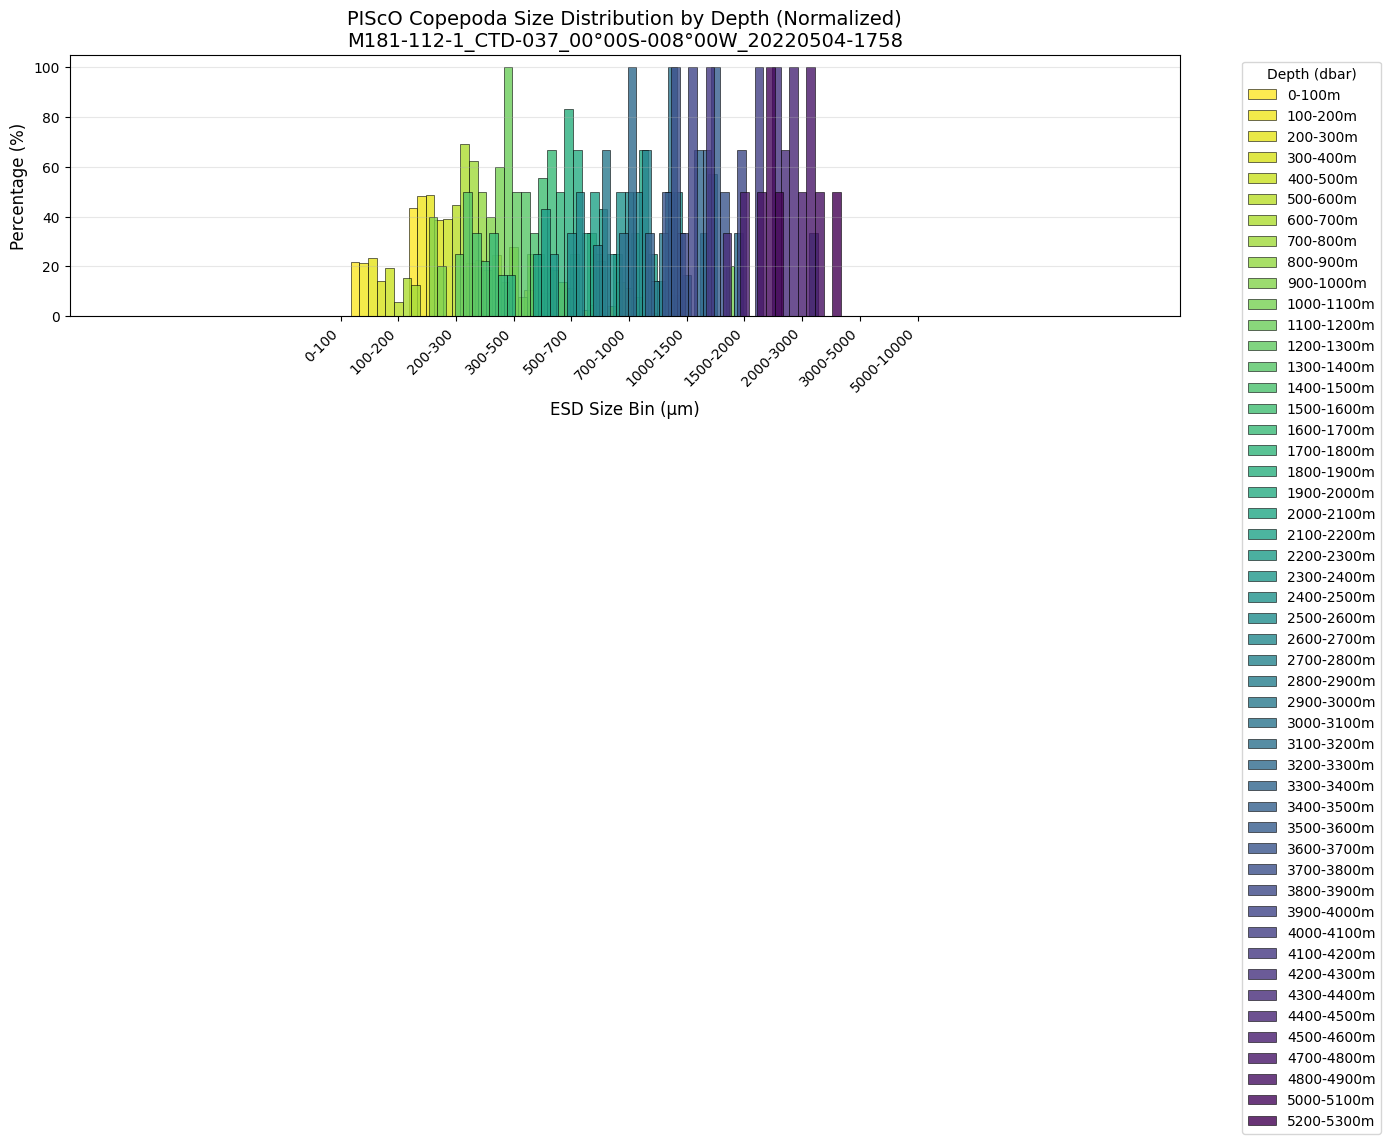

Figure 3 (normalized size by depth) saved to: /home/veit/PIScO_dev/Segmentation_results/pisco_copepod_size_by_depth_normalized.png

SIZE DISTRIBUTION SUMMARY:

Counts per size bin (all depths):
size_bin
0-100           0
100-200         0
200-300         0
300-500         0
500-700       300
700-1000      618
1000-1500     287
1500-2000     127
2000-3000      38
3000-5000       2
5000-10000      0

COUNTS PER SIZE BIN AND DEPTH:
size_bin        0-100  100-200  200-300  300-500  500-700  700-1000  1000-1500  1500-2000  2000-3000  3000-5000  5000-10000
depth_bin_100m                                                                                                             
0.0                 0        0        0        0      212       422        208        102         24          0           0
100.0               0        0        0        0       19        43         20          2          4          1           0
200.0               0        0        0        0       10        21    

In [26]:
# Cell 10: PIScO single profile - Size distribution plots
# (Assuming copepod_individuals is already loaded from Cell 9)

if 'object_esd' in copepod_individuals.columns:
    # ESD already in µm for PIScO
    copepod_individuals['esd_um'] = copepod_individuals['object_esd']
    
    # Create 100m depth bins (if not already done)
    if 'depth_bin_100m' not in copepod_individuals.columns:
        copepod_individuals['depth_bin_100m'] = (copepod_individuals['pressure_dbar'] // 100) * 100
    
    # ============ NEW: Create ESD size bins ============
    # Define size bins (in µm) - logarithmic bins work well for plankton
    size_bins = [0, 100, 200, 300, 500, 700, 1000, 1500, 2000, 3000, 5000, 10000]
    size_bin_labels = [f'{size_bins[i]}-{size_bins[i+1]}' for i in range(len(size_bins)-1)]
    
    # Assign each copepod to a size bin
    copepod_individuals['size_bin'] = pd.cut(copepod_individuals['esd_um'], 
                                              bins=size_bins, 
                                              labels=size_bin_labels,
                                              include_lowest=True)
    
    # ============ PLOT 1: Size distribution (all depths combined) ============
    fig1, ax1 = plt.subplots(figsize=(12, 6))
    
    # Count copepods per size bin
    size_counts = copepod_individuals['size_bin'].value_counts().sort_index()
    
    # Create bar plot
    ax1.bar(range(len(size_counts)), size_counts.values, 
            color='steelblue', alpha=0.7, edgecolor='black')
    ax1.set_xticks(range(len(size_counts)))
    ax1.set_xticklabels(size_counts.index, rotation=45, ha='right')
    ax1.set_xlabel('ESD Size Bin (µm)', fontsize=12)
    ax1.set_ylabel('Count', fontsize=12)
    ax1.set_title(f'PIScO Copepoda Size Distribution\n{profile_name}, n={len(copepod_individuals)}', 
                  fontsize=14)
    ax1.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Save figure 1
    fig1_path = "/home/veit/PIScO_dev/Segmentation_results/pisco_copepod_size_distribution.png"
    fig1.savefig(fig1_path, dpi=300, bbox_inches='tight')
    print(f"\nFigure 1 (size distribution) saved to: {fig1_path}")
    
    
    # ============ PLOT 2: Size distribution by depth bin ============
    fig2, ax2 = plt.subplots(figsize=(14, 8))
    
    # Count copepods per size bin AND depth bin
    size_depth_counts = copepod_individuals.groupby(['depth_bin_100m', 'size_bin']).size().unstack(fill_value=0)
    
    # Create grouped bar plot
    x_pos = np.arange(len(size_bin_labels))
    width = 0.15  # Width of bars
    
    depths = sorted(copepod_individuals['depth_bin_100m'].unique())
    colors = plt.cm.viridis_r(np.linspace(0, 1, len(depths)))
    
    for i, depth in enumerate(depths):
        if depth in size_depth_counts.index:
            offset = (i - len(depths)/2) * width
            counts = size_depth_counts.loc[depth, :]
            ax2.bar(x_pos + offset, counts, width, 
                   label=f'{int(depth)}-{int(depth+100)}m',
                   color=colors[i], alpha=0.8, edgecolor='black', linewidth=0.5)
    
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(size_bin_labels, rotation=45, ha='right')
    ax2.set_xlabel('ESD Size Bin (µm)', fontsize=12)
    ax2.set_ylabel('Count', fontsize=12)
    ax2.set_title(f'PIScO Copepoda Size Distribution by Depth\n{profile_name}', 
                  fontsize=14)
    ax2.legend(title='Depth (dbar)', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Save figure 2
    fig2_path = "/home/veit/PIScO_dev/Segmentation_results/pisco_copepod_size_by_depth.png"
    fig2.savefig(fig2_path, dpi=300, bbox_inches='tight')
    print(f"Figure 2 (size by depth) saved to: {fig2_path}")
    
    
    # ============ PLOT 3: Normalized size distribution by depth (% of each depth) ============
    fig3, ax3 = plt.subplots(figsize=(14, 8))
    
    # Calculate percentage within each depth bin
    size_depth_percent = size_depth_counts.div(size_depth_counts.sum(axis=1), axis=0) * 100
    
    for i, depth in enumerate(depths):
        if depth in size_depth_percent.index:
            offset = (i - len(depths)/2) * width
            percents = size_depth_percent.loc[depth, :]
            ax3.bar(x_pos + offset, percents, width,
                   label=f'{int(depth)}-{int(depth+100)}m',
                   color=colors[i], alpha=0.8, edgecolor='black', linewidth=0.5)
    
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(size_bin_labels, rotation=45, ha='right')
    ax3.set_xlabel('ESD Size Bin (µm)', fontsize=12)
    ax3.set_ylabel('Percentage (%)', fontsize=12)
    ax3.set_title(f'PIScO Copepoda Size Distribution by Depth (Normalized)\n{profile_name}', 
                  fontsize=14)
    ax3.legend(title='Depth (dbar)', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax3.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Save figure 3
    fig3_path = "/home/veit/PIScO_dev/Segmentation_results/pisco_copepod_size_by_depth_normalized.png"
    fig3.savefig(fig3_path, dpi=300, bbox_inches='tight')
    print(f"Figure 3 (normalized size by depth) saved to: {fig3_path}")
    
    
    # Print summary statistics
    print("\n" + "="*60)
    print("SIZE DISTRIBUTION SUMMARY:")
    print("\nCounts per size bin (all depths):")
    print(size_counts.to_string())
    
    print("\n" + "="*60)
    print("COUNTS PER SIZE BIN AND DEPTH:")
    print(size_depth_counts.to_string())
    
    print("\n" + "="*60)
    print("PERCENTAGE PER SIZE BIN AND DEPTH:")
    print(size_depth_percent.round(1).to_string())
    
    print(f"\nTotal copepods analyzed: {len(copepod_individuals)}")
    
else:
    print("Error: object_esd column not found")

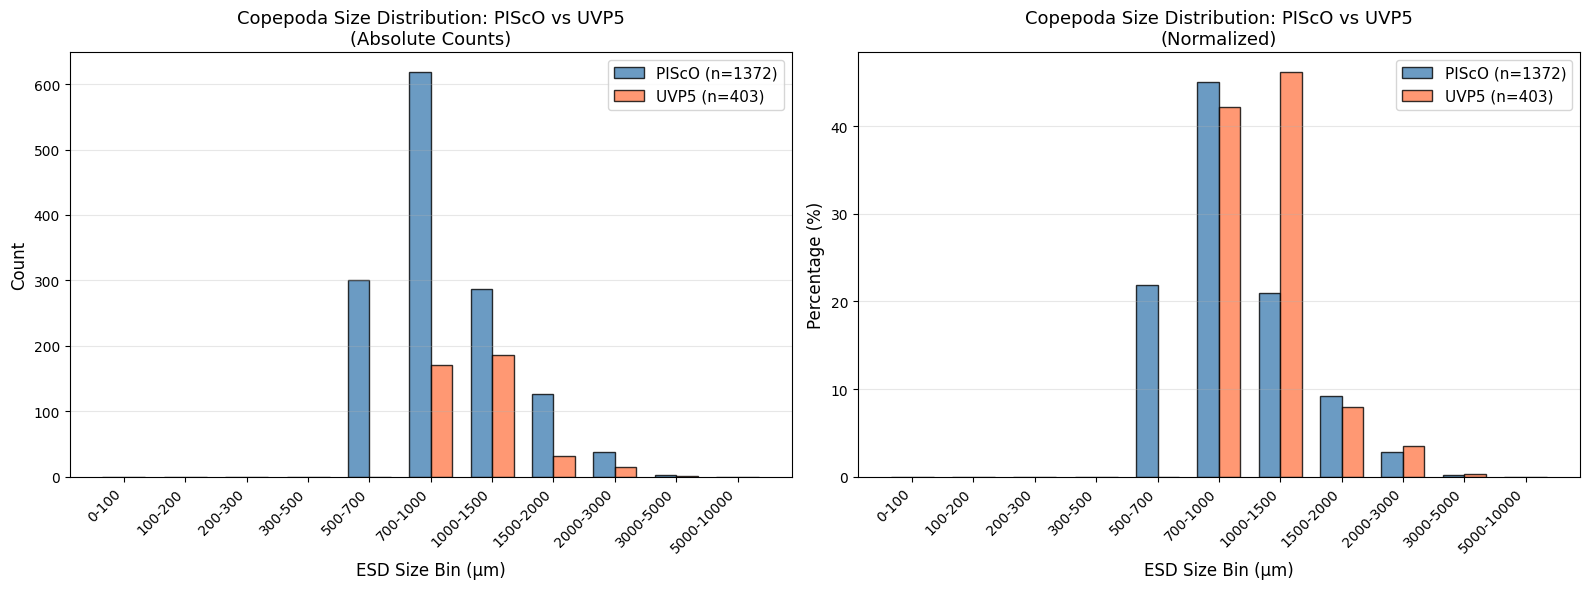


Comparison figure saved to: /home/veit/PIScO_dev/Segmentation_results/pisco_vs_uvp5_size_comparison.png

SIZE DISTRIBUTION COMPARISON:

PIScO:
  Profile: M181-112-1_CTD-037_00°00S-008°00W_20220504-1758
  Total copepods: 1372
  ESD range: 609.7 - 4464.4 µm
  Mean ESD: 989.6 µm
  Median ESD: 854.5 µm

UVP5:
  Sample: c_m181_037
  Total copepods: 403
  ESD range: 899.2 - 4211.7 µm
  Mean ESD: 1159.8 µm
  Median ESD: 1027.1 µm

COUNTS PER SIZE BIN:
  Size Bin  PIScO Count  PIScO %  UVP5 Count  UVP5 %
     0-100            0      0.0           0     0.0
   100-200            0      0.0           0     0.0
   200-300            0      0.0           0     0.0
   300-500            0      0.0           0     0.0
   500-700          300     21.9           0     0.0
  700-1000          618     45.0         170    42.2
 1000-1500          287     20.9         186    46.2
 1500-2000          127      9.3          32     7.9
 2000-3000           38      2.8          14     3.5
 3000-5000          

In [30]:
# Combined size distribution plot: PIScO vs UVP5

# ============ PREPARE PIScO DATA ============
# Read PIScO data
df_pisco = pd.read_csv(tsv_path, sep='\t', skiprows=[1])
df_pisco['pressure_dbar'] = df_pisco['object_pressure']

# Filter for Copepoda
copepod_pisco = df_pisco[df_pisco['object_annotation_category'].str.contains('Copepod', case=False, na=False)].copy()

# ESD already in µm for PIScO
copepod_pisco['esd_um'] = copepod_pisco['object_esd']


# ============ PREPARE UVP5 DATA ============
# Read UVP5 data
df_uvp5 = pd.read_csv(tsv_path_multi, sep='\t', skiprows=[1])
df_uvp5 = df_uvp5[df_uvp5['sample_id'] == sample_id].copy()

# Combine Calanoida and Copepoda<Maxillopoda
df_uvp5.loc[df_uvp5['object_annotation_category'] == 'Calanoida', 'object_annotation_category'] = 'Copepoda<Maxillopoda'

# Filter for Copepoda
copepod_uvp5 = df_uvp5[df_uvp5['object_annotation_category'].str.contains('Copepod', case=False, na=False)].copy()

# Convert ESD from pixels to µm: pixels * 88 µm/pixel
copepod_uvp5['esd_um'] = copepod_uvp5['object_esd'] * 88


# ============ CREATE SIZE BINS FOR BOTH ============
size_bins = [0, 100, 200, 300, 500, 700, 1000, 1500, 2000, 3000, 5000, 10000]
size_bin_labels = [f'{size_bins[i]}-{size_bins[i+1]}' for i in range(len(size_bins)-1)]

# Assign to size bins
copepod_pisco['size_bin'] = pd.cut(copepod_pisco['esd_um'], 
                                     bins=size_bins, 
                                     labels=size_bin_labels,
                                     include_lowest=True)

copepod_uvp5['size_bin'] = pd.cut(copepod_uvp5['esd_um'], 
                                    bins=size_bins, 
                                    labels=size_bin_labels,
                                    include_lowest=True)

# Count per size bin
pisco_counts = copepod_pisco['size_bin'].value_counts().sort_index()
uvp5_counts = copepod_uvp5['size_bin'].value_counts().sort_index()

# Ensure all bins are represented (fill missing with 0)
pisco_counts = pisco_counts.reindex(size_bin_labels, fill_value=0)
uvp5_counts = uvp5_counts.reindex(size_bin_labels, fill_value=0)


# ============ PLOT COMPARISON ============
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Absolute counts
x_pos = np.arange(len(size_bin_labels))
width = 0.35

bars1 = ax1.bar(x_pos - width/2, pisco_counts.values, width, 
                label=f'PIScO (n={len(copepod_pisco)})',
                color='steelblue', alpha=0.8, edgecolor='black')
bars2 = ax1.bar(x_pos + width/2, uvp5_counts.values, width,
                label=f'UVP5 (n={len(copepod_uvp5)})',
                color='coral', alpha=0.8, edgecolor='black')

ax1.set_xticks(x_pos)
ax1.set_xticklabels(size_bin_labels, rotation=45, ha='right')
ax1.set_xlabel('ESD Size Bin (µm)', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Copepoda Size Distribution: PIScO vs UVP5\n(Absolute Counts)', fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3, axis='y')


# Plot 2: Normalized percentages
pisco_percent = (pisco_counts / pisco_counts.sum()) * 100
uvp5_percent = (uvp5_counts / uvp5_counts.sum()) * 100

bars3 = ax2.bar(x_pos - width/2, pisco_percent.values, width,
                label=f'PIScO (n={len(copepod_pisco)})',
                color='steelblue', alpha=0.8, edgecolor='black')
bars4 = ax2.bar(x_pos + width/2, uvp5_percent.values, width,
                label=f'UVP5 (n={len(copepod_uvp5)})',
                color='coral', alpha=0.8, edgecolor='black')

ax2.set_xticks(x_pos)
ax2.set_xticklabels(size_bin_labels, rotation=45, ha='right')
ax2.set_xlabel('ESD Size Bin (µm)', fontsize=12)
ax2.set_ylabel('Percentage (%)', fontsize=12)
ax2.set_title('Copepoda Size Distribution: PIScO vs UVP5\n(Normalized)', fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Save figure
fig_path = "/home/veit/PIScO_dev/Segmentation_results/pisco_vs_uvp5_size_comparison.png"
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\nComparison figure saved to: {fig_path}")


# ============ PRINT COMPARISON STATISTICS ============
print("\n" + "="*70)
print("SIZE DISTRIBUTION COMPARISON:")
print("\nPIScO:")
print(f"  Profile: {profile_name}")
print(f"  Total copepods: {len(copepod_pisco)}")
print(f"  ESD range: {copepod_pisco['esd_um'].min():.1f} - {copepod_pisco['esd_um'].max():.1f} µm")
print(f"  Mean ESD: {copepod_pisco['esd_um'].mean():.1f} µm")
print(f"  Median ESD: {copepod_pisco['esd_um'].median():.1f} µm")

print("\nUVP5:")
print(f"  Sample: {sample_id}")
print(f"  Total copepods: {len(copepod_uvp5)}")
print(f"  ESD range: {copepod_uvp5['esd_um'].min():.1f} - {copepod_uvp5['esd_um'].max():.1f} µm")
print(f"  Mean ESD: {copepod_uvp5['esd_um'].mean():.1f} µm")
print(f"  Median ESD: {copepod_uvp5['esd_um'].median():.1f} µm")

print("\n" + "="*70)
print("COUNTS PER SIZE BIN:")
comparison_df = pd.DataFrame({
    'Size Bin': size_bin_labels,
    'PIScO Count': pisco_counts.values,
    'PIScO %': pisco_percent.values.round(1),
    'UVP5 Count': uvp5_counts.values,
    'UVP5 %': uvp5_percent.values.round(1)
})
print(comparison_df.to_string(index=False))

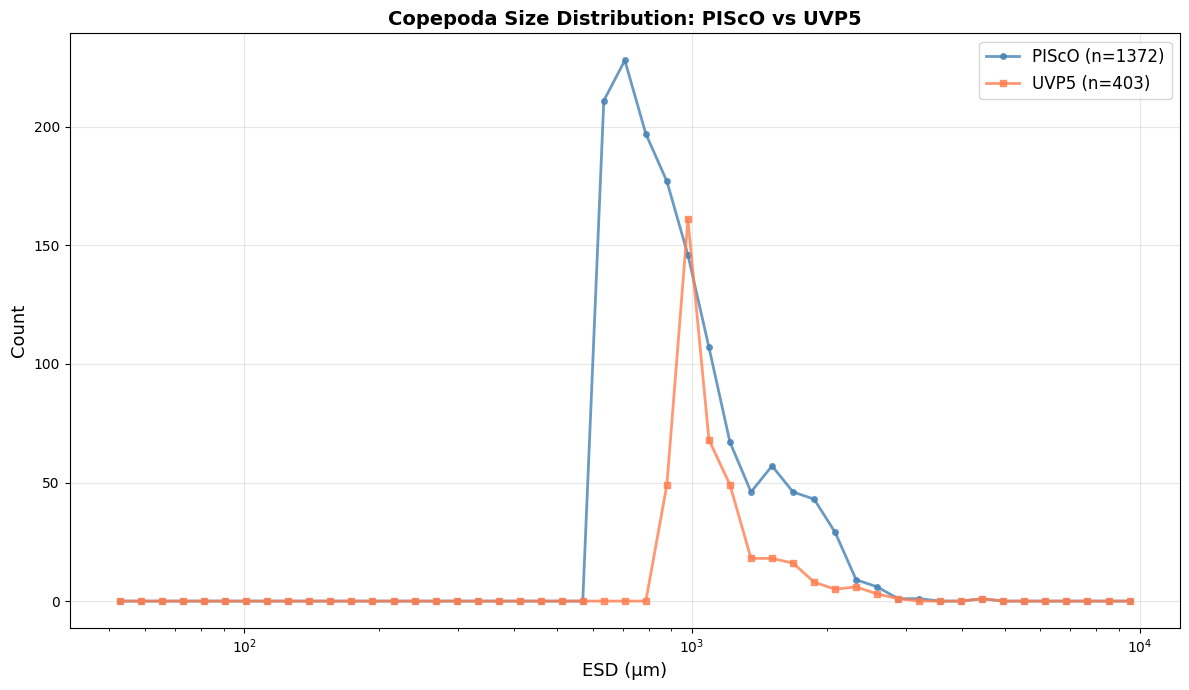


Comparison figure saved to: /home/veit/PIScO_dev/Segmentation_results/pisco_vs_uvp5_size_comparison.png

SIZE DISTRIBUTION COMPARISON:

PIScO:
  Profile: M181-112-1_CTD-037_00°00S-008°00W_20220504-1758
  Total copepods: 1372
  ESD range: 609.7 - 4464.4 µm
  Mean ESD: 989.6 µm
  Median ESD: 854.5 µm

UVP5:
  Sample: c_m181_037
  Total copepods: 403
  ESD range: 899.2 - 4211.7 µm
  Mean ESD: 1159.8 µm
  Median ESD: 1027.1 µm


In [32]:
# Combined size distribution plot: PIScO vs UVP5 (Line plot)

# ============ PREPARE PIScO DATA ============
# Read PIScO data
df_pisco = pd.read_csv(tsv_path, sep='\t', skiprows=[1])
df_pisco['pressure_dbar'] = df_pisco['object_pressure']

# Filter for Copepoda
copepod_pisco = df_pisco[df_pisco['object_annotation_category'].str.contains('Copepod', case=False, na=False)].copy()

# ESD already in µm for PIScO
copepod_pisco['esd_um'] = copepod_pisco['object_esd']


# ============ PREPARE UVP5 DATA ============
# Read UVP5 data
df_uvp5 = pd.read_csv(tsv_path_multi, sep='\t', skiprows=[1])
df_uvp5 = df_uvp5[df_uvp5['sample_id'] == sample_id].copy()

# Combine Calanoida and Copepoda<Maxillopoda
df_uvp5.loc[df_uvp5['object_annotation_category'] == 'Calanoida', 'object_annotation_category'] = 'Copepoda<Maxillopoda'

# Filter for Copepoda
copepod_uvp5 = df_uvp5[df_uvp5['object_annotation_category'].str.contains('Copepod', case=False, na=False)].copy()

# Convert ESD from pixels to µm: pixels * 88 µm/pixel
copepod_uvp5['esd_um'] = copepod_uvp5['object_esd'] * 88


# ============ CREATE HISTOGRAMS FOR BOTH ============
# Define common bin edges for comparison
bin_edges = np.logspace(np.log10(50), np.log10(10000), 50)  # 50 logarithmic bins from 50 to 10000 µm

# Calculate histograms
pisco_hist, _ = np.histogram(copepod_pisco['esd_um'], bins=bin_edges)
uvp5_hist, _ = np.histogram(copepod_uvp5['esd_um'], bins=bin_edges)

# Bin centers for plotting
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2


# ============ PLOT: LINE PLOT ============
fig, ax = plt.subplots(figsize=(12, 7))

# Plot lines
ax.plot(bin_centers, pisco_hist, 
        marker='o', linewidth=2, markersize=4, 
        label=f'PIScO (n={len(copepod_pisco)})',
        color='steelblue', alpha=0.8)

ax.plot(bin_centers, uvp5_hist, 
        marker='s', linewidth=2, markersize=4,
        label=f'UVP5 (n={len(copepod_uvp5)})',
        color='coral', alpha=0.8)

ax.set_xlabel('ESD (µm)', fontsize=13)
ax.set_ylabel('Count', fontsize=13)
ax.set_title('Copepoda Size Distribution: PIScO vs UVP5', fontsize=14, fontweight='bold')
ax.legend(fontsize=12, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xscale('log')

plt.tight_layout()
plt.show()

# Save figure
fig_path = "/home/veit/PIScO_dev/Segmentation_results/pisco_vs_uvp5_size_comparison.png"
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\nComparison figure saved to: {fig_path}")


# ============ PRINT COMPARISON STATISTICS ============
print("\n" + "="*70)
print("SIZE DISTRIBUTION COMPARISON:")
print("\nPIScO:")
print(f"  Profile: {profile_name}")
print(f"  Total copepods: {len(copepod_pisco)}")
print(f"  ESD range: {copepod_pisco['esd_um'].min():.1f} - {copepod_pisco['esd_um'].max():.1f} µm")
print(f"  Mean ESD: {copepod_pisco['esd_um'].mean():.1f} µm")
print(f"  Median ESD: {copepod_pisco['esd_um'].median():.1f} µm")

print("\nUVP5:")
print(f"  Sample: {sample_id}")
print(f"  Total copepods: {len(copepod_uvp5)}")
print(f"  ESD range: {copepod_uvp5['esd_um'].min():.1f} - {copepod_uvp5['esd_um'].max():.1f} µm")
print(f"  Mean ESD: {copepod_uvp5['esd_um'].mean():.1f} µm")
print(f"  Median ESD: {copepod_uvp5['esd_um'].median():.1f} µm")

In [6]:
# Combined biovolume distribution plot: PIScO vs UVP5 (Line plot)

# ============ PREPARE PIScO DATA ============
# Read PIScO data
df_pisco = pd.read_csv(tsv_path, sep='\t', skiprows=[1])
df_pisco['pressure_dbar'] = df_pisco['object_pressure']

# Filter for Copepoda
copepod_pisco = df_pisco[df_pisco['object_annotation_category'].str.contains('Copepod', case=False, na=False)].copy()

# ESD already in µm for PIScO
copepod_pisco['esd_um'] = copepod_pisco['object_esd']

# Calculate biovolume in mm³
esd_mm_pisco = copepod_pisco['esd_um'] / 1000  # µm to mm
copepod_pisco['biovolume_mm3'] = (np.pi / 6) * (esd_mm_pisco ** 3)
print(copepod_pisco)


# ============ PREPARE UVP5 DATA ============
# Read UVP5 data
df_uvp5 = pd.read_csv(tsv_path_multi, sep='\t', skiprows=[1])
df_uvp5 = df_uvp5[df_uvp5['sample_id'] == sample_id].copy()

# Combine Calanoida and Copepoda<Maxillopoda
df_uvp5.loc[df_uvp5['object_annotation_category'] == 'Calanoida', 'object_annotation_category'] = 'Copepoda<Maxillopoda'

# Filter for Copepoda
copepod_uvp5 = df_uvp5[df_uvp5['object_annotation_category'].str.contains('Copepod', case=False, na=False)].copy()

# Convert ESD from pixels to µm: pixels * 88 µm/pixel
copepod_uvp5['esd_um'] = copepod_uvp5['object_esd'] * 88

# Calculate biovolume in mm³
esd_mm_uvp5 = copepod_uvp5['esd_um'] / 1000  # µm to mm
copepod_uvp5['biovolume_mm3'] = (np.pi / 6) * (esd_mm_uvp5 ** 3)


# ============ CREATE HISTOGRAMS FOR BOTH (BIOVOLUME) ============
# Define common bin edges for biovolume comparison (logarithmic)
biovolume_bin_edges = np.logspace(np.log10(0.0001), np.log10(10), 50)  # 50 bins from 0.0001 to 10 mm³

# Calculate histograms
pisco_biovol_hist, _ = np.histogram(copepod_pisco['biovolume_mm3'], bins=biovolume_bin_edges)
uvp5_biovol_hist, _ = np.histogram(copepod_uvp5['biovolume_mm3'], bins=biovolume_bin_edges)

# Bin centers for plotting
biovolume_bin_centers = (biovolume_bin_edges[:-1] + biovolume_bin_edges[1:]) / 2


# ============ PLOT: LINE PLOT (BIOVOLUME) ============
fig, ax = plt.subplots(figsize=(12, 7))

# Plot lines
ax.plot(biovolume_bin_centers, pisco_biovol_hist, 
        marker='o', linewidth=2, markersize=4, 
        label=f'PIScO (n={len(copepod_pisco)})',
        color='steelblue', alpha=0.8)

ax.plot(biovolume_bin_centers, uvp5_biovol_hist, 
        marker='s', linewidth=2, markersize=4,
        label=f'UVP5 (n={len(copepod_uvp5)})',
        color='coral', alpha=0.8)

ax.set_xlabel('Biovolume (mm³)', fontsize=13)
ax.set_ylabel('Count', fontsize=13)
ax.set_title('Copepoda Biovolume Distribution: PIScO vs UVP5', fontsize=14, fontweight='bold')
ax.legend(fontsize=12, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xscale('log')

plt.tight_layout()
plt.show()

# Save figure
fig_path = "/home/veit/PIScO_dev/Segmentation_results/pisco_vs_uvp5_biovolume_comparison.png"
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\nComparison figure saved to: {fig_path}")


# ============ PRINT COMPARISON STATISTICS ============
print("\n" + "="*70)
print("BIOVOLUME DISTRIBUTION COMPARISON:")
print("\nPIScO:")
print(f"  Profile: {profile_name}")
print(f"  Total copepods: {len(copepod_pisco)}")
print(f"  Biovolume range: {copepod_pisco['biovolume_mm3'].min():.6f} - {copepod_pisco['biovolume_mm3'].max():.6f} mm³")
print(f"  Mean biovolume: {copepod_pisco['biovolume_mm3'].mean():.6f} mm³")
print(f"  Median biovolume: {copepod_pisco['biovolume_mm3'].median():.6f} mm³")
print(f"  Total biovolume: {copepod_pisco['biovolume_mm3'].sum():.2f} mm³")

print("\nUVP5:")
print(f"  Sample: {sample_id}")
print(f"  Total copepods: {len(copepod_uvp5)}")
print(f"  Biovolume range: {copepod_uvp5['biovolume_mm3'].min():.6f} - {copepod_uvp5['biovolume_mm3'].max():.6f} mm³")
print(f"  Mean biovolume: {copepod_uvp5['biovolume_mm3'].mean():.6f} mm³")
print(f"  Median biovolume: {copepod_uvp5['biovolume_mm3'].median():.6f} mm³")
print(f"  Total biovolume: {copepod_uvp5['biovolume_mm3'].sum():.2f} mm³")

      object_date-time  object_pressure  object_depth_min  object_temperature  \
1                  NaN            40.93            40.705                 NaN   
9                  NaN            41.28            41.050                 NaN   
10                 NaN          2158.09          2135.229                 NaN   
11                 NaN            41.58            41.347                 NaN   
13                 NaN            41.58            41.347                 NaN   
...                ...              ...               ...                 ...   
3539               NaN            39.90            39.675                 NaN   
3540               NaN            39.90            39.675                 NaN   
3541               NaN            40.27            40.047                 NaN   
3543               NaN            40.27            40.047                 NaN   
3548               NaN            16.81            16.715                 NaN   

      object_index  img_ran

NameError: name 'tsv_path_multi' is not defined

Total sampled volume across all depths: 46515.08 L


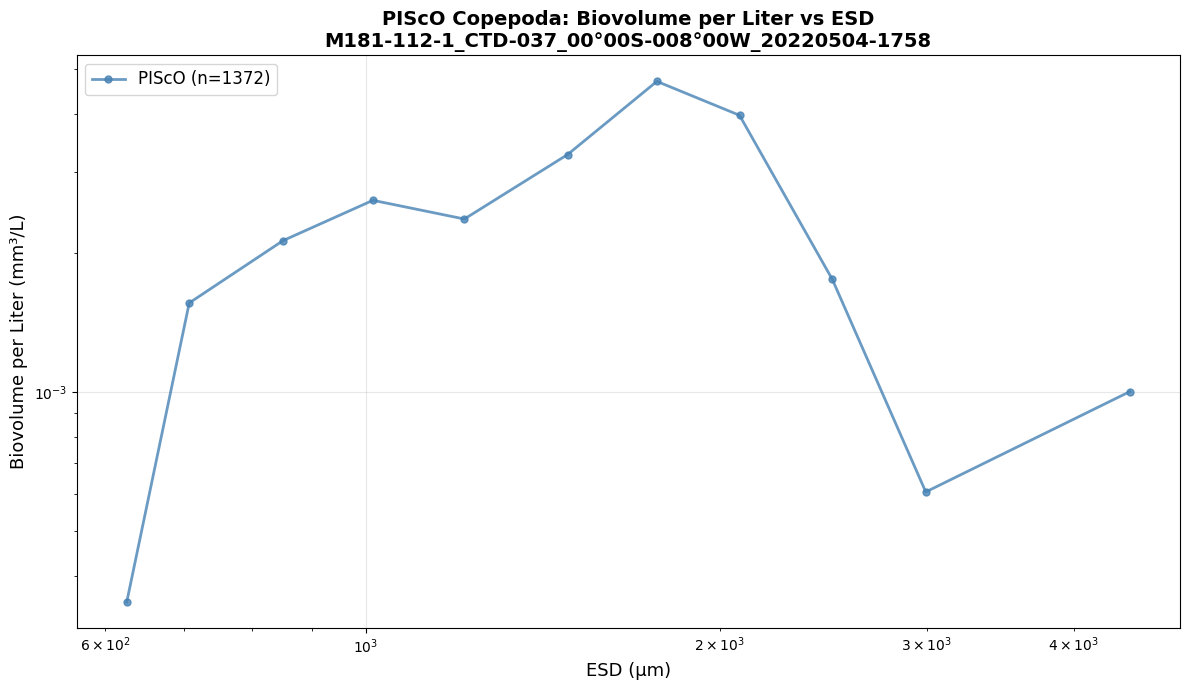


Figure saved to: /home/veit/PIScO_dev/Segmentation_results/pisco_biovolume_per_L_vs_esd.png

BIOVOLUME PER LITER vs ESD (PIScO):

Total copepods: 1372
ESD range: 609.7 - 4464.4 µm
Total biovolume: 1130.42 mm³
Total sampled volume: 46515.08 L
Overall biovolume per L: 0.0243 mm³/L

Biovolume per L by ESD bin:
     esd_um  biovolume_mm3_per_L
 625.844016             0.000351
 707.330696             0.001558
 850.126000             0.002126
1013.664591             0.002599
1212.521197             0.002368
1484.250795             0.003265
1767.831733             0.004703
2078.435128             0.003971
2492.903000             0.001752
2993.380000             0.000607
4464.420000             0.001002


In [9]:
import matplotlib.pyplot as plt

# PIScO: Biovolume per Liter vs ESD (CORRECTED)

# Read the full TSV to get individual ESD values
df_full = pd.read_csv(tsv_path, sep='\t', skiprows=[1])
df_full['pressure_dbar'] = df_full['object_pressure']

# Filter for Copepoda
copepod_pisco = df_full[df_full['object_annotation_category'].str.contains('Copepod', case=False, na=False)].copy()

# ESD already in µm for PIScO
copepod_pisco['esd_um'] = copepod_pisco['object_esd']

# Calculate biovolume in mm³ for each individual
esd_mm_pisco = copepod_pisco['esd_um'] / 1000  # µm to mm
copepod_pisco['biovolume_mm3'] = (np.pi / 6) * (esd_mm_pisco ** 3)


# ============ BIN DATA BY ESD AND CALCULATE BIOVOLUME PER LITER ============
# Create ESD bins (logarithmic)
esd_bin_edges = np.logspace(np.log10(50), np.log10(10000), 30)  # 30 bins

# Bin data
copepod_pisco['esd_bin'] = pd.cut(copepod_pisco['esd_um'], bins=esd_bin_edges)

# ✅ CORRECTED: Calculate TOTAL sampled volume across ALL depths
# Group by depth bins and sum volumes (drop duplicates from multiple categories)
total_sampled_volume_L = result_df.groupby(['depth_bin_start_dbar', 'depth_bin_end_dbar'])['sampled_volume_L'].first().sum()
print(f"Total sampled volume across all depths: {total_sampled_volume_L:.2f} L")

# Now group by ESD bin and calculate biovolume per liter
pisco_binned = copepod_pisco.groupby('esd_bin', observed=True).agg({
    'esd_um': 'mean',
    'biovolume_mm3': 'sum',  # Total biovolume in this ESD bin
}).dropna().reset_index(drop=True)

# Calculate biovolume per liter for each ESD bin (normalized by TOTAL volume)
pisco_binned['biovolume_mm3_per_L'] = pisco_binned['biovolume_mm3'] / total_sampled_volume_L


# ============ PLOT: ESD vs BIOVOLUME PER LITER ============
fig, ax = plt.subplots(figsize=(12, 7))

# Plot binned data as line
ax.plot(pisco_binned['esd_um'], pisco_binned['biovolume_mm3_per_L'],
        marker='o', linewidth=2, markersize=5,
        label=f'PIScO (n={len(copepod_pisco)})',
        color='steelblue', alpha=0.8)

ax.set_xlabel('ESD (µm)', fontsize=13)
ax.set_ylabel('Biovolume per Liter (mm³/L)', fontsize=13)
ax.set_title(f'PIScO Copepoda: Biovolume per Liter vs ESD\n{profile_name}', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xscale('log')
ax.set_yscale('log')

plt.tight_layout()
plt.show()

# Save figure
fig_path = "/home/veit/PIScO_dev/Segmentation_results/pisco_biovolume_per_L_vs_esd.png"
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\nFigure saved to: {fig_path}")


# ============ PRINT STATISTICS ============
print("\n" + "="*70)
print("BIOVOLUME PER LITER vs ESD (PIScO):")
print(f"\nTotal copepods: {len(copepod_pisco)}")
print(f"ESD range: {copepod_pisco['esd_um'].min():.1f} - {copepod_pisco['esd_um'].max():.1f} µm")
print(f"Total biovolume: {pisco_binned['biovolume_mm3'].sum():.2f} mm³")
print(f"Total sampled volume: {total_sampled_volume_L:.2f} L")
print(f"Overall biovolume per L: {pisco_binned['biovolume_mm3'].sum() / total_sampled_volume_L:.4f} mm³/L")

print("\nBiovolume per L by ESD bin:")
print(pisco_binned[['esd_um', 'biovolume_mm3_per_L']].to_string(index=False))

Total UVP5 sampled volume across all depths: 124570.88 L


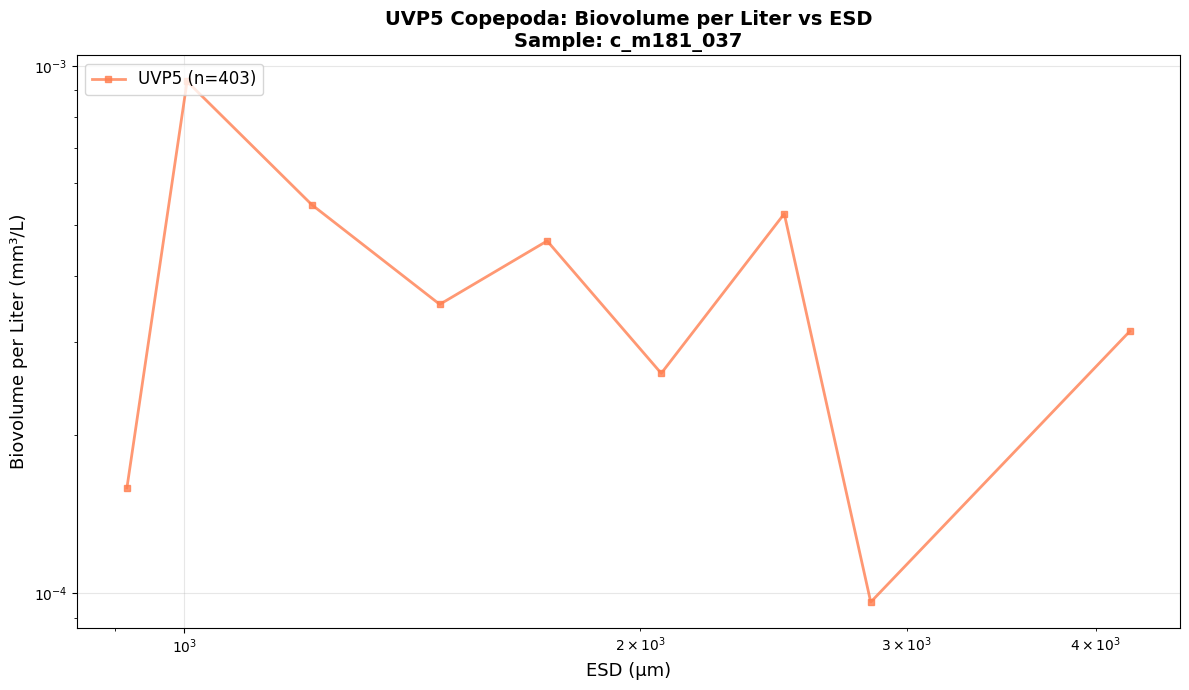


Figure saved to: /home/veit/PIScO_dev/Segmentation_results/c_m181_037_uvp5_biovolume_per_L_vs_esd.png

BIOVOLUME PER LITER vs ESD (UVP5):

Sample: c_m181_037
Total copepods: 403
ESD range: 899.2 - 4211.7 µm
Total biovolume: 455.02 mm³
Total sampled volume: 124570.88 L
Overall biovolume per L: 0.0037 mm³/L

Biovolume per L by ESD bin:
     esd_um  biovolume_mm3_per_L
 916.317435             0.000158
1004.082030             0.000934
1213.825146             0.000545
1474.560693             0.000353
1736.151602             0.000466
2065.147777             0.000261
2489.991995             0.000524
2839.974126             0.000096
4211.660088             0.000314


In [11]:
# UVP5: Biovolume per Liter vs ESD (CORRECTED)

tsv_path_multi = "/home/veit/PIScO_dev/Segmentation_results/ecotaxa_export__TSV_17905_20251113_1239.tsv"
sample_id = "c_m181_037"

# ============ READ UVP5 VOLUME DATA ============
uvp5_volume_path = "/home/veit/PIScO_dev/Segmentation_results/export_detailed_20251113_12_27_PAR_c_m181_037.tsv"
df_uvp5_volume = pd.read_csv(uvp5_volume_path, sep='\t', encoding='latin-1')

# Calculate TOTAL sampled volume across all depth bins
total_uvp5_volume_L = df_uvp5_volume['Sampled volume [L]'].sum()
print(f"Total UVP5 sampled volume across all depths: {total_uvp5_volume_L:.2f} L")


# ============ PREPARE UVP5 COPEPOD DATA ============
df_uvp5 = pd.read_csv(tsv_path_multi, sep='\t', skiprows=[1])
df_uvp5 = df_uvp5[df_uvp5['sample_id'] == sample_id].copy()

# Combine Calanoida and Copepoda<Maxillopoda
df_uvp5.loc[df_uvp5['object_annotation_category'] == 'Calanoida', 'object_annotation_category'] = 'Copepoda<Maxillopoda'

# Filter for Copepoda
copepod_uvp5 = df_uvp5[df_uvp5['object_annotation_category'].str.contains('Copepod', case=False, na=False)].copy()

# Convert ESD from pixels to µm: pixels * 88 µm/pixel
copepod_uvp5['esd_um'] = copepod_uvp5['object_esd'] * 88

# Calculate biovolume in mm³
esd_mm_uvp5 = copepod_uvp5['esd_um'] / 1000  # µm to mm
copepod_uvp5['biovolume_mm3'] = (np.pi / 6) * (esd_mm_uvp5 ** 3)


# ============ BIN DATA BY ESD AND CALCULATE BIOVOLUME PER LITER ============
# Create ESD bins (logarithmic) - same as PIScO for comparison
esd_bin_edges = np.logspace(np.log10(50), np.log10(10000), 30)  # 30 bins

# Bin data
copepod_uvp5['esd_bin'] = pd.cut(copepod_uvp5['esd_um'], bins=esd_bin_edges)

# Now group by ESD bin and calculate biovolume per liter
uvp5_binned = copepod_uvp5.groupby('esd_bin', observed=True).agg({
    'esd_um': 'mean',
    'biovolume_mm3': 'sum',  # Total biovolume in this ESD bin
}).dropna().reset_index(drop=True)

# Calculate biovolume per liter for each ESD bin (normalized by TOTAL volume)
uvp5_binned['biovolume_mm3_per_L'] = uvp5_binned['biovolume_mm3'] / total_uvp5_volume_L


# ============ PLOT: ESD vs BIOVOLUME PER LITER ============
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(uvp5_binned['esd_um'], uvp5_binned['biovolume_mm3_per_L'],
        marker='s', linewidth=2, markersize=5,
        label=f'UVP5 (n={len(copepod_uvp5)})',
        color='coral', alpha=0.8)

ax.set_xlabel('ESD (µm)', fontsize=13)
ax.set_ylabel('Biovolume per Liter (mm³/L)', fontsize=13)
ax.set_title(f'UVP5 Copepoda: Biovolume per Liter vs ESD\nSample: {sample_id}', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xscale('log')
ax.set_yscale('log')

plt.tight_layout()
plt.show()

# Save figure
fig_path = f"/home/veit/PIScO_dev/Segmentation_results/{sample_id}_uvp5_biovolume_per_L_vs_esd.png"
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\nFigure saved to: {fig_path}")


# ============ PRINT STATISTICS ============
print("\n" + "="*70)
print("BIOVOLUME PER LITER vs ESD (UVP5):")
print(f"\nSample: {sample_id}")
print(f"Total copepods: {len(copepod_uvp5)}")
print(f"ESD range: {copepod_uvp5['esd_um'].min():.1f} - {copepod_uvp5['esd_um'].max():.1f} µm")
print(f"Total biovolume: {uvp5_binned['biovolume_mm3'].sum():.2f} mm³")
print(f"Total sampled volume: {total_uvp5_volume_L:.2f} L")
print(f"Overall biovolume per L: {uvp5_binned['biovolume_mm3'].sum() / total_uvp5_volume_L:.4f} mm³/L")

print("\nBiovolume per L by ESD bin:")
print(uvp5_binned[['esd_um', 'biovolume_mm3_per_L']].to_string(index=False))

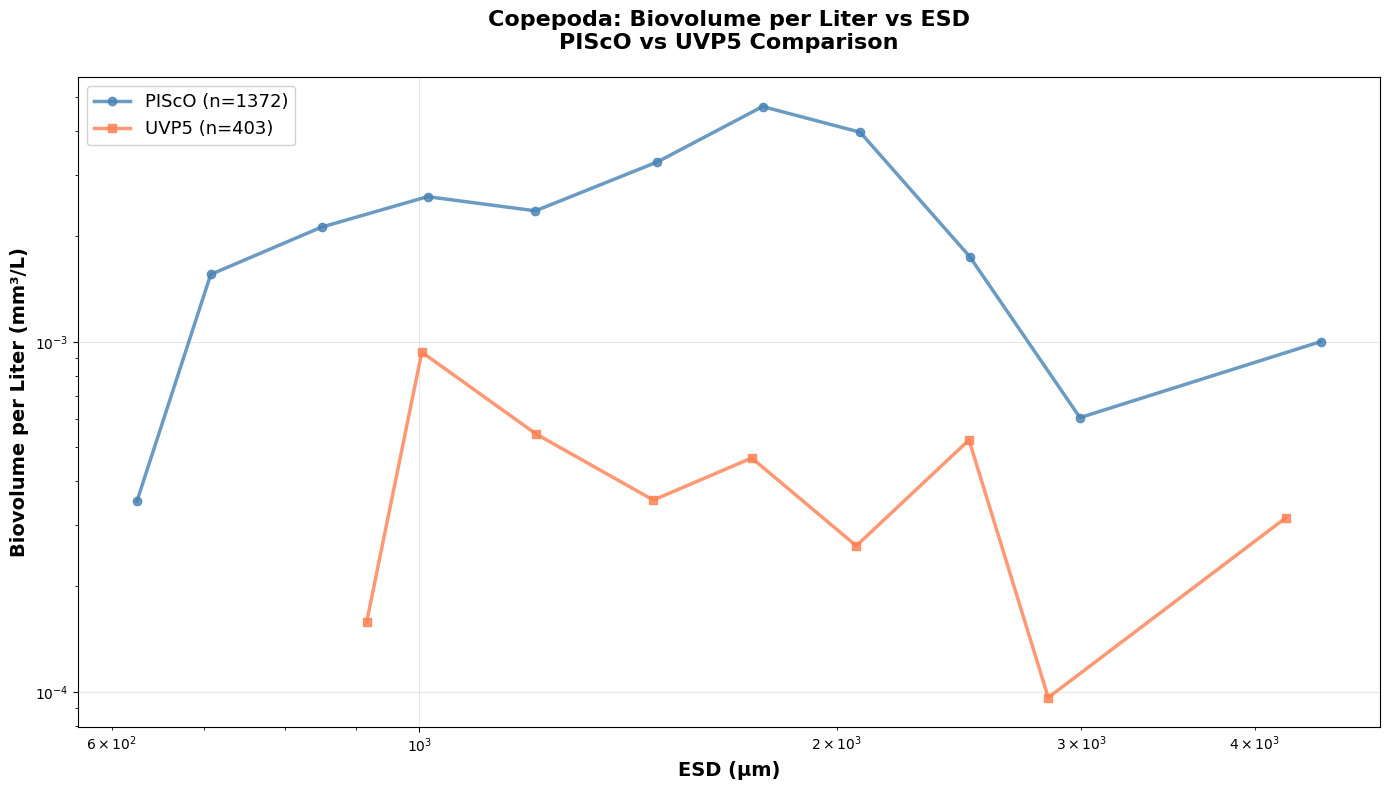


Comparison figure saved to: /home/veit/PIScO_dev/Segmentation_results/pisco_vs_uvp5_biovolume_per_L_comparison.png

BIOVOLUME PER LITER COMPARISON: PIScO vs UVP5

PIScO:
  Profile: M181-112-1_CTD-037_00°00S-008°00W_20220504-1758
  Total copepods: 1372
  Total biovolume: 1130.42 mm³
  Total sampled volume: 46515.08 L
  Overall biovolume per L: 0.0243 mm³/L
  ESD range: 609.7 - 4464.4 µm

UVP5:
  Sample: c_m181_037
  Total copepods: 403
  Total biovolume: 455.02 mm³
  Total sampled volume: 124570.88 L
  Overall biovolume per L: 0.0037 mm³/L
  ESD range: 899.2 - 4211.7 µm

RATIO (PIScO / UVP5):
  Biovolume per L ratio: 6.65x
  Total copepod ratio: 3.40x


In [12]:
# Combined Plot: PIScO vs UVP5 - Biovolume per Liter vs ESD (CORRECTED)

# ============ PISCO DATA (already calculated above) ============
# pisco_binned should already exist from previous cell

# ============ UVP5 DATA (already calculated above) ============  
# uvp5_binned should already exist from previous cell


# ============ COMBINED PLOT ============
fig, ax = plt.subplots(figsize=(14, 8))

# Plot PIScO
ax.plot(pisco_binned['esd_um'], pisco_binned['biovolume_mm3_per_L'],
        marker='o', linewidth=2.5, markersize=6,
        label=f'PIScO (n={len(copepod_pisco)})',
        color='steelblue', alpha=0.8)

# Plot UVP5
ax.plot(uvp5_binned['esd_um'], uvp5_binned['biovolume_mm3_per_L'],
        marker='s', linewidth=2.5, markersize=6,
        label=f'UVP5 (n={len(copepod_uvp5)})',
        color='coral', alpha=0.8)

ax.set_xlabel('ESD (µm)', fontsize=14, fontweight='bold')
ax.set_ylabel('Biovolume per Liter (mm³/L)', fontsize=14, fontweight='bold')
ax.set_title('Copepoda: Biovolume per Liter vs ESD\nPIScO vs UVP5 Comparison', 
             fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=13, loc='upper left', framealpha=0.9)
ax.grid(True, alpha=0.3, linewidth=0.8)
ax.set_xscale('log')
ax.set_yscale('log')

plt.tight_layout()
plt.show()

# Save figure
fig_path = "/home/veit/PIScO_dev/Segmentation_results/pisco_vs_uvp5_biovolume_per_L_comparison.png"
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\nComparison figure saved to: {fig_path}")


# ============ PRINT COMPARISON STATISTICS ============
print("\n" + "="*80)
print("BIOVOLUME PER LITER COMPARISON: PIScO vs UVP5")
print("="*80)

print("\nPIScO:")
print(f"  Profile: {profile_name}")
print(f"  Total copepods: {len(copepod_pisco)}")
print(f"  Total biovolume: {pisco_binned['biovolume_mm3'].sum():.2f} mm³")
print(f"  Total sampled volume: {total_sampled_volume_L:.2f} L")
print(f"  Overall biovolume per L: {pisco_binned['biovolume_mm3'].sum() / total_sampled_volume_L:.4f} mm³/L")
print(f"  ESD range: {copepod_pisco['esd_um'].min():.1f} - {copepod_pisco['esd_um'].max():.1f} µm")

print("\nUVP5:")
print(f"  Sample: {sample_id}")
print(f"  Total copepods: {len(copepod_uvp5)}")
print(f"  Total biovolume: {uvp5_binned['biovolume_mm3'].sum():.2f} mm³")
print(f"  Total sampled volume: {total_uvp5_volume_L:.2f} L")
print(f"  Overall biovolume per L: {uvp5_binned['biovolume_mm3'].sum() / total_uvp5_volume_L:.4f} mm³/L")
print(f"  ESD range: {copepod_uvp5['esd_um'].min():.1f} - {copepod_uvp5['esd_um'].max():.1f} µm")

print("\n" + "="*80)
print("RATIO (PIScO / UVP5):")
pisco_total_biovol_per_L = pisco_binned['biovolume_mm3'].sum() / total_sampled_volume_L
uvp5_total_biovol_per_L = uvp5_binned['biovolume_mm3'].sum() / total_uvp5_volume_L
print(f"  Biovolume per L ratio: {pisco_total_biovol_per_L / uvp5_total_biovol_per_L:.2f}x")
print(f"  Total copepod ratio: {len(copepod_pisco) / len(copepod_uvp5):.2f}x")

In [4]:
#PISCO data
tsv_path = "/home/veit/PIScO_dev/Segmentation_results/ecotaxa_M181-175-1_CTD-050_00Â°00S-019Â°00W_20220509-0543.tsv"
profile_name = "M181-175-1_CTD-050_00°00S-019°00W_20220509-0543"
image_folder_path = os.path.join("/mnt/filer/M181/M181-PISCO-Profiles", profile_name)
mask_radius = 1550  # pixels

#UVP5 data
tsv_path_multi = "/home/veit/PIScO_dev/Segmentation_results/ecotaxa_export__TSV_17905_20251113_1239.tsv"
sample_id = "c_m181_050"
#profile_name = "PIScO Profile m181_037 - 2023-11

# UVP5 volume data
uvp5_volume_path = "/home/veit/PIScO_dev/Segmentation_results/export_detailed_20251113_12_27_PAR_c_m181_037.tsv"



In [6]:
def process_single_profile_tsv_with_custom_bins(tsv_file_path, image_folder_path, profile_name, mask_radius, 
                                                 depth_bin_edges=[0, 100, 500, 1000, 2000, 4000, 10000]):
    """Process a single profile TSV file and calculate concentrations per CUSTOM depth bins.
    
    Args:
        tsv_file_path: Path to the TSV file (EcoTaxa format)
        image_folder_path: Path to folder containing PNG images for this profile
        profile_name: Name/identifier for the profile
        mask_radius: Mask radius in pixels (for volume calculation)
        depth_bin_edges: List of depth bin edges in dbar (e.g., [0, 100, 500, 1000, 2000, 4000, 10000])
    
    Returns:
        result_df: DataFrame with profile, depth bins, categories, counts, volumes and concentrations
        volume_df: DataFrame with just depth bins and sampled volumes (for later use)
    """
    print(f"Processing {profile_name}...")
    
    # Calculate volume per image
    volume_per_image = calculate_volume(mask_radius)
    print(f"  Mask radius: {mask_radius} pixels, Volume per image: {volume_per_image:.6f} L")
    
    # Calculate exact volumes per depth bin from actual images
    png_folder = Path(image_folder_path) / 'PNG'
    if not png_folder.exists():
        print(f"  Error: PNG folder not found at {png_folder}")
        return pd.DataFrame(), pd.DataFrame()
    
    image_files = list(png_folder.glob('*.png'))
    print(f"  Found {len(image_files)} images")
    
    # ============ STEP 1: Calculate volumes per custom depth bin ============
    # Create depth bin labels
    depth_bin_labels = [f'{depth_bin_edges[i]}-{depth_bin_edges[i+1]}m' 
                        for i in range(len(depth_bin_edges)-1)]
    
    # Track volumes per depth bin
    volumes_by_depth_bin = defaultdict(float)
    
    for image_file in image_files:
        pressure_bar = extract_pressure_from_filename(image_file.name)
        if pressure_bar is not None:
            # Convert pressure in bar to dbar (1 bar = 10 dbar)
            pressure_dbar = pressure_bar * 10
            
            # Assign to custom depth bin using pd.cut
            # Use right=False to make intervals [a, b) instead of (a, b]
            bin_idx = pd.cut([pressure_dbar], bins=depth_bin_edges, labels=False, 
                            include_lowest=True, right=False)[0]
            
            if not pd.isna(bin_idx):
                depth_label = depth_bin_labels[int(bin_idx)]
                volumes_by_depth_bin[depth_label] += volume_per_image
    
    print(f"  Calculated volumes for {len(volumes_by_depth_bin)} custom depth bins")
    print(f"  Depth bins: {list(volumes_by_depth_bin.keys())}")
    
    # Create volume DataFrame
    volume_records = []
    for depth_label, volume in volumes_by_depth_bin.items():
        # Extract start and end from label (e.g., "0-100m" -> 0, 100)
        start, end = depth_label.replace('m', '').split('-')
        volume_records.append({
            'profile': profile_name,
            'depth_bin_start_dbar': float(start),
            'depth_bin_end_dbar': float(end),
            'depth_bin_label': depth_label,
            'sampled_volume_L': volume
        })
    
    volume_df = pd.DataFrame(volume_records).sort_values('depth_bin_start_dbar')
    
    
    # ============ STEP 2: Process TSV file for counts ============
    try:
        # Read TSV file, skipping the second row (datatype indicator)
        df = pd.read_csv(tsv_file_path, sep='\t', skiprows=[1])
        
        # Check for required columns
        if 'object_pressure' not in df.columns or 'object_annotation_category' not in df.columns:
            print(f"  Error: Required columns not found in TSV")
            return pd.DataFrame(), volume_df
        
        # Convert pressure to dbar
        df['pressure_dbar'] = df['object_pressure']
        
        # Calculate individual biovolume from ESD
        if 'object_esd' in df.columns:
            esd_mm = df['object_esd'] / 1000  # µm to mm
            df['biovolume_mm3'] = (np.pi / 6) * (esd_mm ** 3)
        else:
            print(f"  Warning: object_esd column not found, biovolume will not be calculated")
            df['biovolume_mm3'] = 0
        
        # Assign to custom depth bins
        df['depth_bin'] = pd.cut(df['pressure_dbar'], 
                                  bins=depth_bin_edges, 
                                  labels=depth_bin_labels,
                                  include_lowest=True,
                                  right=False)
        
        # Count occurrences and sum biovolume per depth bin and category
        counts = df.groupby(['depth_bin', 'object_annotation_category'], observed=True).agg({
            'biovolume_mm3': 'sum',  # Total biovolume in mm³
            'object_annotation_category': 'size',  # Count of objects
        }).rename(columns={'object_annotation_category': 'count'}).reset_index()
        
        # ✅ FIX: Convert depth_bin to string before mapping, then convert volume to float
        counts['depth_bin'] = counts['depth_bin'].astype(str)
        counts['sampled_volume_L'] = counts['depth_bin'].map(volumes_by_depth_bin).astype(float)
        
        # Extract start and end from depth_bin label
        counts[['depth_bin_start_dbar', 'depth_bin_end_dbar']] = counts['depth_bin'].str.replace('m', '').str.split('-', expand=True).astype(float)
        
        # Add profile information
        counts['profile'] = profile_name
        
        # Calculate concentration (organisms per liter)
        counts['concentration_per_L'] = counts['count'] / counts['sampled_volume_L']
        
        # Calculate biovolume per liter (mm³/L)
        counts['biovolume_mm3_per_L'] = counts['biovolume_mm3'] / counts['sampled_volume_L']
        
        # Reorder columns
        counts = counts[['profile', 'depth_bin_start_dbar', 'depth_bin_end_dbar', 'depth_bin',
                        'object_annotation_category', 'count', 'biovolume_mm3',
                        'sampled_volume_L', 'concentration_per_L', 'biovolume_mm3_per_L']]
        
        print(f"  Found {len(df)} objects in {len(counts['object_annotation_category'].unique())} categories")
        print(f"  Depth range: {df['pressure_dbar'].min():.1f} - {df['pressure_dbar'].max():.1f} dbar")
        print(f"  Total organisms: {counts['count'].sum()}")
        print(f"  Total sampled volume: {volume_df['sampled_volume_L'].sum():.2f} L") 
        print(f"  Total biovolume: {counts['biovolume_mm3'].sum():.2f} mm³")
        
        return counts, volume_df
        
    except Exception as e:
        print(f"  Error processing TSV: {e}")
        import traceback
        traceback.print_exc()
        return pd.DataFrame(), volume_df




In [14]:
# ============ EXAMPLE USAGE ============
# tsv_path = "/home/veit/PIScO_dev/Segmentation_results/PISCO_CTD037_data.tsv"
# image_folder_path = "/mnt/filer/M181/M181-PISCO-Profiles/M181-112-1_CTD-037_00°00S-008°00W_20220504-1758"
# profile_name = "M181-112-1_CTD-037_00°00S-008°00W_20220504-1758"
# mask_radius = 1550  # pixels

# Define custom depth bins (matching your analysis)
depth_bin_edges = [0, 100, 500, 1000, 2000, 4000, 10000]  # dbar

# Process with custom bins
result_df, volume_df = process_single_profile_tsv_with_custom_bins(
    tsv_path, image_folder_path, profile_name, mask_radius, 
    depth_bin_edges=depth_bin_edges
)

# Display results
print("\n" + "="*80)
print("VOLUME DATAFRAME:")
print("="*80)
print(volume_df)

print("\n" + "="*80)
print("RESULT DATAFRAME (first 20 rows):")
print("="*80)
print(result_df.head(20))

# Verify no zero volumes
print("\n" + "="*80)
print("VERIFICATION:")
print("="*80)
print(f"Any zero volumes? {(volume_df['sampled_volume_L'] == 0).any()}")
print(f"Volume range: {volume_df['sampled_volume_L'].min():.2f} - {volume_df['sampled_volume_L'].max():.2f} L")

Processing M181-175-1_CTD-050_00°00S-019°00W_20220509-0543...
  Mask radius: 1550 pixels, Volume per image: 1.910506 L
  Found 20521 images
  Calculated volumes for 6 custom depth bins
  Depth bins: ['500-1000m', '100-500m', '4000-10000m', '2000-4000m', '1000-2000m', '0-100m']
  Found 11990 objects in 14 categories
  Depth range: 10.0 - 4445.5 dbar
  Total organisms: 11990
  Total sampled volume: 39205.48 L
  Total biovolume: 58041.19 mm³

VOLUME DATAFRAME:
                                           profile  depth_bin_start_dbar  \
5  M181-175-1_CTD-050_00°00S-019°00W_20220509-0543                   0.0   
1  M181-175-1_CTD-050_00°00S-019°00W_20220509-0543                 100.0   
0  M181-175-1_CTD-050_00°00S-019°00W_20220509-0543                 500.0   
4  M181-175-1_CTD-050_00°00S-019°00W_20220509-0543                1000.0   
3  M181-175-1_CTD-050_00°00S-019°00W_20220509-0543                2000.0   
2  M181-175-1_CTD-050_00°00S-019°00W_20220509-0543                4000.0   

   de

Depth bin labels: ['0-100m', '100-500m', '500-1000m', '1000-2000m', '2000-4000m', '4000+m']

PIScO sampled volumes by depth:
  0-100m: 3056.81 L
  100-500m: 3240.22 L
  500-1000m: 3975.76 L
  1000-2000m: 8163.59 L
  2000-4000m: 16029.14 L
  4000+m: 4739.96 L

✅ Filtering UVP5 for VALIDATED annotations only...
   Total UVP5 copepods (all statuses): 472
   Total UVP5 validated copepods: 136
   Filtered out: 336 (71.2%)

UVP5 sampled volumes by depth:
  0-100m: 4136.16 L
  100-500m: 8711.36 L
  500-1000m: 11083.52 L
  1000-2000m: 22438.08 L
  2000-4000m: 45019.52 L
  4000+m: 33182.24 L

✅ Global axis limits:
   ESD: 493.9 - 4838.7 µm
   Biovolume per L: 0.000010 - 0.073308 mm³/L


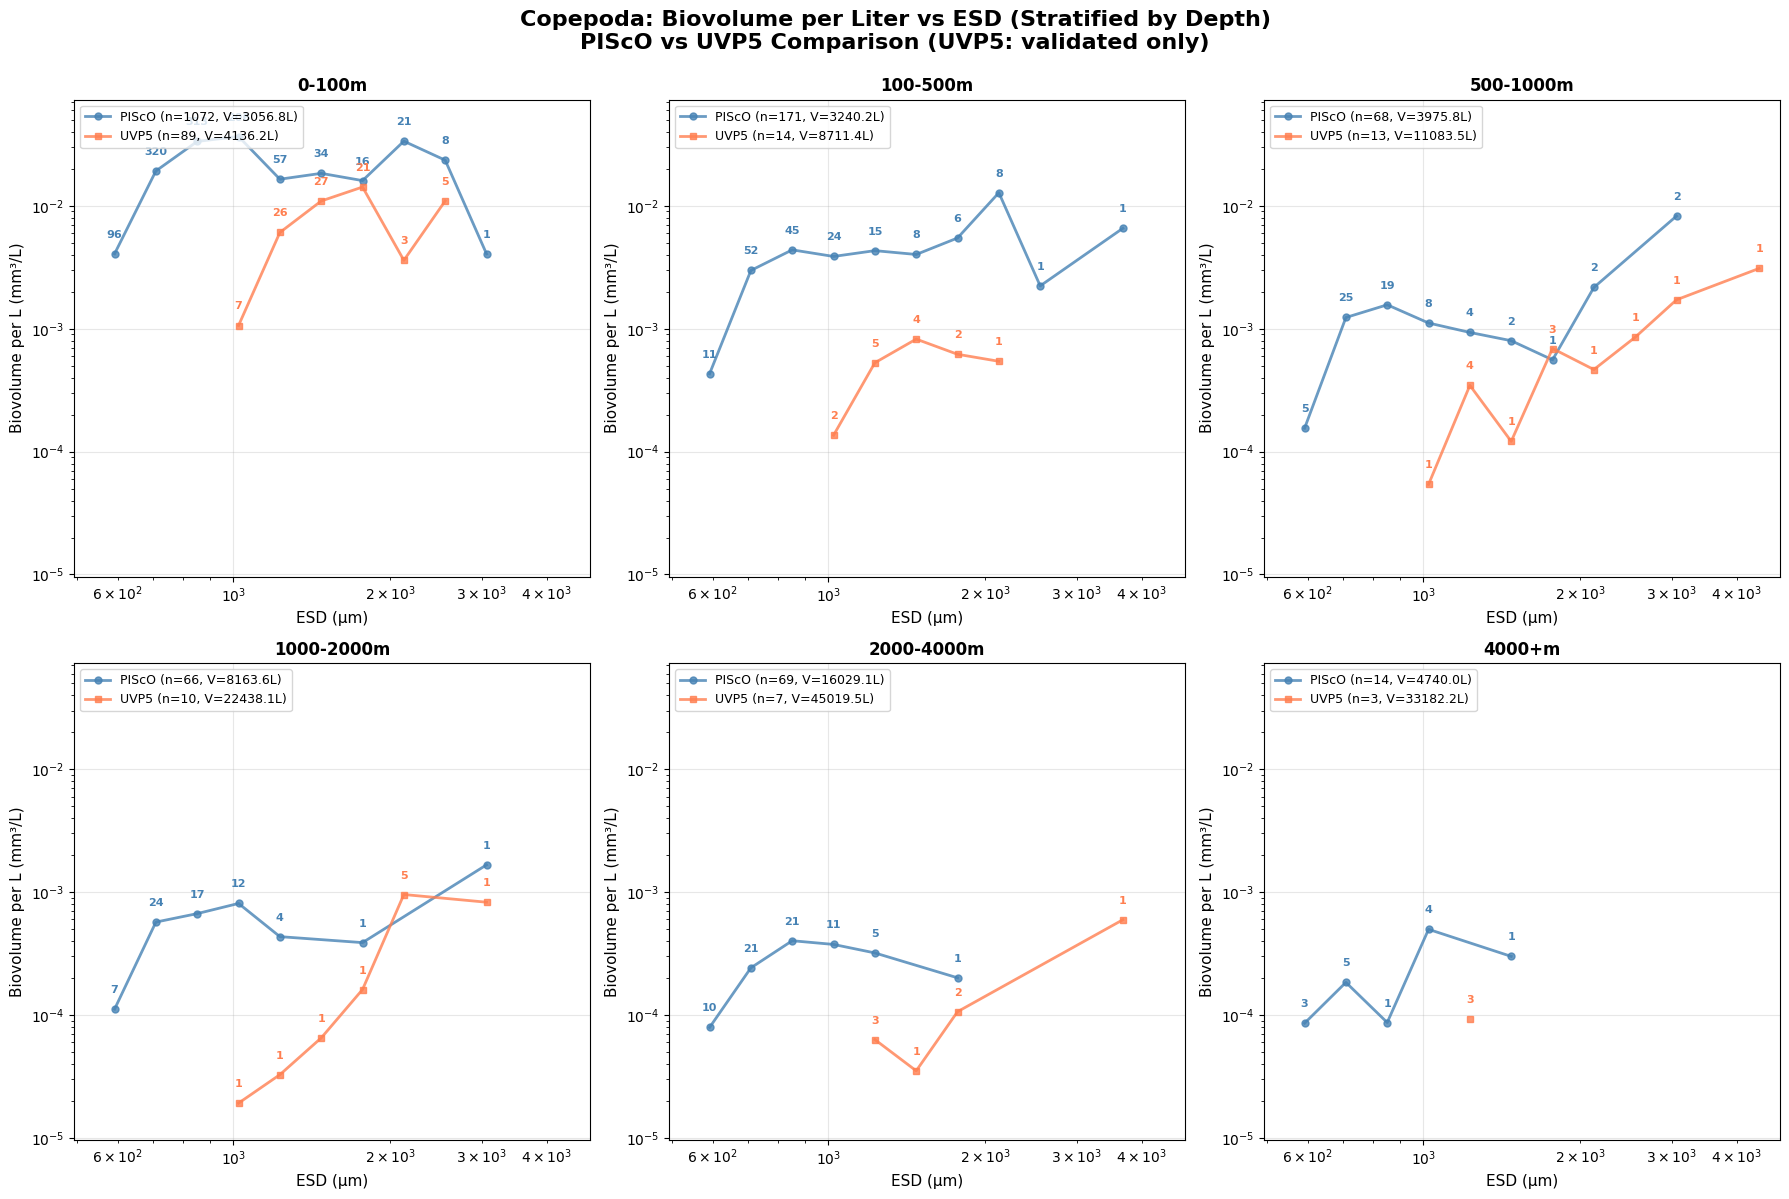


Depth-stratified comparison figure saved to: /home/veit/PIScO_dev/Segmentation_results/pisco_vs_uvp5_biovolume_per_L_by_depth_validated.png

BIOVOLUME PER LITER BY DEPTH BIN (UVP5: VALIDATED ONLY):

0-100m:
------------------------------------------------------------
  PIScO:
    Copepods: 1072
    Total biovolume: 628.13 mm³
    Sampled volume: 3056.81 L
    Biovolume per L: 0.2055 mm³/L
  UVP5 (validated):
    Copepods: 89
    Total biovolume: 193.89 mm³
    Sampled volume: 4136.16 L
    Biovolume per L: 0.0469 mm³/L
  Ratio (PIScO/UVP5): 4.38x

100-500m:
------------------------------------------------------------
  PIScO:
    Copepods: 171
    Total biovolume: 152.52 mm³
    Sampled volume: 3240.22 L
    Biovolume per L: 0.0471 mm³/L
  UVP5 (validated):
    Copepods: 14
    Total biovolume: 23.09 mm³
    Sampled volume: 8711.36 L
    Biovolume per L: 0.0027 mm³/L
  Ratio (PIScO/UVP5): 17.76x

500-1000m:
------------------------------------------------------------
  PIScO:
    Cope

In [16]:


# ============ DEFINE DEPTH BINS (SAME AS BEFORE) ============
depth_bin_edges = [0, 100, 500, 1000, 2000, 4000, 10000]  # dbar

# ✅ Generate labels with custom last label
depth_bin_labels = [f'{depth_bin_edges[i]}-{depth_bin_edges[i+1]}m' 
                    for i in range(len(depth_bin_edges)-2)]  # All except last
depth_bin_labels.append('4000+m')  # ✅ Custom label for last bin

print(f"Depth bin labels: {depth_bin_labels}")

# ============ PISCO DATA ============
# Read the full TSV to get individual ESD values
df_pisco = pd.read_csv(tsv_path, sep='\t')
df_pisco['pressure_dbar'] = df_pisco['object_pressure']

# Filter for Copepoda (PIScO data is already validated)
copepod_pisco = df_pisco[df_pisco['object_annotation_category'].str.contains('Copepod', case=False, na=False)].copy()

# ESD already in µm for PIScO
copepod_pisco['esd_um'] = copepod_pisco['object_esd']

# Calculate biovolume in mm³ for each individual
esd_mm_pisco = copepod_pisco['esd_um'] / 1000  # µm to mm
copepod_pisco['biovolume_mm3'] = (np.pi / 6) * (esd_mm_pisco ** 3)

# Assign depth bins
copepod_pisco['depth_bin'] = pd.cut(copepod_pisco['pressure_dbar'], 
                                     bins=depth_bin_edges, 
                                     labels=depth_bin_labels,
                                     include_lowest=True,
                                     right=False)

# Map volume_df labels
volume_df_mapped = volume_df.copy()
volume_df_mapped['depth_bin_label'] = volume_df_mapped['depth_bin_label'].replace('4000-10000m', '4000+m')
pisco_depth_volumes = volume_df_mapped.set_index('depth_bin_label')['sampled_volume_L'].to_dict()

print("\nPIScO sampled volumes by depth:")
for label, vol in pisco_depth_volumes.items():
    print(f"  {label}: {vol:.2f} L")


# ============ UVP5 DATA (✅ VALIDATED ONLY) ============
# Read UVP5 volume data
uvp5_volume_path = "/home/veit/PIScO_dev/Segmentation_results/export_detailed_20251113_12_27_PAR_c_m181_037.tsv"
df_uvp5_volume = pd.read_csv(uvp5_volume_path, sep='\t', encoding='latin-1')

# Read UVP5 data
df_uvp5 = pd.read_csv(tsv_path_multi, sep='\t', skiprows=[1])
df_uvp5 = df_uvp5[df_uvp5['sample_id'] == sample_id].copy()

# Combine Calanoida and Copepoda<Maxillopoda
df_uvp5.loc[df_uvp5['object_annotation_category'] == 'Calanoida', 'object_annotation_category'] = 'Copepoda<Maxillopoda'

# ✅ FILTER FOR VALIDATED COPEPODS ONLY
if 'object_annotation_status' in df_uvp5.columns:
    print("\n✅ Filtering UVP5 for VALIDATED annotations only...")
    
    copepod_uvp5 = df_uvp5[
        (df_uvp5['object_annotation_category'].str.contains('Copepod', case=False, na=False)) &
        (df_uvp5['object_annotation_status'] == 'validated')
    ].copy()
    
    all_copepods = df_uvp5[df_uvp5['object_annotation_category'].str.contains('Copepod', case=False, na=False)]
    
    print(f"   Total UVP5 copepods (all statuses): {len(all_copepods)}")
    print(f"   Total UVP5 validated copepods: {len(copepod_uvp5)}")
    print(f"   Filtered out: {len(all_copepods) - len(copepod_uvp5)} ({100 * (len(all_copepods) - len(copepod_uvp5)) / max(len(all_copepods), 1):.1f}%)")
else:
    print("\n⚠️ WARNING: 'object_annotation_status' column not found! Using all copepods.")
    copepod_uvp5 = df_uvp5[df_uvp5['object_annotation_category'].str.contains('Copepod', case=False, na=False)].copy()

# Convert ESD from pixels to µm: pixels * 88 µm/pixel
copepod_uvp5['esd_um'] = copepod_uvp5['object_esd'] * 88

# Calculate biovolume in mm³
esd_mm_uvp5 = copepod_uvp5['esd_um'] / 1000  # µm to mm
copepod_uvp5['biovolume_mm3'] = (np.pi / 6) * (esd_mm_uvp5 ** 3)

# Get pressure from object_depth_min
copepod_uvp5['pressure_dbar'] = copepod_uvp5['object_depth_min']

# Assign depth bins
copepod_uvp5['depth_bin'] = pd.cut(copepod_uvp5['pressure_dbar'], 
                                    bins=depth_bin_edges, 
                                    labels=depth_bin_labels,
                                    include_lowest=True,
                                    right=False)

# Calculate UVP5 volumes per depth bin
df_uvp5_volume['depth_bin'] = pd.cut(df_uvp5_volume['Depth [m]'], 
                                      bins=depth_bin_edges, 
                                      labels=depth_bin_labels,
                                      include_lowest=True,
                                      right=False)
uvp5_depth_volumes = df_uvp5_volume.groupby('depth_bin', observed=True)['Sampled volume [L]'].sum().to_dict()

print("\nUVP5 sampled volumes by depth:")
for label, vol in uvp5_depth_volumes.items():
    print(f"  {label}: {vol:.2f} L")


# ============ BIN BY ESD AND DEPTH ============
# Create ESD bins (logarithmic)
esd_bin_edges = np.logspace(np.log10(50), np.log10(10000), 30)  # 30 bins
esd_bin_centers = (esd_bin_edges[:-1] + esd_bin_edges[1:]) / 2


# Bin PIScO data
copepod_pisco['esd_bin'] = pd.cut(copepod_pisco['esd_um'], bins=esd_bin_edges)

# Bin UVP5 data
copepod_uvp5['esd_bin'] = pd.cut(copepod_uvp5['esd_um'], bins=esd_bin_edges)


# ============ ✅ DETERMINE GLOBAL AXIS LIMITS BEFORE PLOTTING ============
all_esd_pisco = []
all_esd_uvp5 = []
all_biovol_pisco = []
all_biovol_uvp5 = []

for depth_label in depth_bin_labels:
    pisco_depth = copepod_pisco[copepod_pisco['depth_bin'] == depth_label]
    uvp5_depth = copepod_uvp5[copepod_uvp5['depth_bin'] == depth_label]
    
    pisco_volume = pisco_depth_volumes.get(depth_label, 0)
    uvp5_volume = uvp5_depth_volumes.get(depth_label, 0)
    
    if len(pisco_depth) > 0 and pisco_volume > 0:
        pisco_binned = pisco_depth.groupby('esd_bin', observed=True).agg({
            'esd_um': 'mean',
            'biovolume_mm3': 'sum'
        }).dropna().reset_index(drop=True)
        pisco_binned['biovolume_mm3_per_L'] = pisco_binned['biovolume_mm3'] / pisco_volume
        
        all_esd_pisco.extend(pisco_binned['esd_um'].tolist())
        all_biovol_pisco.extend(pisco_binned['biovolume_mm3_per_L'].tolist())
    
    if len(uvp5_depth) > 0 and uvp5_volume > 0:
        uvp5_binned = uvp5_depth.groupby('esd_bin', observed=True).agg({
            'esd_um': 'mean',
            'biovolume_mm3': 'sum'
        }).dropna().reset_index(drop=True)
        uvp5_binned['biovolume_mm3_per_L'] = uvp5_binned['biovolume_mm3'] / uvp5_volume
        
        all_esd_uvp5.extend(uvp5_binned['esd_um'].tolist())
        all_biovol_uvp5.extend(uvp5_binned['biovolume_mm3_per_L'].tolist())

# Calculate global limits with some padding
if all_esd_pisco or all_esd_uvp5:
    all_esd = all_esd_pisco + all_esd_uvp5
    esd_min = min(all_esd) * 0.8
    esd_max = max(all_esd) * 1.2
else:
    esd_min, esd_max = 50, 10000

if all_biovol_pisco or all_biovol_uvp5:
    all_biovol = all_biovol_pisco + all_biovol_uvp5
    biovol_min = min(all_biovol) * 0.5
    biovol_max = max(all_biovol) * 2
else:
    biovol_min, biovol_max = 1e-6, 1e-1

print(f"\n✅ Global axis limits:")
print(f"   ESD: {esd_min:.1f} - {esd_max:.1f} µm")
print(f"   Biovolume per L: {biovol_min:.6f} - {biovol_max:.6f} mm³/L")


# ============ CALCULATE BIOVOLUME PER LITER BY DEPTH BIN ============
# Create figure with subplots for each depth bin
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, depth_label in enumerate(depth_bin_labels):
    ax = axes[idx]
    
    # Filter data for this depth bin
    pisco_depth = copepod_pisco[copepod_pisco['depth_bin'] == depth_label].copy()
    uvp5_depth = copepod_uvp5[copepod_uvp5['depth_bin'] == depth_label].copy()
    
    # Get sampled volume for this depth bin
    pisco_volume = pisco_depth_volumes.get(depth_label, 0)
    uvp5_volume = uvp5_depth_volumes.get(depth_label, 0)
    
    if len(pisco_depth) > 0 and pisco_volume > 0:
        # Group by ESD bin and calculate biovolume per liter + count
        pisco_binned = pisco_depth.groupby('esd_bin', observed=True).agg({
            'esd_um': 'mean',
            'biovolume_mm3': 'sum',
            'depth_bin': 'size'  # ✅ Count objects per bin
        }).rename(columns={'depth_bin': 'n_objects'}).dropna()
        
        # Calculate bin centers from index BEFORE reset
        pisco_binned['esd_bin_center'] = pisco_binned.index.map(lambda x: (x.left + x.right) / 2)
        
        pisco_binned = pisco_binned.reset_index(drop=True)
        
        pisco_binned['biovolume_mm3_per_L'] = pisco_binned['biovolume_mm3'] / pisco_volume

        # Plot PIScO line
        line = ax.plot(pisco_binned['esd_bin_center'], pisco_binned['biovolume_mm3_per_L'],
                marker='o', linewidth=2, markersize=5,
                label=f'PIScO (n={len(pisco_depth)}, V={pisco_volume:.1f}L)',
                color='steelblue', alpha=0.8)[0]
        
        # ✅ Add count annotations above each point
        for _, row in pisco_binned.iterrows():
            ax.text(row['esd_bin_center'], row['biovolume_mm3_per_L'] * 1.3,  # 30% above point
                   f"{int(row['n_objects'])}", 
                   ha='center', va='bottom', fontsize=8, 
                   color='steelblue', fontweight='bold')
    
    if len(uvp5_depth) > 0 and uvp5_volume > 0:
        uvp5_binned = uvp5_depth.groupby('esd_bin', observed=True).agg({
            'esd_um': 'mean',
            'biovolume_mm3': 'sum',
            'depth_bin': 'size'  # ✅ Count objects per bin
        }).rename(columns={'depth_bin': 'n_objects'}).dropna()
        
        # Calculate bin centers from index BEFORE reset
        uvp5_binned['esd_bin_center'] = uvp5_binned.index.map(lambda x: (x.left + x.right) / 2)
        
        uvp5_binned = uvp5_binned.reset_index(drop=True)
        
        uvp5_binned['biovolume_mm3_per_L'] = uvp5_binned['biovolume_mm3'] / uvp5_volume
        
        # Plot UVP5 line
        ax.plot(uvp5_binned['esd_bin_center'], uvp5_binned['biovolume_mm3_per_L'],
                marker='s', linewidth=2, markersize=5,
                label=f'UVP5 (n={len(uvp5_depth)}, V={uvp5_volume:.1f}L)',
                color='coral', alpha=0.8)
        
        # ✅ Add count annotations above each point
        for _, row in uvp5_binned.iterrows():
            ax.text(row['esd_bin_center'], row['biovolume_mm3_per_L'] * 1.3,
                   f"{int(row['n_objects'])}", 
                   ha='center', va='bottom', fontsize=8,
                   color='coral', fontweight='bold')
    
    ax.set_xlabel('ESD (µm)', fontsize=11)
    ax.set_ylabel('Biovolume per L (mm³/L)', fontsize=11)
    ax.set_title(f'{depth_label}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    # SET CONSISTENT AXIS LIMITS
    ax.set_xlim(esd_min, esd_max)
    ax.set_ylim(biovol_min, biovol_max)

plt.suptitle('Copepoda: Biovolume per Liter vs ESD (Stratified by Depth)\nPIScO vs UVP5 Comparison (UVP5: validated only)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Save figure
fig_path = "/home/veit/PIScO_dev/Segmentation_results/pisco_vs_uvp5_biovolume_per_L_by_depth_validated.png"
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\nDepth-stratified comparison figure saved to: {fig_path}")


# ============ PRINT STATISTICS BY DEPTH BIN ============
print("\n" + "="*80)
print("BIOVOLUME PER LITER BY DEPTH BIN (UVP5: VALIDATED ONLY):")
print("="*80)

for depth_label in depth_bin_labels:
    print(f"\n{depth_label}:")
    print("-" * 60)
    
    # PIScO
    pisco_depth = copepod_pisco[copepod_pisco['depth_bin'] == depth_label]
    pisco_volume = pisco_depth_volumes.get(depth_label, 0)
    
    if len(pisco_depth) > 0 and pisco_volume > 0:
        pisco_total_biovol = pisco_depth['biovolume_mm3'].sum()
        print(f"  PIScO:")
        print(f"    Copepods: {len(pisco_depth)}")
        print(f"    Total biovolume: {pisco_total_biovol:.2f} mm³")
        print(f"    Sampled volume: {pisco_volume:.2f} L")
        print(f"    Biovolume per L: {pisco_total_biovol / pisco_volume:.4f} mm³/L")
    else:
        print(f"  PIScO: No data")
    
    # UVP5
    uvp5_depth = copepod_uvp5[copepod_uvp5['depth_bin'] == depth_label]
    uvp5_volume = uvp5_depth_volumes.get(depth_label, 0)
    
    if len(uvp5_depth) > 0 and uvp5_volume > 0:
        uvp5_total_biovol = uvp5_depth['biovolume_mm3'].sum()
        print(f"  UVP5 (validated):")
        print(f"    Copepods: {len(uvp5_depth)}")
        print(f"    Total biovolume: {uvp5_total_biovol:.2f} mm³")
        print(f"    Sampled volume: {uvp5_volume:.2f} L")
        print(f"    Biovolume per L: {uvp5_total_biovol / uvp5_volume:.4f} mm³/L")
    else:
        print(f"  UVP5 (validated): No data")
    
    # Ratio
    if len(pisco_depth) > 0 and len(uvp5_depth) > 0 and pisco_volume > 0 and uvp5_volume > 0:
        pisco_biovol_per_L = pisco_depth['biovolume_mm3'].sum() / pisco_volume
        uvp5_biovol_per_L = uvp5_depth['biovolume_mm3'].sum() / uvp5_volume
        print(f"  Ratio (PIScO/UVP5): {pisco_biovol_per_L / uvp5_biovol_per_L:.2f}x")


# ============ OVERALL SUMMARY ============
print("\n" + "="*80)
print("OVERALL COPEPODA SUMMARY:")
print("="*80)

print("\nPIScO:")
print(f"  Total copepods: {len(copepod_pisco)}")
if len(copepod_pisco) > 0:
    print(f"  ESD range: {copepod_pisco['esd_um'].min():.1f} - {copepod_pisco['esd_um'].max():.1f} µm")
    print(f"  Total biovolume: {copepod_pisco['biovolume_mm3'].sum():.2f} mm³")
    print(f"  Overall biovolume per L: {copepod_pisco['biovolume_mm3'].sum() / sum(pisco_depth_volumes.values()):.4f} mm³/L")

print("\nUVP5 (validated):")
print(f"  Total copepods: {len(copepod_uvp5)}")
if len(copepod_uvp5) > 0:
    print(f"  ESD range: {copepod_uvp5['esd_um'].min():.1f} - {copepod_uvp5['esd_um'].max():.1f} µm")
    print(f"  Total biovolume: {copepod_uvp5['biovolume_mm3'].sum():.2f} mm³")
    print(f"  Overall biovolume per L: {copepod_uvp5['biovolume_mm3'].sum() / sum(uvp5_depth_volumes.values()):.4f} mm³/L")

In [17]:
# Validate UVP5 copepods in 4000+m depth bin (WITH VALIDATION STATUS CHECK)

print("="*80)
print("VALIDATION: UVP5 Copepods in 4000+m depth bin")
print("="*80)

# ============ CHECK VALIDATION STATUS IN ORIGINAL DATA ============
print("\nCHECKING VALIDATION STATUS:")
print("="*80)

# Check if validation status column exists
if 'object_annotation_status' in df_uvp5.columns:
    print(f"✅ 'object_annotation_status' column found")
    
    # Show all unique statuses
    print(f"\nUnique annotation statuses in df_uvp5:")
    print(df_uvp5['object_annotation_status'].value_counts())
    
    # Filter for validated copepods ONLY
    copepod_uvp5_validated = df_uvp5[
        (df_uvp5['object_annotation_category'].str.contains('Copepod', case=False, na=False)) &
        (df_uvp5['object_annotation_status'] == 'validated')
    ].copy()
    
    print(f"\n📊 BEFORE filtering by validation status:")
    print(f"   Total UVP5 copepods: {len(copepod_uvp5)}")
    
    print(f"\n📊 AFTER filtering for 'validated' status:")
    print(f"   Total UVP5 validated copepods: {len(copepod_uvp5_validated)}")
    print(f"   Filtered out: {len(copepod_uvp5) - len(copepod_uvp5_validated)} ({100 * (len(copepod_uvp5) - len(copepod_uvp5_validated)) / len(copepod_uvp5):.1f}%)")
    
    # Now reprocess with validated data only
    copepod_uvp5_validated['esd_um'] = copepod_uvp5_validated['object_esd'] * 88
    esd_mm = copepod_uvp5_validated['esd_um'] / 1000
    copepod_uvp5_validated['biovolume_mm3'] = (np.pi / 6) * (esd_mm ** 3)
    copepod_uvp5_validated['pressure_dbar'] = copepod_uvp5_validated['object_depth_min']
    
    # Assign depth bins
    copepod_uvp5_validated['depth_bin'] = pd.cut(copepod_uvp5_validated['pressure_dbar'], 
                                                   bins=depth_bin_edges, 
                                                   labels=depth_bin_labels,
                                                   include_lowest=True,
                                                   right=False)
    
    # Filter for 4000+m
    uvp5_4000plus_validated = copepod_uvp5_validated[copepod_uvp5_validated['depth_bin'] == '4000+m'].copy()
    
    print(f"\n✅ VALIDATED copepods in '4000+m' bin: {len(uvp5_4000plus_validated)}")
    if len(uvp5_4000plus_validated) > 0:
        print(f"   Depth range: {uvp5_4000plus_validated['pressure_dbar'].min():.1f} - {uvp5_4000plus_validated['pressure_dbar'].max():.1f} dbar")
    
    # Compare validated vs all
    print("\n" + "="*80)
    print("COMPARISON: All vs Validated in 4000+m")
    print("="*80)
    print(f"All UVP5 copepods in 4000+m: {len(uvp5_4000plus)}")
    print(f"Validated UVP5 copepods in 4000+m: {len(uvp5_4000plus_validated)}")
    print(f"Filtered out: {len(uvp5_4000plus) - len(uvp5_4000plus_validated)}")
    
    # Show breakdown by status in 4000+m
    print("\nBreakdown by annotation status in 4000+m:")
    uvp5_4000_all = df_uvp5[
        (df_uvp5['object_annotation_category'].str.contains('Copepod', case=False, na=False)) &
        (df_uvp5['object_depth_min'] >= 4000)
    ]
    print(uvp5_4000_all['object_annotation_status'].value_counts())
    
else:
    print("❌ 'object_annotation_status' column NOT found!")
    print(f"Available columns: {list(df_uvp5.columns)}")

VALIDATION: UVP5 Copepods in 4000+m depth bin

CHECKING VALIDATION STATUS:
✅ 'object_annotation_status' column found

Unique annotation statuses in df_uvp5:
object_annotation_status
predicted    6994
validated    1913
dubious         8
Name: count, dtype: int64

📊 BEFORE filtering by validation status:
   Total UVP5 copepods: 136

📊 AFTER filtering for 'validated' status:
   Total UVP5 validated copepods: 136
   Filtered out: 0 (0.0%)

✅ VALIDATED copepods in '4000+m' bin: 3
   Depth range: 4281.0 - 4372.8 dbar

COMPARISON: All vs Validated in 4000+m


NameError: name 'uvp5_4000plus' is not defined

Depth bin labels: ['0-100m', '100-500m', '500-1000m', '1000-2000m', '2000-4000m', '4000+m']

📊 PIScO Trichodesmium: 0 colonies

PIScO sampled volumes by depth:
  0-100m: 3056.81 L
  100-500m: 3240.22 L
  500-1000m: 3975.76 L
  1000-2000m: 8163.59 L
  2000-4000m: 16029.14 L
  4000+m: 4739.96 L

✅ Filtering UVP5 for VALIDATED Trichodesmium annotations only...
   Total UVP5 Trichodesmium (all statuses): 1459
   Total UVP5 validated Trichodesmium: 1445
   Filtered out: 14 (1.0%)

UVP5 sampled volumes by depth:
  0-100m: 4136.16 L
  100-500m: 8711.36 L
  500-1000m: 11083.52 L
  1000-2000m: 22438.08 L
  2000-4000m: 45019.52 L
  4000+m: 33182.24 L

✅ Global axis limits:
   ESD: 719.3 - 2974.1 µm
   Biovolume per L: 0.000004 - 0.272856 mm³/L


/tmp/ipykernel_699094/659310946.py:218: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9, loc='upper left')


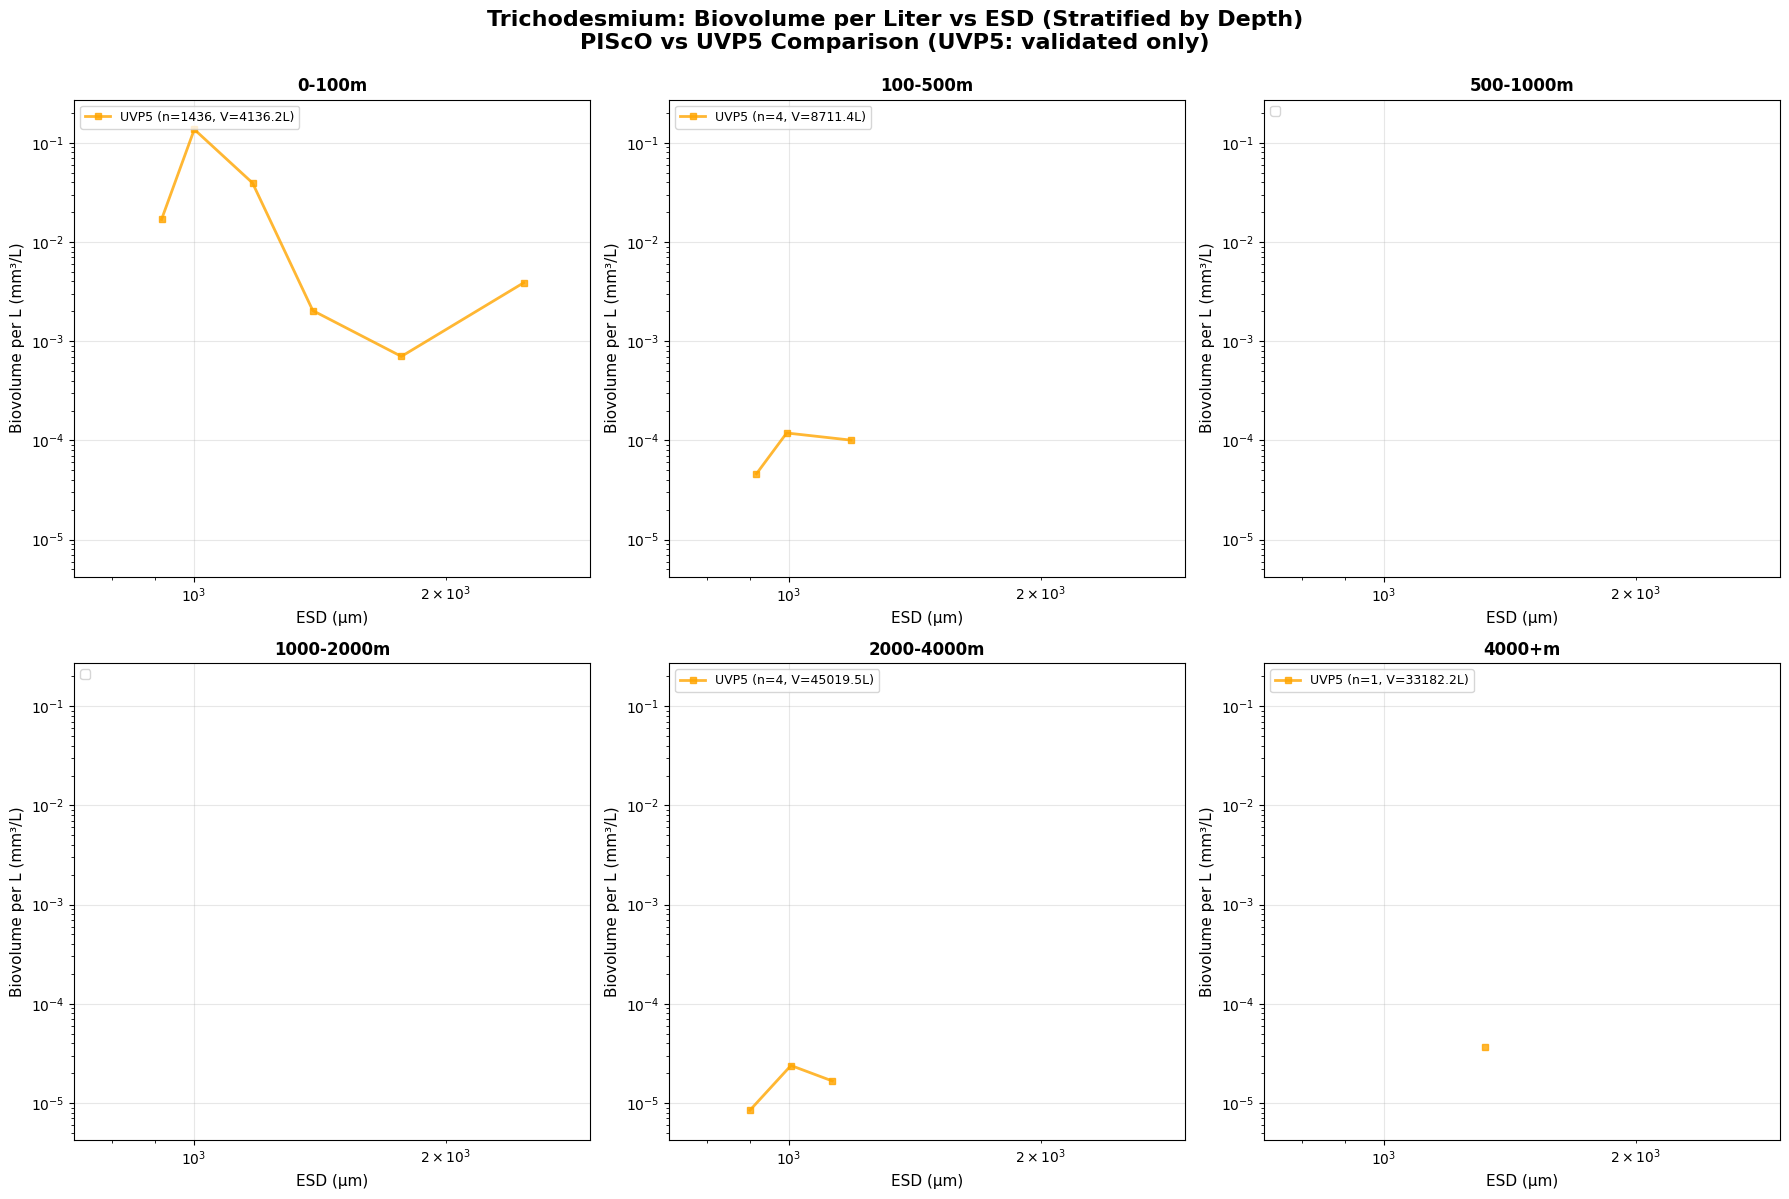


Depth-stratified Trichodesmium comparison figure saved to: /home/veit/PIScO_dev/Segmentation_results/pisco_vs_uvp5_trichodesmium_biovolume_per_L_by_depth_validated.png

TRICHODESMIUM BIOVOLUME PER LITER BY DEPTH BIN (UVP5: VALIDATED ONLY):

0-100m:
------------------------------------------------------------
  PIScO: No data
  UVP5 (validated):
    Trichodesmium colonies: 1436
    Total biovolume: 824.40 mm³
    Sampled volume: 4136.16 L
    Biovolume per L: 0.1993 mm³/L

100-500m:
------------------------------------------------------------
  PIScO: No data
  UVP5 (validated):
    Trichodesmium colonies: 4
    Total biovolume: 2.31 mm³
    Sampled volume: 8711.36 L
    Biovolume per L: 0.0003 mm³/L

500-1000m:
------------------------------------------------------------
  PIScO: No data
  UVP5 (validated): No data

1000-2000m:
------------------------------------------------------------
  PIScO: No data
  UVP5 (validated): No data

2000-4000m:
----------------------------------------

In [19]:
# Combined Plot: PIScO vs UVP5 - Biovolume per Liter vs ESD for TRICHODESMIUM (STRATIFIED BY DEPTH)
# ✅ WITH CONSISTENT AXIS LIMITS

# ============ DEFINE DEPTH BINS (SAME AS COPEPODA) ============
depth_bin_edges = [0, 100, 500, 1000, 2000, 4000, 10000]  # dbar

# ✅ Generate labels with custom last label
depth_bin_labels = [f'{depth_bin_edges[i]}-{depth_bin_edges[i+1]}m' 
                    for i in range(len(depth_bin_edges)-2)]  # All except last
depth_bin_labels.append('4000+m')  # ✅ Custom label for last bin

print(f"Depth bin labels: {depth_bin_labels}")

# ============ PISCO DATA ============
# Read the full TSV to get individual ESD values
df_pisco = pd.read_csv(tsv_path, sep='\t')
df_pisco['pressure_dbar'] = df_pisco['object_pressure']

# Filter for Trichodesmium (PIScO data is already validated)
tricho_pisco = df_pisco[df_pisco['object_annotation_category'].str.contains('Trichodesmium', case=False, na=False)].copy()

print(f"\n📊 PIScO Trichodesmium: {len(tricho_pisco)} colonies")

# ESD already in µm for PIScO
tricho_pisco['esd_um'] = tricho_pisco['object_esd']

# Calculate biovolume in mm³ for each individual
esd_mm_pisco = tricho_pisco['esd_um'] / 1000  # µm to mm
tricho_pisco['biovolume_mm3'] = (np.pi / 6) * (esd_mm_pisco ** 3)

# Assign depth bins
tricho_pisco['depth_bin'] = pd.cut(tricho_pisco['pressure_dbar'], 
                                    bins=depth_bin_edges, 
                                    labels=depth_bin_labels,
                                    include_lowest=True,
                                    right=False)

# Map volume_df labels (use same volumes as copepod analysis)
volume_df_mapped = volume_df.copy()
volume_df_mapped['depth_bin_label'] = volume_df_mapped['depth_bin_label'].replace('4000-10000m', '4000+m')
pisco_depth_volumes = volume_df_mapped.set_index('depth_bin_label')['sampled_volume_L'].to_dict()

print("\nPIScO sampled volumes by depth:")
for label, vol in pisco_depth_volumes.items():
    print(f"  {label}: {vol:.2f} L")


# ============ UVP5 DATA (✅ VALIDATED ONLY) ============
# Read UVP5 volume data
uvp5_volume_path = "/home/veit/PIScO_dev/Segmentation_results/export_detailed_20251113_12_27_PAR_c_m181_037.tsv"
df_uvp5_volume = pd.read_csv(uvp5_volume_path, sep='\t', encoding='latin-1')

# Read UVP5 data
df_uvp5 = pd.read_csv(tsv_path_multi, sep='\t', skiprows=[1])
df_uvp5 = df_uvp5[df_uvp5['sample_id'] == sample_id].copy()

# ✅ FILTER FOR VALIDATED TRICHODESMIUM ONLY
if 'object_annotation_status' in df_uvp5.columns:
    print("\n✅ Filtering UVP5 for VALIDATED Trichodesmium annotations only...")
    
    tricho_uvp5 = df_uvp5[
        (df_uvp5['object_annotation_category'].str.contains('Trichodesmium', case=False, na=False)) &
        (df_uvp5['object_annotation_status'] == 'validated')
    ].copy()
    
    all_tricho = df_uvp5[df_uvp5['object_annotation_category'].str.contains('Trichodesmium', case=False, na=False)]
    
    print(f"   Total UVP5 Trichodesmium (all statuses): {len(all_tricho)}")
    print(f"   Total UVP5 validated Trichodesmium: {len(tricho_uvp5)}")
    print(f"   Filtered out: {len(all_tricho) - len(tricho_uvp5)} ({100 * (len(all_tricho) - len(tricho_uvp5)) / max(len(all_tricho), 1):.1f}%)")
else:
    print("\n⚠️ WARNING: 'object_annotation_status' column not found! Using all Trichodesmium.")
    tricho_uvp5 = df_uvp5[df_uvp5['object_annotation_category'].str.contains('Trichodesmium', case=False, na=False)].copy()

# Convert ESD from pixels to µm: pixels * 88 µm/pixel
tricho_uvp5['esd_um'] = tricho_uvp5['object_esd'] * 88

# Calculate biovolume in mm³
esd_mm_uvp5 = tricho_uvp5['esd_um'] / 1000  # µm to mm
tricho_uvp5['biovolume_mm3'] = (np.pi / 6) * (esd_mm_uvp5 ** 3)

# Get pressure from object_depth_min
tricho_uvp5['pressure_dbar'] = tricho_uvp5['object_depth_min']

# Assign depth bins
tricho_uvp5['depth_bin'] = pd.cut(tricho_uvp5['pressure_dbar'], 
                                   bins=depth_bin_edges, 
                                   labels=depth_bin_labels,
                                   include_lowest=True,
                                   right=False)

# Calculate UVP5 volumes per depth bin
df_uvp5_volume['depth_bin'] = pd.cut(df_uvp5_volume['Depth [m]'], 
                                      bins=depth_bin_edges, 
                                      labels=depth_bin_labels,
                                      include_lowest=True,
                                      right=False)
uvp5_depth_volumes = df_uvp5_volume.groupby('depth_bin', observed=True)['Sampled volume [L]'].sum().to_dict()

print("\nUVP5 sampled volumes by depth:")
for label, vol in uvp5_depth_volumes.items():
    print(f"  {label}: {vol:.2f} L")


# ============ BIN BY ESD AND DEPTH ============
# Create ESD bins (logarithmic)
esd_bin_edges = np.logspace(np.log10(50), np.log10(10000), 30)  # 30 bins

# Bin PIScO data
tricho_pisco['esd_bin'] = pd.cut(tricho_pisco['esd_um'], bins=esd_bin_edges)

# Bin UVP5 data
tricho_uvp5['esd_bin'] = pd.cut(tricho_uvp5['esd_um'], bins=esd_bin_edges)


# ============ ✅ DETERMINE GLOBAL AXIS LIMITS BEFORE PLOTTING ============
all_esd_pisco = []
all_esd_uvp5 = []
all_biovol_pisco = []
all_biovol_uvp5 = []

for depth_label in depth_bin_labels:
    pisco_depth = tricho_pisco[tricho_pisco['depth_bin'] == depth_label]
    uvp5_depth = tricho_uvp5[tricho_uvp5['depth_bin'] == depth_label]
    
    pisco_volume = pisco_depth_volumes.get(depth_label, 0)
    uvp5_volume = uvp5_depth_volumes.get(depth_label, 0)
    
    if len(pisco_depth) > 0 and pisco_volume > 0:
        pisco_binned = pisco_depth.groupby('esd_bin', observed=True).agg({
            'esd_um': 'mean',
            'biovolume_mm3': 'sum'
        }).dropna().reset_index(drop=True)
        pisco_binned['biovolume_mm3_per_L'] = pisco_binned['biovolume_mm3'] / pisco_volume
        
        all_esd_pisco.extend(pisco_binned['esd_um'].tolist())
        all_biovol_pisco.extend(pisco_binned['biovolume_mm3_per_L'].tolist())
    
    if len(uvp5_depth) > 0 and uvp5_volume > 0:
        uvp5_binned = uvp5_depth.groupby('esd_bin', observed=True).agg({
            'esd_um': 'mean',
            'biovolume_mm3': 'sum'
        }).dropna().reset_index(drop=True)
        uvp5_binned['biovolume_mm3_per_L'] = uvp5_binned['biovolume_mm3'] / uvp5_volume
        
        all_esd_uvp5.extend(uvp5_binned['esd_um'].tolist())
        all_biovol_uvp5.extend(uvp5_binned['biovolume_mm3_per_L'].tolist())

# Calculate global limits with some padding
if all_esd_pisco or all_esd_uvp5:
    all_esd = all_esd_pisco + all_esd_uvp5
    esd_min = min(all_esd) * 0.8
    esd_max = max(all_esd) * 1.2
else:
    esd_min, esd_max = 50, 10000

if all_biovol_pisco or all_biovol_uvp5:
    all_biovol = all_biovol_pisco + all_biovol_uvp5
    biovol_min = min(all_biovol) * 0.5
    biovol_max = max(all_biovol) * 2
else:
    biovol_min, biovol_max = 1e-6, 1e-1

print(f"\n✅ Global axis limits:")
print(f"   ESD: {esd_min:.1f} - {esd_max:.1f} µm")
print(f"   Biovolume per L: {biovol_min:.6f} - {biovol_max:.6f} mm³/L")


# ============ CALCULATE BIOVOLUME PER LITER BY DEPTH BIN ============
# Create figure with subplots for each depth bin
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, depth_label in enumerate(depth_bin_labels):
    ax = axes[idx]
    
    # Filter data for this depth bin
    pisco_depth = tricho_pisco[tricho_pisco['depth_bin'] == depth_label].copy()
    uvp5_depth = tricho_uvp5[tricho_uvp5['depth_bin'] == depth_label].copy()
    
    # Get sampled volume for this depth bin
    pisco_volume = pisco_depth_volumes.get(depth_label, 0)
    uvp5_volume = uvp5_depth_volumes.get(depth_label, 0)
    
    if len(pisco_depth) > 0 and pisco_volume > 0:
        # Group by ESD bin and calculate biovolume per liter
        pisco_binned = pisco_depth.groupby('esd_bin', observed=True).agg({
            'esd_um': 'mean',
            'biovolume_mm3': 'sum'
        }).dropna().reset_index(drop=True)
        
        pisco_binned['biovolume_mm3_per_L'] = pisco_binned['biovolume_mm3'] / pisco_volume
        
        # Plot PIScO
        ax.plot(pisco_binned['esd_um'], pisco_binned['biovolume_mm3_per_L'],
                marker='o', linewidth=2, markersize=5,
                label=f'PIScO (n={len(pisco_depth)}, V={pisco_volume:.1f}L)',
                color='green', alpha=0.8)
    
    if len(uvp5_depth) > 0 and uvp5_volume > 0:
        # Group by ESD bin and calculate biovolume per liter
        uvp5_binned = uvp5_depth.groupby('esd_bin', observed=True).agg({
            'esd_um': 'mean',
            'biovolume_mm3': 'sum'
        }).dropna().reset_index(drop=True)
        
        uvp5_binned['biovolume_mm3_per_L'] = uvp5_binned['biovolume_mm3'] / uvp5_volume
        
        # Plot UVP5
        ax.plot(uvp5_binned['esd_um'], uvp5_binned['biovolume_mm3_per_L'],
                marker='s', linewidth=2, markersize=5,
                label=f'UVP5 (n={len(uvp5_depth)}, V={uvp5_volume:.1f}L)',
                color='orange', alpha=0.8)
    
    ax.set_xlabel('ESD (µm)', fontsize=11)
    ax.set_ylabel('Biovolume per L (mm³/L)', fontsize=11)
    ax.set_title(f'{depth_label}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    # ✅ SET CONSISTENT AXIS LIMITS
    ax.set_xlim(esd_min, esd_max)
    ax.set_ylim(biovol_min, biovol_max)

plt.suptitle('Trichodesmium: Biovolume per Liter vs ESD (Stratified by Depth)\nPIScO vs UVP5 Comparison (UVP5: validated only)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Save figure
fig_path = "/home/veit/PIScO_dev/Segmentation_results/pisco_vs_uvp5_trichodesmium_biovolume_per_L_by_depth_validated.png"
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\nDepth-stratified Trichodesmium comparison figure saved to: {fig_path}")


# ============ PRINT STATISTICS BY DEPTH BIN ============
print("\n" + "="*80)
print("TRICHODESMIUM BIOVOLUME PER LITER BY DEPTH BIN (UVP5: VALIDATED ONLY):")
print("="*80)

for depth_label in depth_bin_labels:
    print(f"\n{depth_label}:")
    print("-" * 60)
    
    # PIScO
    pisco_depth = tricho_pisco[tricho_pisco['depth_bin'] == depth_label]
    pisco_volume = pisco_depth_volumes.get(depth_label, 0)
    
    if len(pisco_depth) > 0 and pisco_volume > 0:
        pisco_total_biovol = pisco_depth['biovolume_mm3'].sum()
        print(f"  PIScO:")
        print(f"    Trichodesmium colonies: {len(pisco_depth)}")
        print(f"    Total biovolume: {pisco_total_biovol:.2f} mm³")
        print(f"    Sampled volume: {pisco_volume:.2f} L")
        print(f"    Biovolume per L: {pisco_total_biovol / pisco_volume:.4f} mm³/L")
    else:
        print(f"  PIScO: No data")
    
    # UVP5
    uvp5_depth = tricho_uvp5[tricho_uvp5['depth_bin'] == depth_label]
    uvp5_volume = uvp5_depth_volumes.get(depth_label, 0)
    
    if len(uvp5_depth) > 0 and uvp5_volume > 0:
        uvp5_total_biovol = uvp5_depth['biovolume_mm3'].sum()
        print(f"  UVP5 (validated):")
        print(f"    Trichodesmium colonies: {len(uvp5_depth)}")
        print(f"    Total biovolume: {uvp5_total_biovol:.2f} mm³")
        print(f"    Sampled volume: {uvp5_volume:.2f} L")
        print(f"    Biovolume per L: {uvp5_total_biovol / uvp5_volume:.4f} mm³/L")
    else:
        print(f"  UVP5 (validated): No data")
    
    # Ratio
    if len(pisco_depth) > 0 and len(uvp5_depth) > 0 and pisco_volume > 0 and uvp5_volume > 0:
        pisco_biovol_per_L = pisco_depth['biovolume_mm3'].sum() / pisco_volume
        uvp5_biovol_per_L = uvp5_depth['biovolume_mm3'].sum() / uvp5_volume
        print(f"  Ratio (PIScO/UVP5): {pisco_biovol_per_L / uvp5_biovol_per_L:.2f}x")


# ============ OVERALL SUMMARY ============
print("\n" + "="*80)
print("OVERALL TRICHODESMIUM SUMMARY:")
print("="*80)

print("\nPIScO:")
print(f"  Total Trichodesmium: {len(tricho_pisco)}")
if len(tricho_pisco) > 0:
    print(f"  ESD range: {tricho_pisco['esd_um'].min():.1f} - {tricho_pisco['esd_um'].max():.1f} µm")
    print(f"  Total biovolume: {tricho_pisco['biovolume_mm3'].sum():.2f} mm³")
    print(f"  Overall biovolume per L: {tricho_pisco['biovolume_mm3'].sum() / sum(pisco_depth_volumes.values()):.4f} mm³/L")

print("\nUVP5 (validated):")
print(f"  Total Trichodesmium: {len(tricho_uvp5)}")
if len(tricho_uvp5) > 0:
    print(f"  ESD range: {tricho_uvp5['esd_um'].min():.1f} - {tricho_uvp5['esd_um'].max():.1f} µm")
    print(f"  Total biovolume: {tricho_uvp5['biovolume_mm3'].sum():.2f} mm³")
    print(f"  Overall biovolume per L: {tricho_uvp5['biovolume_mm3'].sum() / sum(uvp5_depth_volumes.values()):.4f} mm³/L")

In [4]:
# ============ MULTIPLE PROFILES CONFIGURATION ============

# PIScO profiles (list of dictionaries)
pisco_profiles = [
    {
        'tsv_path': "/home/veit/PIScO_dev/Segmentation_results/ecotaxa_M181-175-1_CTD-050_00Â°00S-019Â°00W_20220509-0543.tsv",
        'profile_name': "M181-175-1_CTD-050_00°00S-019°00W_20220509-0543",
        'mask_radius': 1550
    },
    {
        'tsv_path': "/home/veit/PIScO_dev/Segmentation_results/PISCO_CTD037_data.tsv",
        'profile_name': "M181-112-1_CTD-037_00°00S-008°00W_20220504-1758",
        'mask_radius': 1550
    },
    {
        'tsv_path': "/home/veit/PIScO_dev/Segmentation_results/ecotaxa_M181-227-1_CTD-060_00Â°00S-027Â°00W_20220512-1748.tsv",
        'profile_name': "M181-227-1_CTD-060_00°00S-027°00W_20220512-1748",
        'mask_radius': 1550
    },
    {
        'tsv_path': "/home/veit/PIScO_dev/Segmentation_results/ecotaxa_M181-285-1_CTD-075_00Â°00S-039Â°00W_20220517-2024.tsv",
        'profile_name': "M181-285-1_CTD-075_00°00S-039°00W_20220517-2024",
        'mask_radius': 1550
    },
    {
        'tsv_path': "/home/veit/PIScO_dev/Segmentation_results/ecotaxa_M181-297-1_CTD-081_00Â°00S-041Â°50W_20220519-0218.tsv",
        'profile_name': "M181-297-1_CTD-081_00°00S-041°50W_20220519-0218",
        'mask_radius': 1550
    },
]

# PIScO image folder base path
pisco_image_base = "/mnt/filer/M181/M181-PISCO-Profiles"

# UVP5 samples (list of dictionaries with sample_id and volume_path)
uvp5_samples = [
    {
        'sample_id': "c_m181_050",
        'volume_path': "/home/veit/PIScO_dev/Segmentation_results/export_detailed_20251113_12_27_PAR_c_m181_050.tsv"
    },
    {
        'sample_id': "c_m181_037",
        'volume_path': "/home/veit/PIScO_dev/Segmentation_results/export_detailed_20251113_12_27_PAR_c_m181_037.tsv"
    },
    {
        'sample_id': "c_m181_060",
        'volume_path': "/home/veit/PIScO_dev/Segmentation_results/export_detailed_20251113_12_27_PAR_c_m181_060.tsv"
    },
    {
        'sample_id': "c_m181_075",
        'volume_path': "/home/veit/PIScO_dev/Segmentation_results/export_detailed_20251113_12_27_PAR_c_m181_075.tsv"
    },
    {
        'sample_id': "c_m181_081",
        'volume_path': "/home/veit/PIScO_dev/Segmentation_results/export_detailed_20251113_12_27_PAR_c_m181_081.tsv"
    },
]

# UVP5 data paths
tsv_path_multi = "/home/veit/PIScO_dev/Segmentation_results/ecotaxa_export__TSV_17905_20251113_1239.tsv"
uvp5_volume_path = "/home/veit/PIScO_dev/Segmentation_results/export_detailed_20251113_12_27_PAR_c_m181_037.tsv"

Depth bin labels: ['0-200m', '200-1000m', '1000+m']

PROCESSING PIScO PROFILES

Processing PIScO profile: M181-175-1_CTD-050_00°00S-019°00W_20220509-0543
Processing M181-175-1_CTD-050_00°00S-019°00W_20220509-0543...
  Mask radius: 1550 pixels, Volume per image: 1.910506 L
  Found 20521 images
  Calculated volumes for 3 custom depth bins
  Depth bins: ['200-1000m', '0-200m', '1000-10000m']
  Found 11990 objects in 14 categories
  Depth range: 10.0 - 4445.5 dbar
  Total organisms: 11990
  Total sampled volume: 39205.48 L
  Total biovolume: 58041.19 mm³

Processing PIScO profile: M181-112-1_CTD-037_00°00S-008°00W_20220504-1758
Processing M181-112-1_CTD-037_00°00S-008°00W_20220504-1758...
  Mask radius: 1550 pixels, Volume per image: 1.910506 L
  Found 24347 images
  Calculated volumes for 3 custom depth bins
  Depth bins: ['1000-10000m', '200-1000m', '0-200m']
  Found 3550 objects in 6 categories
  Depth range: 10.3 - 5277.5 dbar
  Total organisms: 3550
  Total sampled volume: 46515.08 L


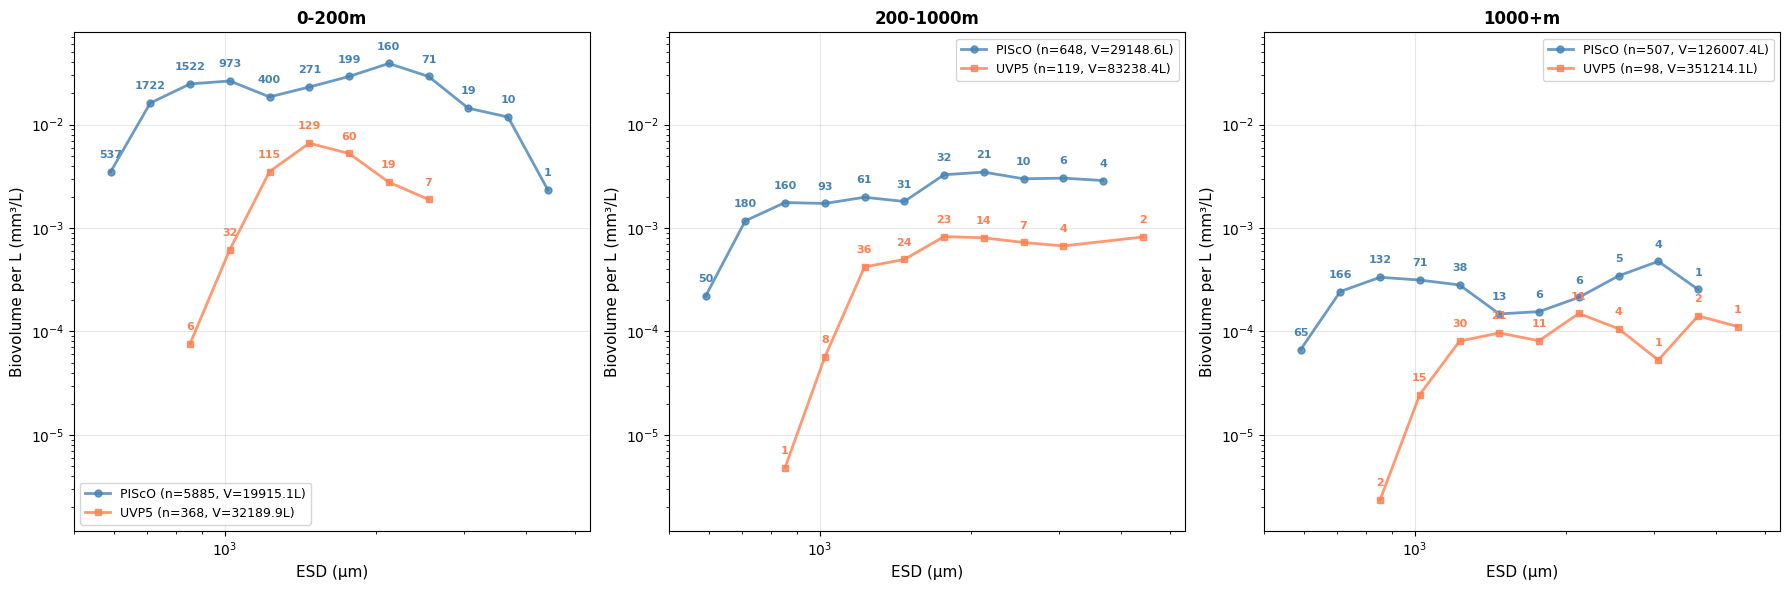

In [18]:
# ============ PROCESS MULTIPLE PROFILES ============

# Define depth bins
depth_bin_edges = [0, 200, 1000, 10000]
depth_bin_labels = [f'{depth_bin_edges[i]}-{depth_bin_edges[i+1]}m' 
                    for i in range(len(depth_bin_edges)-2)]
depth_bin_labels.append('1000+m')

print(f"Depth bin labels: {depth_bin_labels}")

# ============ PROCESS ALL PIScO PROFILES ============
print("\n" + "="*80)
print("PROCESSING PIScO PROFILES")
print("="*80)

all_copepod_pisco = []
all_pisco_volumes = defaultdict(float)  # Accumulate volumes per depth bin

for profile_config in pisco_profiles:
    tsv_path = profile_config['tsv_path']
    profile_name = profile_config['profile_name']
    mask_radius = profile_config['mask_radius']
    image_folder_path = os.path.join(pisco_image_base, profile_name)
    
    print(f"\nProcessing PIScO profile: {profile_name}")
    
    # Process this profile
    result_df, volume_df = process_single_profile_tsv_with_custom_bins(
        tsv_path, image_folder_path, profile_name, mask_radius, 
        depth_bin_edges=depth_bin_edges
    )
    
    # Read copepod data
    df_pisco = pd.read_csv(tsv_path, sep='\t')
    df_pisco['pressure_dbar'] = df_pisco['object_pressure']
    df_pisco.loc[df_pisco['object_annotation_category'] == 'Calanoida', 'object_annotation_category'] = 'Copepoda<Maxillopoda'
    df_pisco.loc[df_pisco['object_annotation_category'] == 'Oitona', 'object_annotation_category'] = 'Copepoda<Maxillopoda'
    copepod_pisco = df_pisco[df_pisco['object_annotation_category'].str.contains('Copepod', case=False, na=False)].copy()
    
    # Calculate biovolume
    copepod_pisco['esd_um'] = copepod_pisco['object_esd']
    esd_mm = copepod_pisco['esd_um'] / 1000
    copepod_pisco['biovolume_mm3'] = (np.pi / 6) * (esd_mm ** 3)
    
    # Assign depth bins
    copepod_pisco['depth_bin'] = pd.cut(copepod_pisco['pressure_dbar'], 
                                         bins=depth_bin_edges, 
                                         labels=depth_bin_labels,
                                         include_lowest=True,
                                         right=False)
    
    copepod_pisco['profile'] = profile_name
    all_copepod_pisco.append(copepod_pisco)
    
    # Accumulate volumes
    volume_df_mapped = volume_df.copy()
    volume_df_mapped['depth_bin_label'] = volume_df_mapped['depth_bin_label'].replace('1000-10000m', '1000+m')
    for _, row in volume_df_mapped.iterrows():
        all_pisco_volumes[row['depth_bin_label']] += row['sampled_volume_L']

# Combine all PIScO data
copepod_pisco = pd.concat(all_copepod_pisco, ignore_index=True)
pisco_depth_volumes = dict(all_pisco_volumes)

print(f"\n✅ Combined PIScO data: {len(copepod_pisco)} copepods from {len(pisco_profiles)} profiles")
print("\nCombined PIScO volumes by depth:")
for label, vol in pisco_depth_volumes.items():
    print(f"  {label}: {vol:.2f} L")


# ============ PROCESS ALL UVP5 SAMPLES ============
print("\n" + "="*80)
print("PROCESSING UVP5 SAMPLES")
print("="*80)

# Read UVP5 copepod data (all samples)
df_uvp5 = pd.read_csv(tsv_path_multi, sep='\t', skiprows=[1])

# Extract sample IDs from config
sample_ids = [s['sample_id'] for s in uvp5_samples]

# Filter for selected samples only
df_uvp5 = df_uvp5[df_uvp5['sample_id'].isin(sample_ids)].copy()

print(f"Processing UVP5 samples: {sample_ids}")

# Combine Calanoida and Copepoda<Maxillopoda
df_uvp5.loc[df_uvp5['object_annotation_category'] == 'Calanoida', 'object_annotation_category'] = 'Copepoda<Maxillopoda'

# Filter for validated copepods only
if 'object_annotation_status' in df_uvp5.columns:
    print("✅ Filtering for validated annotations only...")
    copepod_uvp5 = df_uvp5[
        (df_uvp5['object_annotation_category'].str.contains('Copepod', case=False, na=False)) &
        (df_uvp5['object_annotation_status'] == 'validated')
    ].copy()
else:
    copepod_uvp5 = df_uvp5[df_uvp5['object_annotation_category'].str.contains('Copepod', case=False, na=False)].copy()

print(f"✅ Combined UVP5 data: {len(copepod_uvp5)} validated copepods from {len(uvp5_samples)} samples")

# Calculate biovolume
copepod_uvp5['esd_um'] = copepod_uvp5['object_esd'] * 88
esd_mm_uvp5 = copepod_uvp5['esd_um'] / 1000
copepod_uvp5['biovolume_mm3'] = (np.pi / 6) * (esd_mm_uvp5 ** 3)
copepod_uvp5['pressure_dbar'] = copepod_uvp5['object_depth_min']

# Assign depth bins
copepod_uvp5['depth_bin'] = pd.cut(copepod_uvp5['pressure_dbar'], 
                                    bins=depth_bin_edges, 
                                    labels=depth_bin_labels,
                                    include_lowest=True,
                                    right=False)

# ============ LOAD AND COMBINE VOLUME DATA FROM EACH SAMPLE ============
all_uvp5_volume_dfs = []

for sample_config in uvp5_samples:
    sample_id = sample_config['sample_id']
    volume_path = sample_config['volume_path']
    
    print(f"\nLoading volume data for {sample_id} from {volume_path}")
    
    try:
        df_volume = pd.read_csv(volume_path, sep='\t', encoding='latin-1')
        df_volume['sample_id'] = sample_id  # Tag with sample ID
        all_uvp5_volume_dfs.append(df_volume)
        print(f"  ✅ Loaded {len(df_volume)} depth bins")
    except Exception as e:
        print(f"  ❌ Error loading {volume_path}: {e}")

# Combine all volume data
df_uvp5_volume_combined = pd.concat(all_uvp5_volume_dfs, ignore_index=True)

print(f"\n✅ Combined volume data: {len(df_uvp5_volume_combined)} rows from {len(uvp5_samples)} samples")

# Calculate UVP5 volumes per depth bin (summed across all samples)
df_uvp5_volume_combined['depth_bin'] = pd.cut(df_uvp5_volume_combined['Depth [m]'], 
                                               bins=depth_bin_edges, 
                                               labels=depth_bin_labels,
                                               include_lowest=True,
                                               right=False)
uvp5_depth_volumes = df_uvp5_volume_combined.groupby('depth_bin', observed=True)['Sampled volume [L]'].sum().to_dict()

print("\nCombined UVP5 volumes by depth:")
for label, vol in uvp5_depth_volumes.items():
    print(f"  {label}: {vol:.2f} L")


# ============ BIN BY ESD ============
esd_bin_edges = np.logspace(np.log10(50), np.log10(10000), 30)
copepod_pisco['esd_bin'] = pd.cut(copepod_pisco['esd_um'], bins=esd_bin_edges)
copepod_uvp5['esd_bin'] = pd.cut(copepod_uvp5['esd_um'], bins=esd_bin_edges)


# ============ DETERMINE GLOBAL AXIS LIMITS ============
all_esd_pisco = []
all_esd_uvp5 = []
all_biovol_pisco = []
all_biovol_uvp5 = []

for depth_label in depth_bin_labels:
    pisco_depth = copepod_pisco[copepod_pisco['depth_bin'] == depth_label]
    uvp5_depth = copepod_uvp5[copepod_uvp5['depth_bin'] == depth_label]
    
    pisco_volume = pisco_depth_volumes.get(depth_label, 0)
    uvp5_volume = uvp5_depth_volumes.get(depth_label, 0)
    
    if len(pisco_depth) > 0 and pisco_volume > 0:
        pisco_binned = pisco_depth.groupby('esd_bin', observed=True).agg({
            'esd_um': 'mean',
            'biovolume_mm3': 'sum'
        }).dropna().reset_index(drop=True)
        pisco_binned['biovolume_mm3_per_L'] = pisco_binned['biovolume_mm3'] / pisco_volume
        
        all_esd_pisco.extend(pisco_binned['esd_um'].tolist())
        all_biovol_pisco.extend(pisco_binned['biovolume_mm3_per_L'].tolist())
    
    if len(uvp5_depth) > 0 and uvp5_volume > 0:
        uvp5_binned = uvp5_depth.groupby('esd_bin', observed=True).agg({
            'esd_um': 'mean',
            'biovolume_mm3': 'sum'
        }).dropna().reset_index(drop=True)
        uvp5_binned['biovolume_mm3_per_L'] = uvp5_binned['biovolume_mm3'] / uvp5_volume
        
        all_esd_uvp5.extend(uvp5_binned['esd_um'].tolist())
        all_biovol_uvp5.extend(uvp5_binned['biovolume_mm3_per_L'].tolist())

if all_esd_pisco or all_esd_uvp5:
    all_esd = all_esd_pisco + all_esd_uvp5
    esd_min = min(all_esd) * 0.8
    esd_max = max(all_esd) * 1.2
else:
    esd_min, esd_max = 50, 10000

if all_biovol_pisco or all_biovol_uvp5:
    all_biovol = all_biovol_pisco + all_biovol_uvp5
    biovol_min = min(all_biovol) * 0.5
    biovol_max = max(all_biovol) * 2
else:
    biovol_min, biovol_max = 1e-6, 1e-1


# ============ PLOT ============
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

for idx, depth_label in enumerate(depth_bin_labels):
    ax = axes[idx]
    
    pisco_depth = copepod_pisco[copepod_pisco['depth_bin'] == depth_label].copy()
    uvp5_depth = copepod_uvp5[copepod_uvp5['depth_bin'] == depth_label].copy()
    
    pisco_volume = pisco_depth_volumes.get(depth_label, 0)
    uvp5_volume = uvp5_depth_volumes.get(depth_label, 0)
    
    if len(pisco_depth) > 0 and pisco_volume > 0:
        pisco_binned = pisco_depth.groupby('esd_bin', observed=True).agg({
            'esd_um': 'mean',
            'biovolume_mm3': 'sum',
            'depth_bin': 'size'
        }).rename(columns={'depth_bin': 'n_objects'}).dropna()
        
        pisco_binned['esd_bin_center'] = pisco_binned.index.map(lambda x: (x.left + x.right) / 2)
        pisco_binned = pisco_binned.reset_index(drop=True)
        pisco_binned['biovolume_mm3_per_L'] = pisco_binned['biovolume_mm3'] / pisco_volume

        ax.plot(pisco_binned['esd_bin_center'], pisco_binned['biovolume_mm3_per_L'],
                marker='o', linewidth=2, markersize=5,
                label=f'PIScO (n={len(pisco_depth)}, V={pisco_volume:.1f}L)',
                color='steelblue', alpha=0.8)
        
        for _, row in pisco_binned.iterrows():
            ax.text(row['esd_bin_center'], row['biovolume_mm3_per_L'] * 1.3,
                   f"{int(row['n_objects'])}", 
                   ha='center', va='bottom', fontsize=8, 
                   color='steelblue', fontweight='bold')
    
    if len(uvp5_depth) > 0 and uvp5_volume > 0:
        uvp5_binned = uvp5_depth.groupby('esd_bin', observed=True).agg({
            'esd_um': 'mean',
            'biovolume_mm3': 'sum',
            'depth_bin': 'size'
        }).rename(columns={'depth_bin': 'n_objects'}).dropna()
        
        uvp5_binned['esd_bin_center'] = uvp5_binned.index.map(lambda x: (x.left + x.right) / 2)
        uvp5_binned = uvp5_binned.reset_index(drop=True)
        uvp5_binned['biovolume_mm3_per_L'] = uvp5_binned['biovolume_mm3'] / uvp5_volume
        
        ax.plot(uvp5_binned['esd_bin_center'], uvp5_binned['biovolume_mm3_per_L'],
                marker='s', linewidth=2, markersize=5,
                label=f'UVP5 (n={len(uvp5_depth)}, V={uvp5_volume:.1f}L)',
                color='coral', alpha=0.8)
        
        for _, row in uvp5_binned.iterrows():
            ax.text(row['esd_bin_center'], row['biovolume_mm3_per_L'] * 1.3,
                   f"{int(row['n_objects'])}", 
                   ha='center', va='bottom', fontsize=8,
                   color='coral', fontweight='bold')
    
    ax.set_xlabel('ESD (µm)', fontsize=11)
    ax.set_ylabel('Biovolume per L (mm³/L)', fontsize=11)
    ax.set_title(f'{depth_label}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, )
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(esd_min, esd_max)
    ax.set_ylim(biovol_min, biovol_max)

#plt.suptitle(f'Copepoda: Biovolume per Liter vs ESD (Stratified by Depth)\nPIScO ({len(pisco_profiles)} profiles) vs UVP5 ({len(uvp5_samples)} samples, validated only)', 
#             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


PROCESSING TRICHODESMIUM - MULTIPLE PROFILES

Processing Trichodesmium for PIScO profile: M181-175-1_CTD-050_00°00S-019°00W_20220509-0543
  Found 9559 Trichodesmium/puff/tuft colonies

Processing Trichodesmium for PIScO profile: M181-112-1_CTD-037_00°00S-008°00W_20220504-1758
  Found 462 Trichodesmium/puff/tuft colonies

Processing Trichodesmium for PIScO profile: M181-227-1_CTD-060_00°00S-027°00W_20220512-1748
  Found 4841 Trichodesmium/puff/tuft colonies

Processing Trichodesmium for PIScO profile: M181-285-1_CTD-075_00°00S-039°00W_20220517-2024
  Found 910 Trichodesmium/puff/tuft colonies

Processing Trichodesmium for PIScO profile: M181-297-1_CTD-081_00°00S-041°50W_20220519-0218
  Found 4154 Trichodesmium/puff/tuft colonies

✅ Combined PIScO Trichodesmium/puff/tuft: 19926 colonies from 5 profiles

PROCESSING UVP5 TRICHODESMIUM (VALIDATED ONLY)
✅ Filtering for validated Trichodesmium/puff/tuft annotations only...
   Total UVP5 Trichodesmium/puff/tuft (all statuses): 2866
   Total U

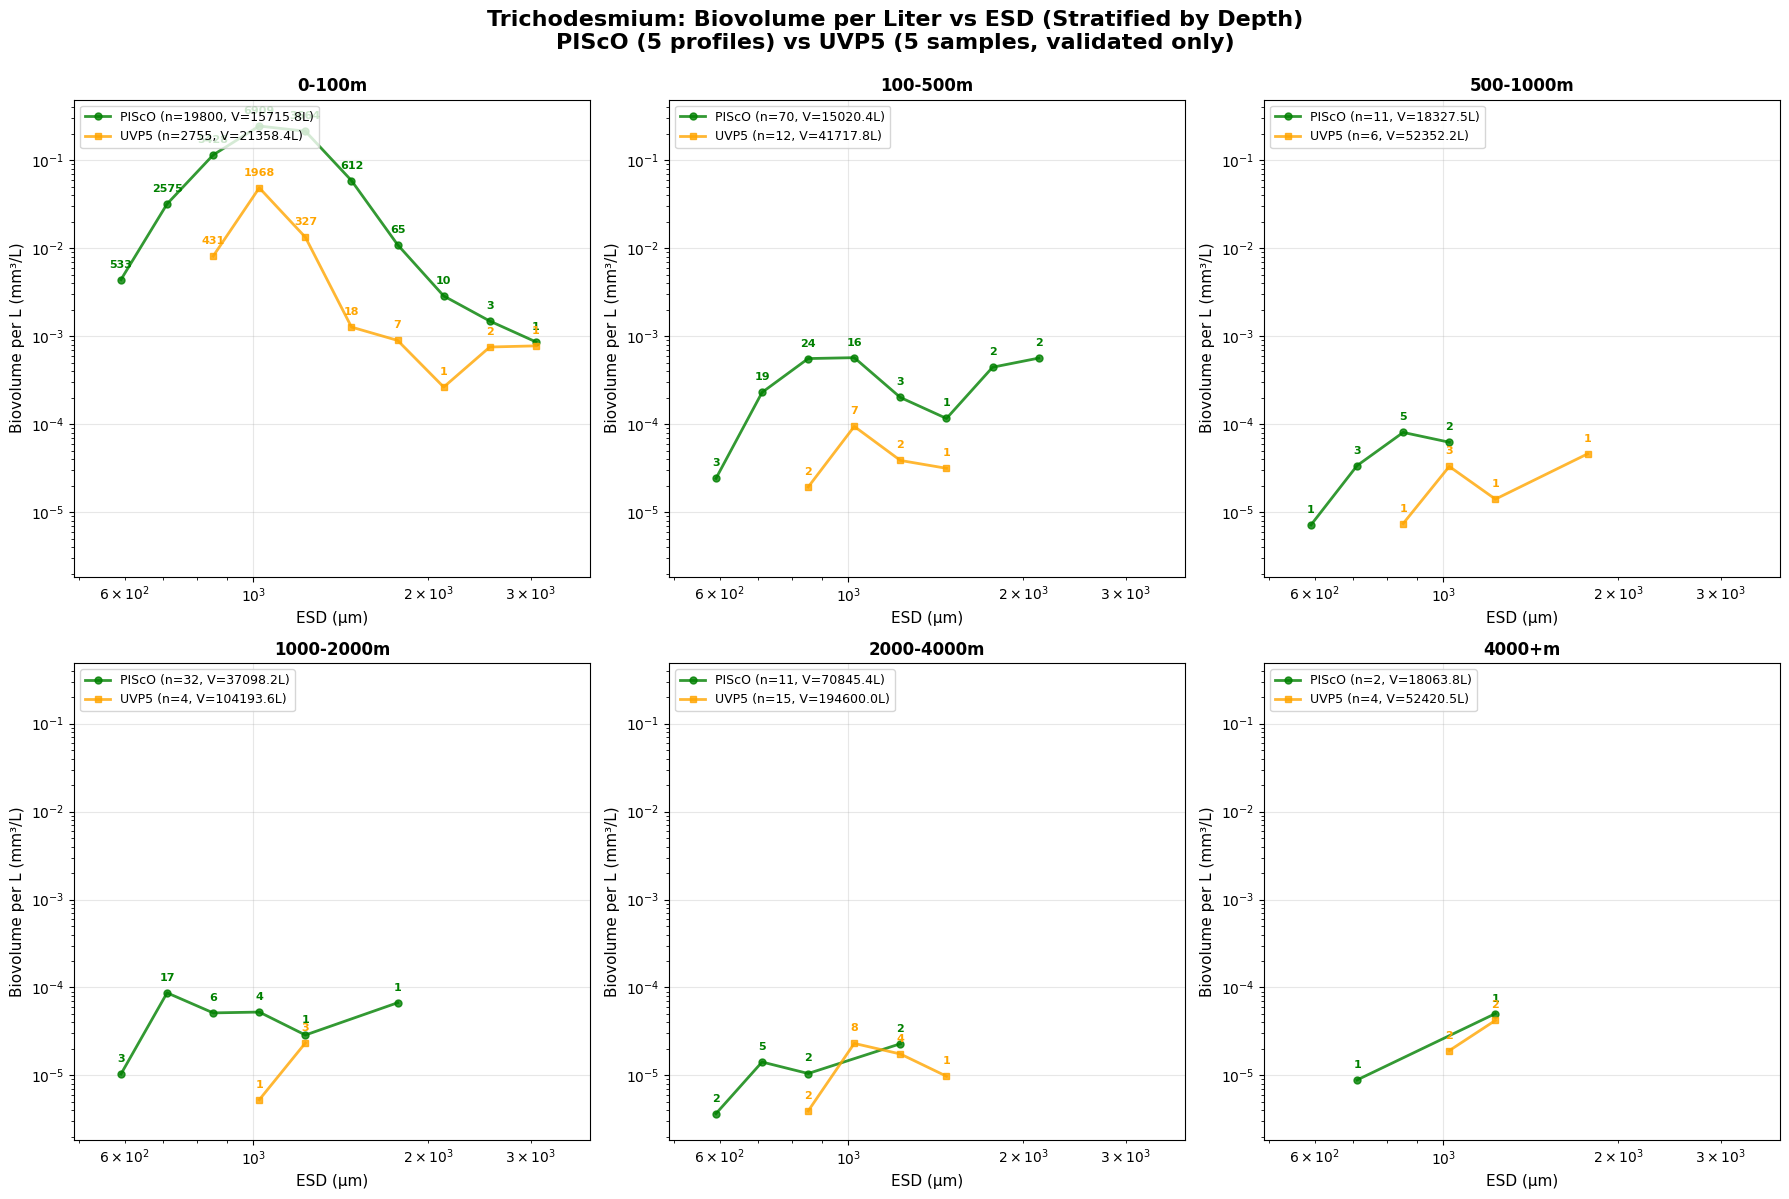


Trichodesmium depth-stratified comparison figure saved to: /home/veit/PIScO_dev/Segmentation_results/pisco_vs_uvp5_trichodesmium_biovolume_per_L_by_depth_multi_validated.png

TRICHODESMIUM BIOVOLUME PER LITER BY DEPTH BIN:

0-100m:
------------------------------------------------------------
  PIScO:
    Trichodesmium: 19800
    Total biovolume: 10745.80 mm³
    Biovolume per L: 0.6838 mm³/L
  UVP5 (validated):
    Trichodesmium: 2755
    Total biovolume: 1577.89 mm³
    Biovolume per L: 0.0739 mm³/L
  Ratio (PIScO/UVP5): 9.26x

100-500m:
------------------------------------------------------------
  PIScO:
    Trichodesmium: 70
    Total biovolume: 40.56 mm³
    Biovolume per L: 0.0027 mm³/L
  UVP5 (validated):
    Trichodesmium: 12
    Total biovolume: 7.65 mm³
    Biovolume per L: 0.0002 mm³/L
  Ratio (PIScO/UVP5): 14.72x

500-1000m:
------------------------------------------------------------
  PIScO:
    Trichodesmium: 11
    Total biovolume: 3.36 mm³
    Biovolume per L: 0.0002 

In [22]:


# ============ PROCESS TRICHODESMIUM FOR MULTIPLE PROFILES ============
print("\n" + "="*80)
print("PROCESSING TRICHODESMIUM - MULTIPLE PROFILES")
print("="*80)

all_tricho_pisco = []
# Reuse all_pisco_volumes from copepod analysis (same volumes apply)

for profile_config in pisco_profiles:
    tsv_path = profile_config['tsv_path']
    profile_name = profile_config['profile_name']
    
    print(f"\nProcessing Trichodesmium for PIScO profile: {profile_name}")
    
    # Read Trichodesmium data
    df_pisco = pd.read_csv(tsv_path, sep='\t')
    df_pisco['pressure_dbar'] = df_pisco['object_pressure']
    
    # ✅ COMBINE Trichodesmium, puff, and tuft categories
    tricho_pisco = df_pisco[
        df_pisco['object_annotation_category'].str.contains('Trichodesmium|puff|tuft', case=False, na=False, regex=True)
    ].copy()
    
    # Standardize category name
    tricho_pisco['object_annotation_category'] = 'Trichodesmium'
    
    print(f"  Found {len(tricho_pisco)} Trichodesmium/puff/tuft colonies")
    
    # Calculate biovolume
    tricho_pisco['esd_um'] = tricho_pisco['object_esd']
    esd_mm = tricho_pisco['esd_um'] / 1000
    tricho_pisco['biovolume_mm3'] = (np.pi / 6) * (esd_mm ** 3)
    
    # Assign depth bins
    tricho_pisco['depth_bin'] = pd.cut(tricho_pisco['pressure_dbar'], 
                                        bins=depth_bin_edges, 
                                        labels=depth_bin_labels,
                                        include_lowest=True,
                                        right=False)
    
    tricho_pisco['profile'] = profile_name
    all_tricho_pisco.append(tricho_pisco)

# Combine all PIScO Trichodesmium data
tricho_pisco = pd.concat(all_tricho_pisco, ignore_index=True)

print(f"\n✅ Combined PIScO Trichodesmium/puff/tuft: {len(tricho_pisco)} colonies from {len(pisco_profiles)} profiles")


# ============ PROCESS UVP5 TRICHODESMIUM (VALIDATED ONLY) ============
print("\n" + "="*80)
print("PROCESSING UVP5 TRICHODESMIUM (VALIDATED ONLY)")
print("="*80)

# Filter for validated Trichodesmium only
if 'object_annotation_status' in df_uvp5.columns:
    print("✅ Filtering for validated Trichodesmium/puff/tuft annotations only...")
    
    # ✅ COMBINE Trichodesmium, puff, and tuft categories
    tricho_uvp5 = df_uvp5[
        (df_uvp5['object_annotation_category'].str.contains('Trichodesmium|puff|tuft', case=False, na=False, regex=True)) &
        (df_uvp5['object_annotation_status'] == 'validated')
    ].copy()
    
    all_tricho = df_uvp5[df_uvp5['object_annotation_category'].str.contains('Trichodesmium|puff|tuft', case=False, na=False, regex=True)]
    
    # Standardize category name
    tricho_uvp5['object_annotation_category'] = 'Trichodesmium'
    all_tricho_standardized = all_tricho.copy()
    all_tricho_standardized['object_annotation_category'] = 'Trichodesmium'
    
    print(f"   Total UVP5 Trichodesmium/puff/tuft (all statuses): {len(all_tricho)}")
    print(f"   Total UVP5 validated Trichodesmium/puff/tuft: {len(tricho_uvp5)}")
    print(f"   Filtered out: {len(all_tricho) - len(tricho_uvp5)} ({100 * (len(all_tricho) - len(tricho_uvp5)) / max(len(all_tricho), 1):.1f}%)")
else:
    print("\n⚠️ WARNING: 'object_annotation_status' column not found! Using all Trichodesmium/puff/tuft.")
    tricho_uvp5 = df_uvp5[df_uvp5['object_annotation_category'].str.contains('Trichodesmium|puff|tuft', case=False, na=False, regex=True)].copy()
    tricho_uvp5['object_annotation_category'] = 'Trichodesmium'

print(f"✅ Combined UVP5 Trichodesmium/puff/tuft: {len(tricho_uvp5)} validated colonies from {len(uvp5_samples)} samples")

# Calculate biovolume
tricho_uvp5['esd_um'] = tricho_uvp5['object_esd'] * 88
esd_mm_uvp5 = tricho_uvp5['esd_um'] / 1000
tricho_uvp5['biovolume_mm3'] = (np.pi / 6) * (esd_mm_uvp5 ** 3)
tricho_uvp5['pressure_dbar'] = tricho_uvp5['object_depth_min']

# Assign depth bins
tricho_uvp5['depth_bin'] = pd.cut(tricho_uvp5['pressure_dbar'], 
                                   bins=depth_bin_edges, 
                                   labels=depth_bin_labels,
                                   include_lowest=True,
                                   right=False)


# ============ BIN TRICHODESMIUM BY ESD ============
tricho_pisco['esd_bin'] = pd.cut(tricho_pisco['esd_um'], bins=esd_bin_edges)
tricho_uvp5['esd_bin'] = pd.cut(tricho_uvp5['esd_um'], bins=esd_bin_edges)


# ============ DETERMINE GLOBAL AXIS LIMITS FOR TRICHODESMIUM ============
all_esd_pisco_tricho = []
all_esd_uvp5_tricho = []
all_biovol_pisco_tricho = []
all_biovol_uvp5_tricho = []

for depth_label in depth_bin_labels:
    pisco_depth = tricho_pisco[tricho_pisco['depth_bin'] == depth_label]
    uvp5_depth = tricho_uvp5[tricho_uvp5['depth_bin'] == depth_label]
    
    pisco_volume = pisco_depth_volumes.get(depth_label, 0)
    uvp5_volume = uvp5_depth_volumes.get(depth_label, 0)
    
    if len(pisco_depth) > 0 and pisco_volume > 0:
        pisco_binned = pisco_depth.groupby('esd_bin', observed=True).agg({
            'esd_um': 'mean',
            'biovolume_mm3': 'sum'
        }).dropna().reset_index(drop=True)
        pisco_binned['biovolume_mm3_per_L'] = pisco_binned['biovolume_mm3'] / pisco_volume
        
        all_esd_pisco_tricho.extend(pisco_binned['esd_um'].tolist())
        all_biovol_pisco_tricho.extend(pisco_binned['biovolume_mm3_per_L'].tolist())
    
    if len(uvp5_depth) > 0 and uvp5_volume > 0:
        uvp5_binned = uvp5_depth.groupby('esd_bin', observed=True).agg({
            'esd_um': 'mean',
            'biovolume_mm3': 'sum'
        }).dropna().reset_index(drop=True)
        uvp5_binned['biovolume_mm3_per_L'] = uvp5_binned['biovolume_mm3'] / uvp5_volume
        
        all_esd_uvp5_tricho.extend(uvp5_binned['esd_um'].tolist())
        all_biovol_uvp5_tricho.extend(uvp5_binned['biovolume_mm3_per_L'].tolist())

if all_esd_pisco_tricho or all_esd_uvp5_tricho:
    all_esd_tricho = all_esd_pisco_tricho + all_esd_uvp5_tricho
    esd_min_tricho = min(all_esd_tricho) * 0.8
    esd_max_tricho = max(all_esd_tricho) * 1.2
else:
    esd_min_tricho, esd_max_tricho = 50, 10000

if all_biovol_pisco_tricho or all_biovol_uvp5_tricho:
    all_biovol_tricho = all_biovol_pisco_tricho + all_biovol_uvp5_tricho
    biovol_min_tricho = min(all_biovol_tricho) * 0.5
    biovol_max_tricho = max(all_biovol_tricho) * 2
else:
    biovol_min_tricho, biovol_max_tricho = 1e-6, 1e-1

print(f"\n✅ Global axis limits for Trichodesmium:")
print(f"   ESD: {esd_min_tricho:.1f} - {esd_max_tricho:.1f} µm")
print(f"   Biovolume per L: {biovol_min_tricho:.6f} - {biovol_max_tricho:.6f} mm³/L")


# ============ PLOT TRICHODESMIUM ============
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, depth_label in enumerate(depth_bin_labels):
    ax = axes[idx]
    
    pisco_depth = tricho_pisco[tricho_pisco['depth_bin'] == depth_label].copy()
    uvp5_depth = tricho_uvp5[tricho_uvp5['depth_bin'] == depth_label].copy()
    
    pisco_volume = pisco_depth_volumes.get(depth_label, 0)
    uvp5_volume = uvp5_depth_volumes.get(depth_label, 0)
    
    if len(pisco_depth) > 0 and pisco_volume > 0:
        pisco_binned = pisco_depth.groupby('esd_bin', observed=True).agg({
            'esd_um': 'mean',
            'biovolume_mm3': 'sum',
            'depth_bin': 'size'
        }).rename(columns={'depth_bin': 'n_objects'}).dropna()
        
        pisco_binned['esd_bin_center'] = pisco_binned.index.map(lambda x: (x.left + x.right) / 2)
        pisco_binned = pisco_binned.reset_index(drop=True)
        pisco_binned['biovolume_mm3_per_L'] = pisco_binned['biovolume_mm3'] / pisco_volume

        ax.plot(pisco_binned['esd_bin_center'], pisco_binned['biovolume_mm3_per_L'],
                marker='o', linewidth=2, markersize=5,
                label=f'PIScO (n={len(pisco_depth)}, V={pisco_volume:.1f}L)',
                color='green', alpha=0.8)
        
        for _, row in pisco_binned.iterrows():
            ax.text(row['esd_bin_center'], row['biovolume_mm3_per_L'] * 1.3,
                   f"{int(row['n_objects'])}", 
                   ha='center', va='bottom', fontsize=8, 
                   color='green', fontweight='bold')
    
    if len(uvp5_depth) > 0 and uvp5_volume > 0:
        uvp5_binned = uvp5_depth.groupby('esd_bin', observed=True).agg({
            'esd_um': 'mean',
            'biovolume_mm3': 'sum',
            'depth_bin': 'size'
        }).rename(columns={'depth_bin': 'n_objects'}).dropna()
        
        uvp5_binned['esd_bin_center'] = uvp5_binned.index.map(lambda x: (x.left + x.right) / 2)
        uvp5_binned = uvp5_binned.reset_index(drop=True)
        uvp5_binned['biovolume_mm3_per_L'] = uvp5_binned['biovolume_mm3'] / uvp5_volume
        
        ax.plot(uvp5_binned['esd_bin_center'], uvp5_binned['biovolume_mm3_per_L'],
                marker='s', linewidth=2, markersize=5,
                label=f'UVP5 (n={len(uvp5_depth)}, V={uvp5_volume:.1f}L)',
                color='orange', alpha=0.8)
        
        for _, row in uvp5_binned.iterrows():
            ax.text(row['esd_bin_center'], row['biovolume_mm3_per_L'] * 1.3,
                   f"{int(row['n_objects'])}", 
                   ha='center', va='bottom', fontsize=8,
                   color='orange', fontweight='bold')
    
    ax.set_xlabel('ESD (µm)', fontsize=11)
    ax.set_ylabel('Biovolume per L (mm³/L)', fontsize=11)
    ax.set_title(f'{depth_label}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(esd_min_tricho, esd_max_tricho)
    ax.set_ylim(biovol_min_tricho, biovol_max_tricho)

plt.suptitle(f'Trichodesmium: Biovolume per Liter vs ESD (Stratified by Depth)\nPIScO ({len(pisco_profiles)} profiles) vs UVP5 ({len(uvp5_samples)} samples, validated only)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Save figure
fig_path = "/home/veit/PIScO_dev/Segmentation_results/pisco_vs_uvp5_trichodesmium_biovolume_per_L_by_depth_multi_validated.png"
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\nTrichodesmium depth-stratified comparison figure saved to: {fig_path}")


# ============ PRINT TRICHODESMIUM STATISTICS BY DEPTH BIN ============
print("\n" + "="*80)
print("TRICHODESMIUM BIOVOLUME PER LITER BY DEPTH BIN:")
print("="*80)

for depth_label in depth_bin_labels:
    print(f"\n{depth_label}:")
    print("-" * 60)
    
    pisco_depth = tricho_pisco[tricho_pisco['depth_bin'] == depth_label]
    uvp5_depth = tricho_uvp5[tricho_uvp5['depth_bin'] == depth_label]
    
    pisco_volume = pisco_depth_volumes.get(depth_label, 0)
    uvp5_volume = uvp5_depth_volumes.get(depth_label, 0)
    
    if len(pisco_depth) > 0 and pisco_volume > 0:
        pisco_total_biovol = pisco_depth['biovolume_mm3'].sum()
        print(f"  PIScO:")
        print(f"    Trichodesmium: {len(pisco_depth)}")
        print(f"    Total biovolume: {pisco_total_biovol:.2f} mm³")
        print(f"    Biovolume per L: {pisco_total_biovol / pisco_volume:.4f} mm³/L")
    else:
        print(f"  PIScO: No data")
    
    if len(uvp5_depth) > 0 and uvp5_volume > 0:
        uvp5_total_biovol = uvp5_depth['biovolume_mm3'].sum()
        print(f"  UVP5 (validated):")
        print(f"    Trichodesmium: {len(uvp5_depth)}")
        print(f"    Total biovolume: {uvp5_total_biovol:.2f} mm³")
        print(f"    Biovolume per L: {uvp5_total_biovol / uvp5_volume:.4f} mm³/L")
    else:
        print(f"  UVP5 (validated): No data")
    
    if len(pisco_depth) > 0 and len(uvp5_depth) > 0 and pisco_volume > 0 and uvp5_volume > 0:
        ratio = (pisco_depth['biovolume_mm3'].sum() / pisco_volume) / (uvp5_depth['biovolume_mm3'].sum() / uvp5_volume)
        print(f"  Ratio (PIScO/UVP5): {ratio:.2f}x")

print("\n" + "="*80)
print("OVERALL TRICHODESMIUM SUMMARY:")
print("="*80)
print(f"\nPIScO: {len(tricho_pisco)} colonies from {len(pisco_profiles)} profiles")
print(f"UVP5 (validated): {len(tricho_uvp5)} colonies from {len(uvp5_samples)} samples")




PROCESSING APPENDICULARIA - MULTIPLE PROFILES

Processing Appendicularia for PIScO profile: M181-175-1_CTD-050_00°00S-019°00W_20220509-0543
  Found 183 Appendicularia

Processing Appendicularia for PIScO profile: M181-112-1_CTD-037_00°00S-008°00W_20220504-1758
  Found 1375 Appendicularia

Processing Appendicularia for PIScO profile: M181-227-1_CTD-060_00°00S-027°00W_20220512-1748
  Found 160 Appendicularia

Processing Appendicularia for PIScO profile: M181-285-1_CTD-075_00°00S-039°00W_20220517-2024
  Found 845 Appendicularia

Processing Appendicularia for PIScO profile: M181-297-1_CTD-081_00°00S-041°50W_20220519-0218
  Found 996 Appendicularia

✅ Combined PIScO Appendicularia: 3559 individuals from 5 profiles

PROCESSING UVP5 APPENDICULARIA (VALIDATED ONLY)
✅ Filtering for validated Appendicularia annotations only...
   Total UVP5 Appendicularia (all statuses): 4
   Total UVP5 validated Appendicularia: 2
   Filtered out: 2 (50.0%)
✅ Combined UVP5 Appendicularia: 2 validated individual

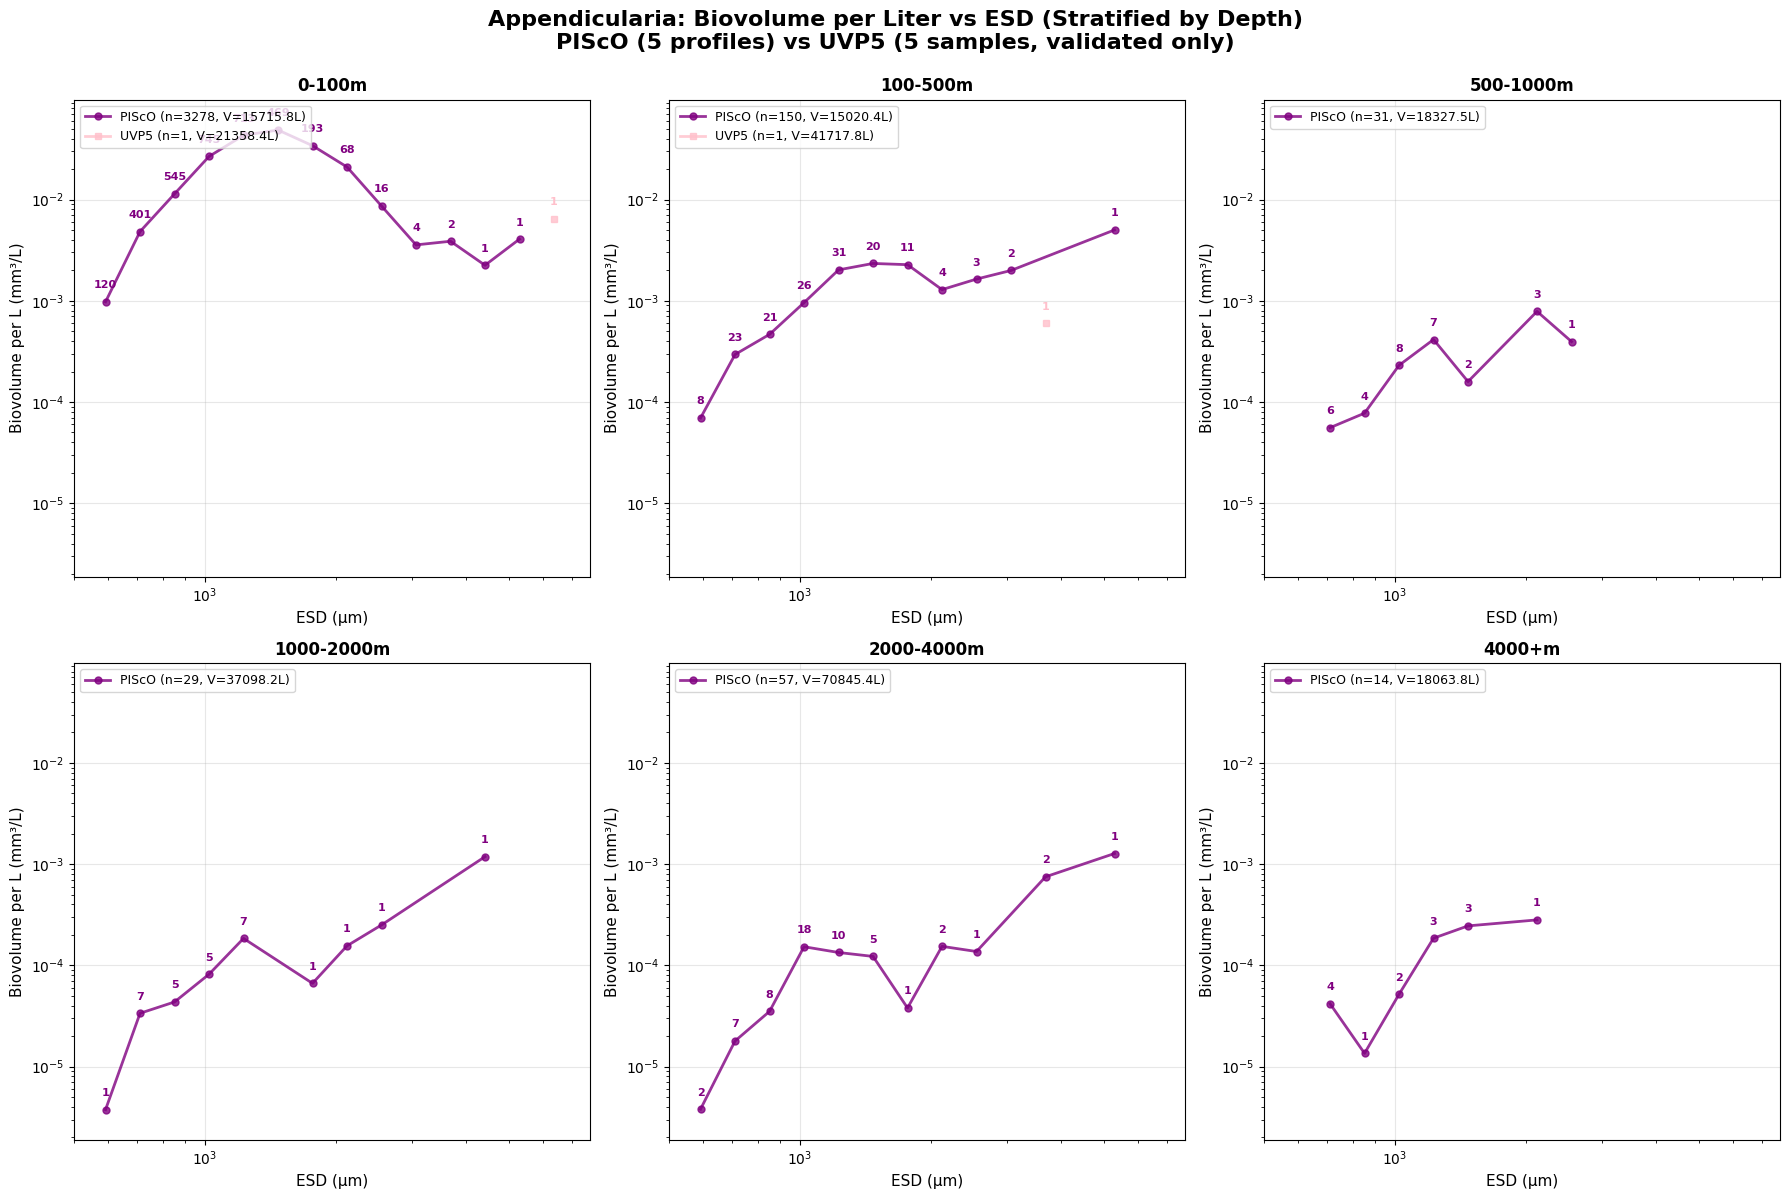


Appendicularia depth-stratified comparison figure saved to: /home/veit/PIScO_dev/Segmentation_results/pisco_vs_uvp5_appendicularia_biovolume_per_L_by_depth_multi_validated.png

APPENDICULARIA BIOVOLUME PER LITER BY DEPTH BIN:

0-100m:
------------------------------------------------------------
  PIScO:
    Appendicularia: 3278
    Total biovolume: 3346.91 mm³
    Biovolume per L: 0.2130 mm³/L
  UVP5 (validated):
    Appendicularia: 1
    Total biovolume: 138.09 mm³
    Biovolume per L: 0.0065 mm³/L
  Ratio (PIScO/UVP5): 32.94x

100-500m:
------------------------------------------------------------
  PIScO:
    Appendicularia: 150
    Total biovolume: 275.53 mm³
    Biovolume per L: 0.0183 mm³/L
  UVP5 (validated):
    Appendicularia: 1
    Total biovolume: 25.06 mm³
    Biovolume per L: 0.0006 mm³/L
  Ratio (PIScO/UVP5): 30.53x

500-1000m:
------------------------------------------------------------
  PIScO:
    Appendicularia: 31
    Total biovolume: 38.80 mm³
    Biovolume per L: 0

In [23]:


# ============ PROCESS APPENDICULARIA FOR MULTIPLE PROFILES ============
print("\n" + "="*80)
print("PROCESSING APPENDICULARIA - MULTIPLE PROFILES")
print("="*80)

all_appendi_pisco = []
# Reuse all_pisco_volumes from copepod analysis (same volumes apply)

for profile_config in pisco_profiles:
    tsv_path = profile_config['tsv_path']
    profile_name = profile_config['profile_name']
    
    print(f"\nProcessing Appendicularia for PIScO profile: {profile_name}")
    
    # Read Appendicularia data
    df_pisco = pd.read_csv(tsv_path, sep='\t')
    df_pisco['pressure_dbar'] = df_pisco['object_pressure']
    
    # Filter for Appendicularia
    appendi_pisco = df_pisco[
        df_pisco['object_annotation_category'].str.contains('Appendicularia', case=False, na=False)
    ].copy()
    
    print(f"  Found {len(appendi_pisco)} Appendicularia")
    
    # Calculate biovolume
    appendi_pisco['esd_um'] = appendi_pisco['object_esd']
    esd_mm = appendi_pisco['esd_um'] / 1000
    appendi_pisco['biovolume_mm3'] = (np.pi / 6) * (esd_mm ** 3)
    
    # Assign depth bins
    appendi_pisco['depth_bin'] = pd.cut(appendi_pisco['pressure_dbar'], 
                                         bins=depth_bin_edges, 
                                         labels=depth_bin_labels,
                                         include_lowest=True,
                                         right=False)
    
    appendi_pisco['profile'] = profile_name
    all_appendi_pisco.append(appendi_pisco)

# Combine all PIScO Appendicularia data
appendi_pisco = pd.concat(all_appendi_pisco, ignore_index=True)

print(f"\n✅ Combined PIScO Appendicularia: {len(appendi_pisco)} individuals from {len(pisco_profiles)} profiles")


# ============ PROCESS UVP5 APPENDICULARIA (VALIDATED ONLY) ============
print("\n" + "="*80)
print("PROCESSING UVP5 APPENDICULARIA (VALIDATED ONLY)")
print("="*80)

# Filter for validated Appendicularia only
if 'object_annotation_status' in df_uvp5.columns:
    print("✅ Filtering for validated Appendicularia annotations only...")
    
    appendi_uvp5 = df_uvp5[
        (df_uvp5['object_annotation_category'].str.contains('Appendicularia', case=False, na=False)) &
        (df_uvp5['object_annotation_status'] == 'validated')
    ].copy()
    
    all_appendi = df_uvp5[df_uvp5['object_annotation_category'].str.contains('Appendicularia', case=False, na=False)]
    
    print(f"   Total UVP5 Appendicularia (all statuses): {len(all_appendi)}")
    print(f"   Total UVP5 validated Appendicularia: {len(appendi_uvp5)}")
    print(f"   Filtered out: {len(all_appendi) - len(appendi_uvp5)} ({100 * (len(all_appendi) - len(appendi_uvp5)) / max(len(all_appendi), 1):.1f}%)")
else:
    print("\n⚠️ WARNING: 'object_annotation_status' column not found! Using all Appendicularia.")
    appendi_uvp5 = df_uvp5[df_uvp5['object_annotation_category'].str.contains('Appendicularia', case=False, na=False)].copy()

print(f"✅ Combined UVP5 Appendicularia: {len(appendi_uvp5)} validated individuals from {len(uvp5_samples)} samples")

# Calculate biovolume
appendi_uvp5['esd_um'] = appendi_uvp5['object_esd'] * 88
esd_mm_uvp5 = appendi_uvp5['esd_um'] / 1000
appendi_uvp5['biovolume_mm3'] = (np.pi / 6) * (esd_mm_uvp5 ** 3)
appendi_uvp5['pressure_dbar'] = appendi_uvp5['object_depth_min']

# Assign depth bins
appendi_uvp5['depth_bin'] = pd.cut(appendi_uvp5['pressure_dbar'], 
                                    bins=depth_bin_edges, 
                                    labels=depth_bin_labels,
                                    include_lowest=True,
                                    right=False)


# ============ BIN APPENDICULARIA BY ESD ============
appendi_pisco['esd_bin'] = pd.cut(appendi_pisco['esd_um'], bins=esd_bin_edges)
appendi_uvp5['esd_bin'] = pd.cut(appendi_uvp5['esd_um'], bins=esd_bin_edges)


# ============ DETERMINE GLOBAL AXIS LIMITS FOR APPENDICULARIA ============
all_esd_pisco_appendi = []
all_esd_uvp5_appendi = []
all_biovol_pisco_appendi = []
all_biovol_uvp5_appendi = []

for depth_label in depth_bin_labels:
    pisco_depth = appendi_pisco[appendi_pisco['depth_bin'] == depth_label]
    uvp5_depth = appendi_uvp5[appendi_uvp5['depth_bin'] == depth_label]
    
    pisco_volume = pisco_depth_volumes.get(depth_label, 0)
    uvp5_volume = uvp5_depth_volumes.get(depth_label, 0)
    
    if len(pisco_depth) > 0 and pisco_volume > 0:
        pisco_binned = pisco_depth.groupby('esd_bin', observed=True).agg({
            'esd_um': 'mean',
            'biovolume_mm3': 'sum'
        }).dropna().reset_index(drop=True)
        pisco_binned['biovolume_mm3_per_L'] = pisco_binned['biovolume_mm3'] / pisco_volume
        
        all_esd_pisco_appendi.extend(pisco_binned['esd_um'].tolist())
        all_biovol_pisco_appendi.extend(pisco_binned['biovolume_mm3_per_L'].tolist())
    
    if len(uvp5_depth) > 0 and uvp5_volume > 0:
        uvp5_binned = uvp5_depth.groupby('esd_bin', observed=True).agg({
            'esd_um': 'mean',
            'biovolume_mm3': 'sum'
        }).dropna().reset_index(drop=True)
        uvp5_binned['biovolume_mm3_per_L'] = uvp5_binned['biovolume_mm3'] / uvp5_volume
        
        all_esd_uvp5_appendi.extend(uvp5_binned['esd_um'].tolist())
        all_biovol_uvp5_appendi.extend(uvp5_binned['biovolume_mm3_per_L'].tolist())

if all_esd_pisco_appendi or all_esd_uvp5_appendi:
    all_esd_appendi = all_esd_pisco_appendi + all_esd_uvp5_appendi
    esd_min_appendi = min(all_esd_appendi) * 0.8
    esd_max_appendi = max(all_esd_appendi) * 1.2
else:
    esd_min_appendi, esd_max_appendi = 50, 10000

if all_biovol_pisco_appendi or all_biovol_uvp5_appendi:
    all_biovol_appendi = all_biovol_pisco_appendi + all_biovol_uvp5_appendi
    biovol_min_appendi = min(all_biovol_appendi) * 0.5
    biovol_max_appendi = max(all_biovol_appendi) * 2
else:
    biovol_min_appendi, biovol_max_appendi = 1e-6, 1e-1

print(f"\n✅ Global axis limits for Appendicularia:")
print(f"   ESD: {esd_min_appendi:.1f} - {esd_max_appendi:.1f} µm")
print(f"   Biovolume per L: {biovol_min_appendi:.6f} - {biovol_max_appendi:.6f} mm³/L")


# ============ PLOT APPENDICULARIA ============
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, depth_label in enumerate(depth_bin_labels):
    ax = axes[idx]
    
    pisco_depth = appendi_pisco[appendi_pisco['depth_bin'] == depth_label].copy()
    uvp5_depth = appendi_uvp5[appendi_uvp5['depth_bin'] == depth_label].copy()
    
    pisco_volume = pisco_depth_volumes.get(depth_label, 0)
    uvp5_volume = uvp5_depth_volumes.get(depth_label, 0)
    
    if len(pisco_depth) > 0 and pisco_volume > 0:
        pisco_binned = pisco_depth.groupby('esd_bin', observed=True).agg({
            'esd_um': 'mean',
            'biovolume_mm3': 'sum',
            'depth_bin': 'size'
        }).rename(columns={'depth_bin': 'n_objects'}).dropna()
        
        pisco_binned['esd_bin_center'] = pisco_binned.index.map(lambda x: (x.left + x.right) / 2)
        pisco_binned = pisco_binned.reset_index(drop=True)
        pisco_binned['biovolume_mm3_per_L'] = pisco_binned['biovolume_mm3'] / pisco_volume

        ax.plot(pisco_binned['esd_bin_center'], pisco_binned['biovolume_mm3_per_L'],
                marker='o', linewidth=2, markersize=5,
                label=f'PIScO (n={len(pisco_depth)}, V={pisco_volume:.1f}L)',
                color='purple', alpha=0.8)
        
        for _, row in pisco_binned.iterrows():
            ax.text(row['esd_bin_center'], row['biovolume_mm3_per_L'] * 1.3,
                   f"{int(row['n_objects'])}", 
                   ha='center', va='bottom', fontsize=8, 
                   color='purple', fontweight='bold')
    
    if len(uvp5_depth) > 0 and uvp5_volume > 0:
        uvp5_binned = uvp5_depth.groupby('esd_bin', observed=True).agg({
            'esd_um': 'mean',
            'biovolume_mm3': 'sum',
            'depth_bin': 'size'
        }).rename(columns={'depth_bin': 'n_objects'}).dropna()
        
        uvp5_binned['esd_bin_center'] = uvp5_binned.index.map(lambda x: (x.left + x.right) / 2)
        uvp5_binned = uvp5_binned.reset_index(drop=True)
        uvp5_binned['biovolume_mm3_per_L'] = uvp5_binned['biovolume_mm3'] / uvp5_volume
        
        ax.plot(uvp5_binned['esd_bin_center'], uvp5_binned['biovolume_mm3_per_L'],
                marker='s', linewidth=2, markersize=5,
                label=f'UVP5 (n={len(uvp5_depth)}, V={uvp5_volume:.1f}L)',
                color='pink', alpha=0.8)
        
        for _, row in uvp5_binned.iterrows():
            ax.text(row['esd_bin_center'], row['biovolume_mm3_per_L'] * 1.3,
                   f"{int(row['n_objects'])}", 
                   ha='center', va='bottom', fontsize=8,
                   color='pink', fontweight='bold')
    
    ax.set_xlabel('ESD (µm)', fontsize=11)
    ax.set_ylabel('Biovolume per L (mm³/L)', fontsize=11)
    ax.set_title(f'{depth_label}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(esd_min_appendi, esd_max_appendi)
    ax.set_ylim(biovol_min_appendi, biovol_max_appendi)

plt.suptitle(f'Appendicularia: Biovolume per Liter vs ESD (Stratified by Depth)\nPIScO ({len(pisco_profiles)} profiles) vs UVP5 ({len(uvp5_samples)} samples, validated only)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Save figure
fig_path = "/home/veit/PIScO_dev/Segmentation_results/pisco_vs_uvp5_appendicularia_biovolume_per_L_by_depth_multi_validated.png"
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\nAppendicularia depth-stratified comparison figure saved to: {fig_path}")


# ============ PRINT APPENDICULARIA STATISTICS BY DEPTH BIN ============
print("\n" + "="*80)
print("APPENDICULARIA BIOVOLUME PER LITER BY DEPTH BIN:")
print("="*80)

for depth_label in depth_bin_labels:
    print(f"\n{depth_label}:")
    print("-" * 60)
    
    pisco_depth = appendi_pisco[appendi_pisco['depth_bin'] == depth_label]
    uvp5_depth = appendi_uvp5[appendi_uvp5['depth_bin'] == depth_label]
    
    pisco_volume = pisco_depth_volumes.get(depth_label, 0)
    uvp5_volume = uvp5_depth_volumes.get(depth_label, 0)
    
    if len(pisco_depth) > 0 and pisco_volume > 0:
        pisco_total_biovol = pisco_depth['biovolume_mm3'].sum()
        print(f"  PIScO:")
        print(f"    Appendicularia: {len(pisco_depth)}")
        print(f"    Total biovolume: {pisco_total_biovol:.2f} mm³")
        print(f"    Biovolume per L: {pisco_total_biovol / pisco_volume:.4f} mm³/L")
    else:
        print(f"  PIScO: No data")
    
    if len(uvp5_depth) > 0 and uvp5_volume > 0:
        uvp5_total_biovol = uvp5_depth['biovolume_mm3'].sum()
        print(f"  UVP5 (validated):")
        print(f"    Appendicularia: {len(uvp5_depth)}")
        print(f"    Total biovolume: {uvp5_total_biovol:.2f} mm³")
        print(f"    Biovolume per L: {uvp5_total_biovol / uvp5_volume:.4f} mm³/L")
    else:
        print(f"  UVP5 (validated): No data")
    
    if len(pisco_depth) > 0 and len(uvp5_depth) > 0 and pisco_volume > 0 and uvp5_volume > 0:
        ratio = (pisco_depth['biovolume_mm3'].sum() / pisco_volume) / (uvp5_depth['biovolume_mm3'].sum() / uvp5_volume)
        print(f"  Ratio (PIScO/UVP5): {ratio:.2f}x")

print("\n" + "="*80)
print("OVERALL APPENDICULARIA SUMMARY:")
print("="*80)
print(f"\nPIScO: {len(appendi_pisco)} individuals from {len(pisco_profiles)} profiles")
print(f"UVP5 (validated): {len(appendi_uvp5)} individuals from {len(uvp5_samples)} samples")


PROCESSING CNIDARIA - MULTIPLE PROFILES

Processing Cnidaria for PIScO profile: M181-175-1_CTD-050_00°00S-019°00W_20220509-0543
  Found 135 Cnidaria

Processing Cnidaria for PIScO profile: M181-112-1_CTD-037_00°00S-008°00W_20220504-1758
  Found 100 Cnidaria

Processing Cnidaria for PIScO profile: M181-227-1_CTD-060_00°00S-027°00W_20220512-1748
  Found 63 Cnidaria

Processing Cnidaria for PIScO profile: M181-285-1_CTD-075_00°00S-039°00W_20220517-2024
  Found 47 Cnidaria

Processing Cnidaria for PIScO profile: M181-297-1_CTD-081_00°00S-041°50W_20220519-0218
  Found 125 Cnidaria

✅ Combined PIScO Cnidaria: 470 individuals from 5 profiles

PROCESSING UVP5 CNIDARIA (VALIDATED ONLY)
✅ Filtering for validated Cnidaria annotations only...
   Total UVP5 Cnidaria (all statuses): 13
   Total UVP5 validated Cnidaria: 9
   Filtered out: 4 (30.8%)
✅ Combined UVP5 Cnidaria: 9 validated individuals from 5 samples

✅ Global axis limits for Cnidaria:
   ESD: 595.0 - 11071.0 µm
   Biovolume per L: 0.000

/tmp/ipykernel_699094/535169409.py:203: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9, loc='upper left')


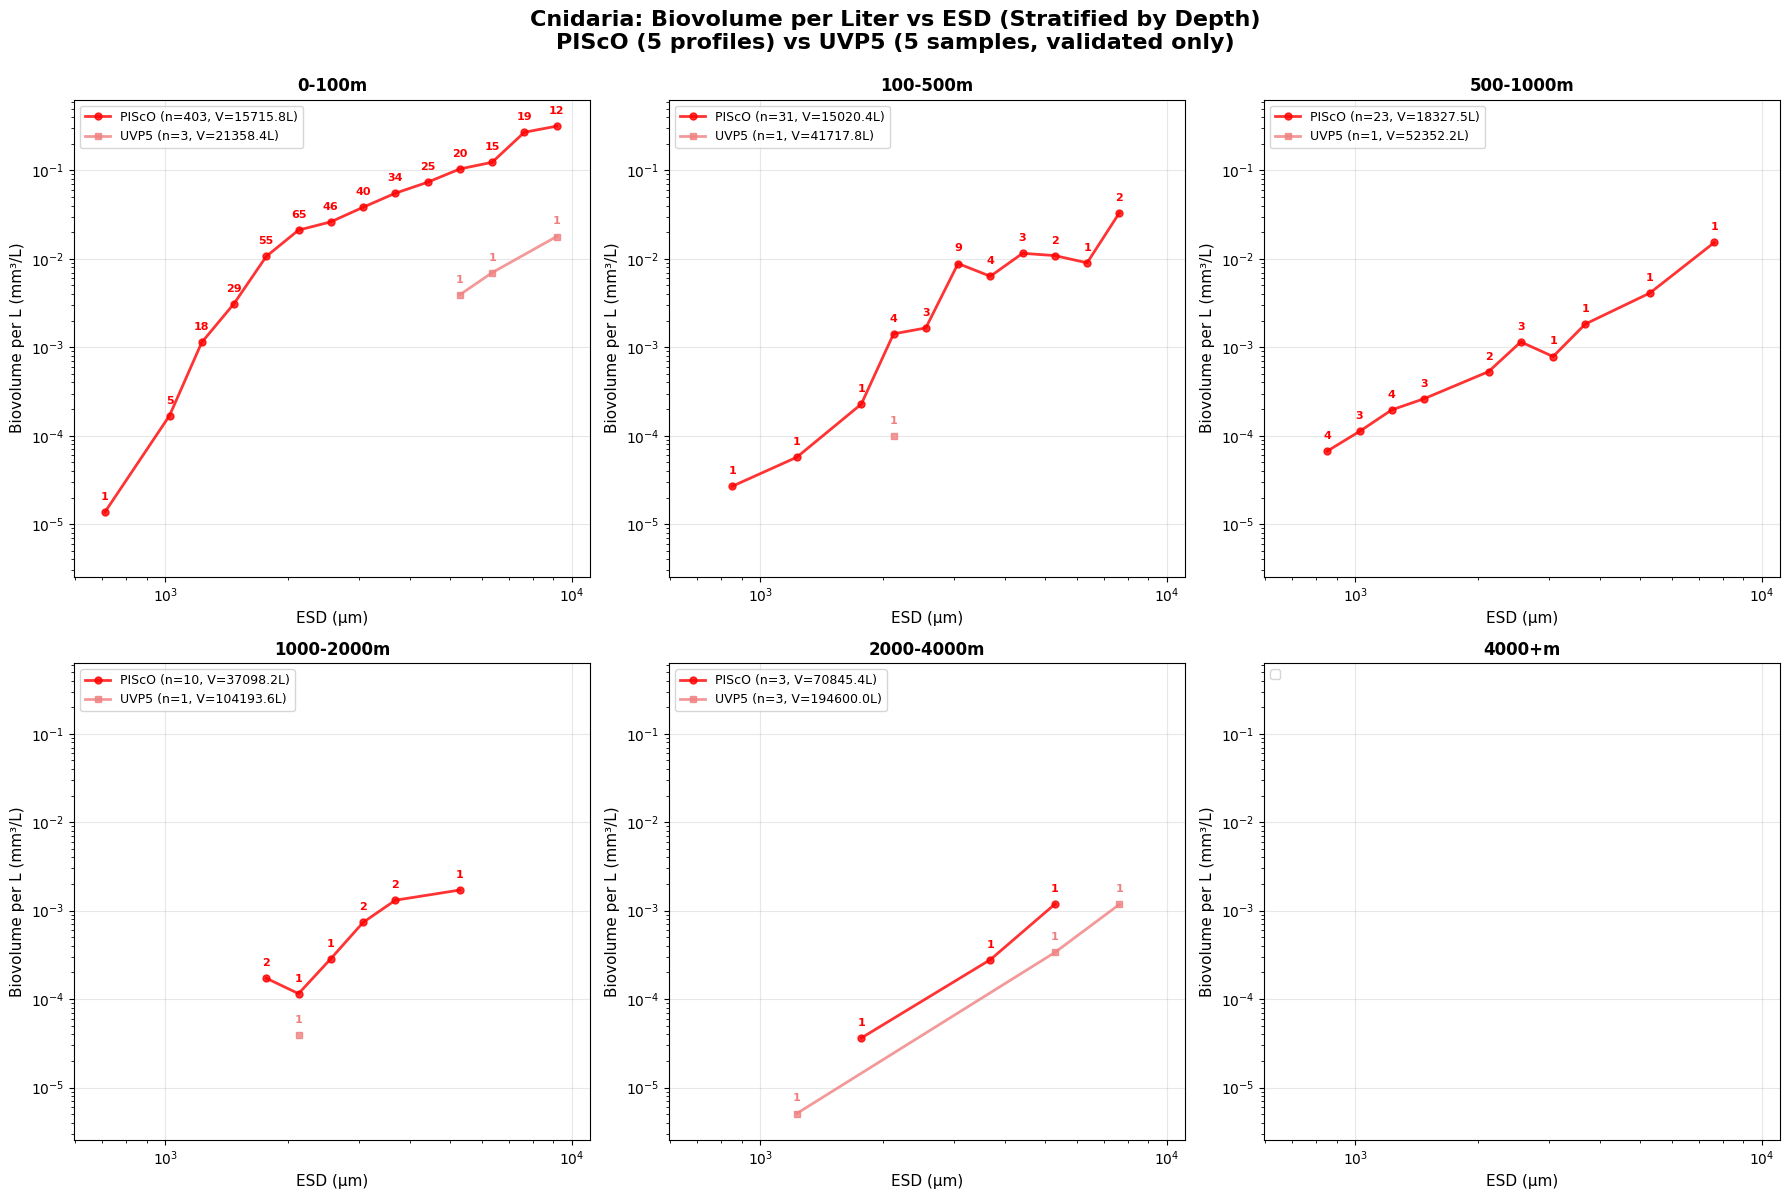


Cnidaria depth-stratified comparison figure saved to: /home/veit/PIScO_dev/Segmentation_results/pisco_vs_uvp5_cnidaria_biovolume_per_L_by_depth_multi_validated.png

CNIDARIA BIOVOLUME PER LITER BY DEPTH BIN:

0-100m:
------------------------------------------------------------
  PIScO:
    Cnidaria: 403
    Total biovolume: 43920.63 mm³
    Biovolume per L: 2.7947 mm³/L
  UVP5 (validated):
    Cnidaria: 3
    Total biovolume: 615.08 mm³
    Biovolume per L: 0.0288 mm³/L
  Ratio (PIScO/UVP5): 97.04x

100-500m:
------------------------------------------------------------
  PIScO:
    Cnidaria: 31
    Total biovolume: 1249.50 mm³
    Biovolume per L: 0.0832 mm³/L
  UVP5 (validated):
    Cnidaria: 1
    Total biovolume: 4.15 mm³
    Biovolume per L: 0.0001 mm³/L
  Ratio (PIScO/UVP5): 836.77x

500-1000m:
------------------------------------------------------------
  PIScO:
    Cnidaria: 23
    Total biovolume: 446.67 mm³
    Biovolume per L: 0.0244 mm³/L
  UVP5 (validated):
    Cnidaria: 1

In [24]:


# ============ PROCESS CNIDARIA FOR MULTIPLE PROFILES ============
print("\n" + "="*80)
print("PROCESSING CNIDARIA - MULTIPLE PROFILES")
print("="*80)

all_cnidaria_pisco = []
# Reuse all_pisco_volumes from copepod analysis (same volumes apply)

for profile_config in pisco_profiles:
    tsv_path = profile_config['tsv_path']
    profile_name = profile_config['profile_name']
    
    print(f"\nProcessing Cnidaria for PIScO profile: {profile_name}")
    
    # Read Cnidaria data
    df_pisco = pd.read_csv(tsv_path, sep='\t')
    df_pisco['pressure_dbar'] = df_pisco['object_pressure']
    
    # Filter for Cnidaria
    cnidaria_pisco = df_pisco[
        df_pisco['object_annotation_category'].str.contains('Cnidaria', case=False, na=False)
    ].copy()
    
    print(f"  Found {len(cnidaria_pisco)} Cnidaria")
    
    # Calculate biovolume
    cnidaria_pisco['esd_um'] = cnidaria_pisco['object_esd']
    esd_mm = cnidaria_pisco['esd_um'] / 1000
    cnidaria_pisco['biovolume_mm3'] = (np.pi / 6) * (esd_mm ** 3)
    
    # Assign depth bins
    cnidaria_pisco['depth_bin'] = pd.cut(cnidaria_pisco['pressure_dbar'], 
                                          bins=depth_bin_edges, 
                                          labels=depth_bin_labels,
                                          include_lowest=True,
                                          right=False)
    
    cnidaria_pisco['profile'] = profile_name
    all_cnidaria_pisco.append(cnidaria_pisco)

# Combine all PIScO Cnidaria data
cnidaria_pisco = pd.concat(all_cnidaria_pisco, ignore_index=True)

print(f"\n✅ Combined PIScO Cnidaria: {len(cnidaria_pisco)} individuals from {len(pisco_profiles)} profiles")


# ============ PROCESS UVP5 CNIDARIA (VALIDATED ONLY) ============
print("\n" + "="*80)
print("PROCESSING UVP5 CNIDARIA (VALIDATED ONLY)")
print("="*80)

# Filter for validated Cnidaria only
if 'object_annotation_status' in df_uvp5.columns:
    print("✅ Filtering for validated Cnidaria annotations only...")
    
    cnidaria_uvp5 = df_uvp5[
        (df_uvp5['object_annotation_category'].str.contains('Cnidaria', case=False, na=False)) &
        (df_uvp5['object_annotation_status'] == 'validated')
    ].copy()
    
    all_cnidaria = df_uvp5[df_uvp5['object_annotation_category'].str.contains('Cnidaria', case=False, na=False)]
    
    print(f"   Total UVP5 Cnidaria (all statuses): {len(all_cnidaria)}")
    print(f"   Total UVP5 validated Cnidaria: {len(cnidaria_uvp5)}")
    print(f"   Filtered out: {len(all_cnidaria) - len(cnidaria_uvp5)} ({100 * (len(all_cnidaria) - len(cnidaria_uvp5)) / max(len(all_cnidaria), 1):.1f}%)")
else:
    print("\n⚠️ WARNING: 'object_annotation_status' column not found! Using all Cnidaria.")
    cnidaria_uvp5 = df_uvp5[df_uvp5['object_annotation_category'].str.contains('Cnidaria', case=False, na=False)].copy()

print(f"✅ Combined UVP5 Cnidaria: {len(cnidaria_uvp5)} validated individuals from {len(uvp5_samples)} samples")

# Calculate biovolume
cnidaria_uvp5['esd_um'] = cnidaria_uvp5['object_esd'] * 88
esd_mm_uvp5 = cnidaria_uvp5['esd_um'] / 1000
cnidaria_uvp5['biovolume_mm3'] = (np.pi / 6) * (esd_mm_uvp5 ** 3)
cnidaria_uvp5['pressure_dbar'] = cnidaria_uvp5['object_depth_min']

# Assign depth bins
cnidaria_uvp5['depth_bin'] = pd.cut(cnidaria_uvp5['pressure_dbar'], 
                                     bins=depth_bin_edges, 
                                     labels=depth_bin_labels,
                                     include_lowest=True,
                                     right=False)


# ============ BIN CNIDARIA BY ESD ============
cnidaria_pisco['esd_bin'] = pd.cut(cnidaria_pisco['esd_um'], bins=esd_bin_edges)
cnidaria_uvp5['esd_bin'] = pd.cut(cnidaria_uvp5['esd_um'], bins=esd_bin_edges)


# ============ DETERMINE GLOBAL AXIS LIMITS FOR CNIDARIA ============
all_esd_pisco_cnidaria = []
all_esd_uvp5_cnidaria = []
all_biovol_pisco_cnidaria = []
all_biovol_uvp5_cnidaria = []

for depth_label in depth_bin_labels:
    pisco_depth = cnidaria_pisco[cnidaria_pisco['depth_bin'] == depth_label]
    uvp5_depth = cnidaria_uvp5[cnidaria_uvp5['depth_bin'] == depth_label]
    
    pisco_volume = pisco_depth_volumes.get(depth_label, 0)
    uvp5_volume = uvp5_depth_volumes.get(depth_label, 0)
    
    if len(pisco_depth) > 0 and pisco_volume > 0:
        pisco_binned = pisco_depth.groupby('esd_bin', observed=True).agg({
            'esd_um': 'mean',
            'biovolume_mm3': 'sum'
        }).dropna().reset_index(drop=True)
        pisco_binned['biovolume_mm3_per_L'] = pisco_binned['biovolume_mm3'] / pisco_volume
        
        all_esd_pisco_cnidaria.extend(pisco_binned['esd_um'].tolist())
        all_biovol_pisco_cnidaria.extend(pisco_binned['biovolume_mm3_per_L'].tolist())
    
    if len(uvp5_depth) > 0 and uvp5_volume > 0:
        uvp5_binned = uvp5_depth.groupby('esd_bin', observed=True).agg({
            'esd_um': 'mean',
            'biovolume_mm3': 'sum'
        }).dropna().reset_index(drop=True)
        uvp5_binned['biovolume_mm3_per_L'] = uvp5_binned['biovolume_mm3'] / uvp5_volume
        
        all_esd_uvp5_cnidaria.extend(uvp5_binned['esd_um'].tolist())
        all_biovol_uvp5_cnidaria.extend(uvp5_binned['biovolume_mm3_per_L'].tolist())

if all_esd_pisco_cnidaria or all_esd_uvp5_cnidaria:
    all_esd_cnidaria = all_esd_pisco_cnidaria + all_esd_uvp5_cnidaria
    esd_min_cnidaria = min(all_esd_cnidaria) * 0.8
    esd_max_cnidaria = max(all_esd_cnidaria) * 1.2
else:
    esd_min_cnidaria, esd_max_cnidaria = 50, 10000

if all_biovol_pisco_cnidaria or all_biovol_uvp5_cnidaria:
    all_biovol_cnidaria = all_biovol_pisco_cnidaria + all_biovol_uvp5_cnidaria
    biovol_min_cnidaria = min(all_biovol_cnidaria) * 0.5
    biovol_max_cnidaria = max(all_biovol_cnidaria) * 2
else:
    biovol_min_cnidaria, biovol_max_cnidaria = 1e-6, 1e-1

print(f"\n✅ Global axis limits for Cnidaria:")
print(f"   ESD: {esd_min_cnidaria:.1f} - {esd_max_cnidaria:.1f} µm")
print(f"   Biovolume per L: {biovol_min_cnidaria:.6f} - {biovol_max_cnidaria:.6f} mm³/L")


# ============ PLOT CNIDARIA ============
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, depth_label in enumerate(depth_bin_labels):
    ax = axes[idx]
    
    pisco_depth = cnidaria_pisco[cnidaria_pisco['depth_bin'] == depth_label].copy()
    uvp5_depth = cnidaria_uvp5[cnidaria_uvp5['depth_bin'] == depth_label].copy()
    
    pisco_volume = pisco_depth_volumes.get(depth_label, 0)
    uvp5_volume = uvp5_depth_volumes.get(depth_label, 0)
    
    if len(pisco_depth) > 0 and pisco_volume > 0:
        pisco_binned = pisco_depth.groupby('esd_bin', observed=True).agg({
            'esd_um': 'mean',
            'biovolume_mm3': 'sum',
            'depth_bin': 'size'
        }).rename(columns={'depth_bin': 'n_objects'}).dropna()
        
        pisco_binned['esd_bin_center'] = pisco_binned.index.map(lambda x: (x.left + x.right) / 2)
        pisco_binned = pisco_binned.reset_index(drop=True)
        pisco_binned['biovolume_mm3_per_L'] = pisco_binned['biovolume_mm3'] / pisco_volume

        ax.plot(pisco_binned['esd_bin_center'], pisco_binned['biovolume_mm3_per_L'],
                marker='o', linewidth=2, markersize=5,
                label=f'PIScO (n={len(pisco_depth)}, V={pisco_volume:.1f}L)',
                color='red', alpha=0.8)
        
        for _, row in pisco_binned.iterrows():
            ax.text(row['esd_bin_center'], row['biovolume_mm3_per_L'] * 1.3,
                   f"{int(row['n_objects'])}", 
                   ha='center', va='bottom', fontsize=8, 
                   color='red', fontweight='bold')
    
    if len(uvp5_depth) > 0 and uvp5_volume > 0:
        uvp5_binned = uvp5_depth.groupby('esd_bin', observed=True).agg({
            'esd_um': 'mean',
            'biovolume_mm3': 'sum',
            'depth_bin': 'size'
        }).rename(columns={'depth_bin': 'n_objects'}).dropna()
        
        uvp5_binned['esd_bin_center'] = uvp5_binned.index.map(lambda x: (x.left + x.right) / 2)
        uvp5_binned = uvp5_binned.reset_index(drop=True)
        uvp5_binned['biovolume_mm3_per_L'] = uvp5_binned['biovolume_mm3'] / uvp5_volume
        
        ax.plot(uvp5_binned['esd_bin_center'], uvp5_binned['biovolume_mm3_per_L'],
                marker='s', linewidth=2, markersize=5,
                label=f'UVP5 (n={len(uvp5_depth)}, V={uvp5_volume:.1f}L)',
                color='lightcoral', alpha=0.8)
        
        for _, row in uvp5_binned.iterrows():
            ax.text(row['esd_bin_center'], row['biovolume_mm3_per_L'] * 1.3,
                   f"{int(row['n_objects'])}", 
                   ha='center', va='bottom', fontsize=8,
                   color='lightcoral', fontweight='bold')
    
    ax.set_xlabel('ESD (µm)', fontsize=11)
    ax.set_ylabel('Biovolume per L (mm³/L)', fontsize=11)
    ax.set_title(f'{depth_label}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(esd_min_cnidaria, esd_max_cnidaria)
    ax.set_ylim(biovol_min_cnidaria, biovol_max_cnidaria)

plt.suptitle(f'Cnidaria: Biovolume per Liter vs ESD (Stratified by Depth)\nPIScO ({len(pisco_profiles)} profiles) vs UVP5 ({len(uvp5_samples)} samples, validated only)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Save figure
fig_path = "/home/veit/PIScO_dev/Segmentation_results/pisco_vs_uvp5_cnidaria_biovolume_per_L_by_depth_multi_validated.png"
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\nCnidaria depth-stratified comparison figure saved to: {fig_path}")


# ============ PRINT CNIDARIA STATISTICS BY DEPTH BIN ============
print("\n" + "="*80)
print("CNIDARIA BIOVOLUME PER LITER BY DEPTH BIN:")
print("="*80)

for depth_label in depth_bin_labels:
    print(f"\n{depth_label}:")
    print("-" * 60)
    
    pisco_depth = cnidaria_pisco[cnidaria_pisco['depth_bin'] == depth_label]
    uvp5_depth = cnidaria_uvp5[cnidaria_uvp5['depth_bin'] == depth_label]
    
    pisco_volume = pisco_depth_volumes.get(depth_label, 0)
    uvp5_volume = uvp5_depth_volumes.get(depth_label, 0)
    
    if len(pisco_depth) > 0 and pisco_volume > 0:
        pisco_total_biovol = pisco_depth['biovolume_mm3'].sum()
        print(f"  PIScO:")
        print(f"    Cnidaria: {len(pisco_depth)}")
        print(f"    Total biovolume: {pisco_total_biovol:.2f} mm³")
        print(f"    Biovolume per L: {pisco_total_biovol / pisco_volume:.4f} mm³/L")
    else:
        print(f"  PIScO: No data")
    
    if len(uvp5_depth) > 0 and uvp5_volume > 0:
        uvp5_total_biovol = uvp5_depth['biovolume_mm3'].sum()
        print(f"  UVP5 (validated):")
        print(f"    Cnidaria: {len(uvp5_depth)}")
        print(f"    Total biovolume: {uvp5_total_biovol:.2f} mm³")
        print(f"    Biovolume per L: {uvp5_total_biovol / uvp5_volume:.4f} mm³/L")
    else:
        print(f"  UVP5 (validated): No data")
    
    if len(pisco_depth) > 0 and len(uvp5_depth) > 0 and pisco_volume > 0 and uvp5_volume > 0:
        ratio = (pisco_depth['biovolume_mm3'].sum() / pisco_volume) / (uvp5_depth['biovolume_mm3'].sum() / uvp5_volume)
        print(f"  Ratio (PIScO/UVP5): {ratio:.2f}x")

print("\n" + "="*80)
print("OVERALL CNIDARIA SUMMARY:")
print("="*80)
print(f"\nPIScO: {len(cnidaria_pisco)} individuals from {len(pisco_profiles)} profiles")
print(f"UVP5 (validated): {len(cnidaria_uvp5)} individuals from {len(uvp5_samples)} samples")


PROCESSING RHIZARIA - MULTIPLE PROFILES

Processing Rhizaria for PIScO profile: M181-175-1_CTD-050_00°00S-019°00W_20220509-0543
  Found 162 Rhizaria

Processing Rhizaria for PIScO profile: M181-112-1_CTD-037_00°00S-008°00W_20220504-1758
  Found 220 Rhizaria

Processing Rhizaria for PIScO profile: M181-227-1_CTD-060_00°00S-027°00W_20220512-1748
  Found 60 Rhizaria

Processing Rhizaria for PIScO profile: M181-285-1_CTD-075_00°00S-039°00W_20220517-2024
  Found 303 Rhizaria

Processing Rhizaria for PIScO profile: M181-297-1_CTD-081_00°00S-041°50W_20220519-0218
  Found 384 Rhizaria

✅ Combined PIScO Rhizaria: 1129 individuals from 5 profiles

PROCESSING UVP5 RHIZARIA (VALIDATED ONLY)
✅ Filtering for validated Rhizaria annotations only...
   Total UVP5 Rhizaria (all statuses): 793
   Total UVP5 validated Rhizaria: 720
   Filtered out: 73 (9.2%)
✅ Combined UVP5 Rhizaria: 720 validated individuals from 5 samples

✅ Global axis limits for Rhizaria:
   ESD: 502.3 - 9628.2 µm
   Biovolume per L:

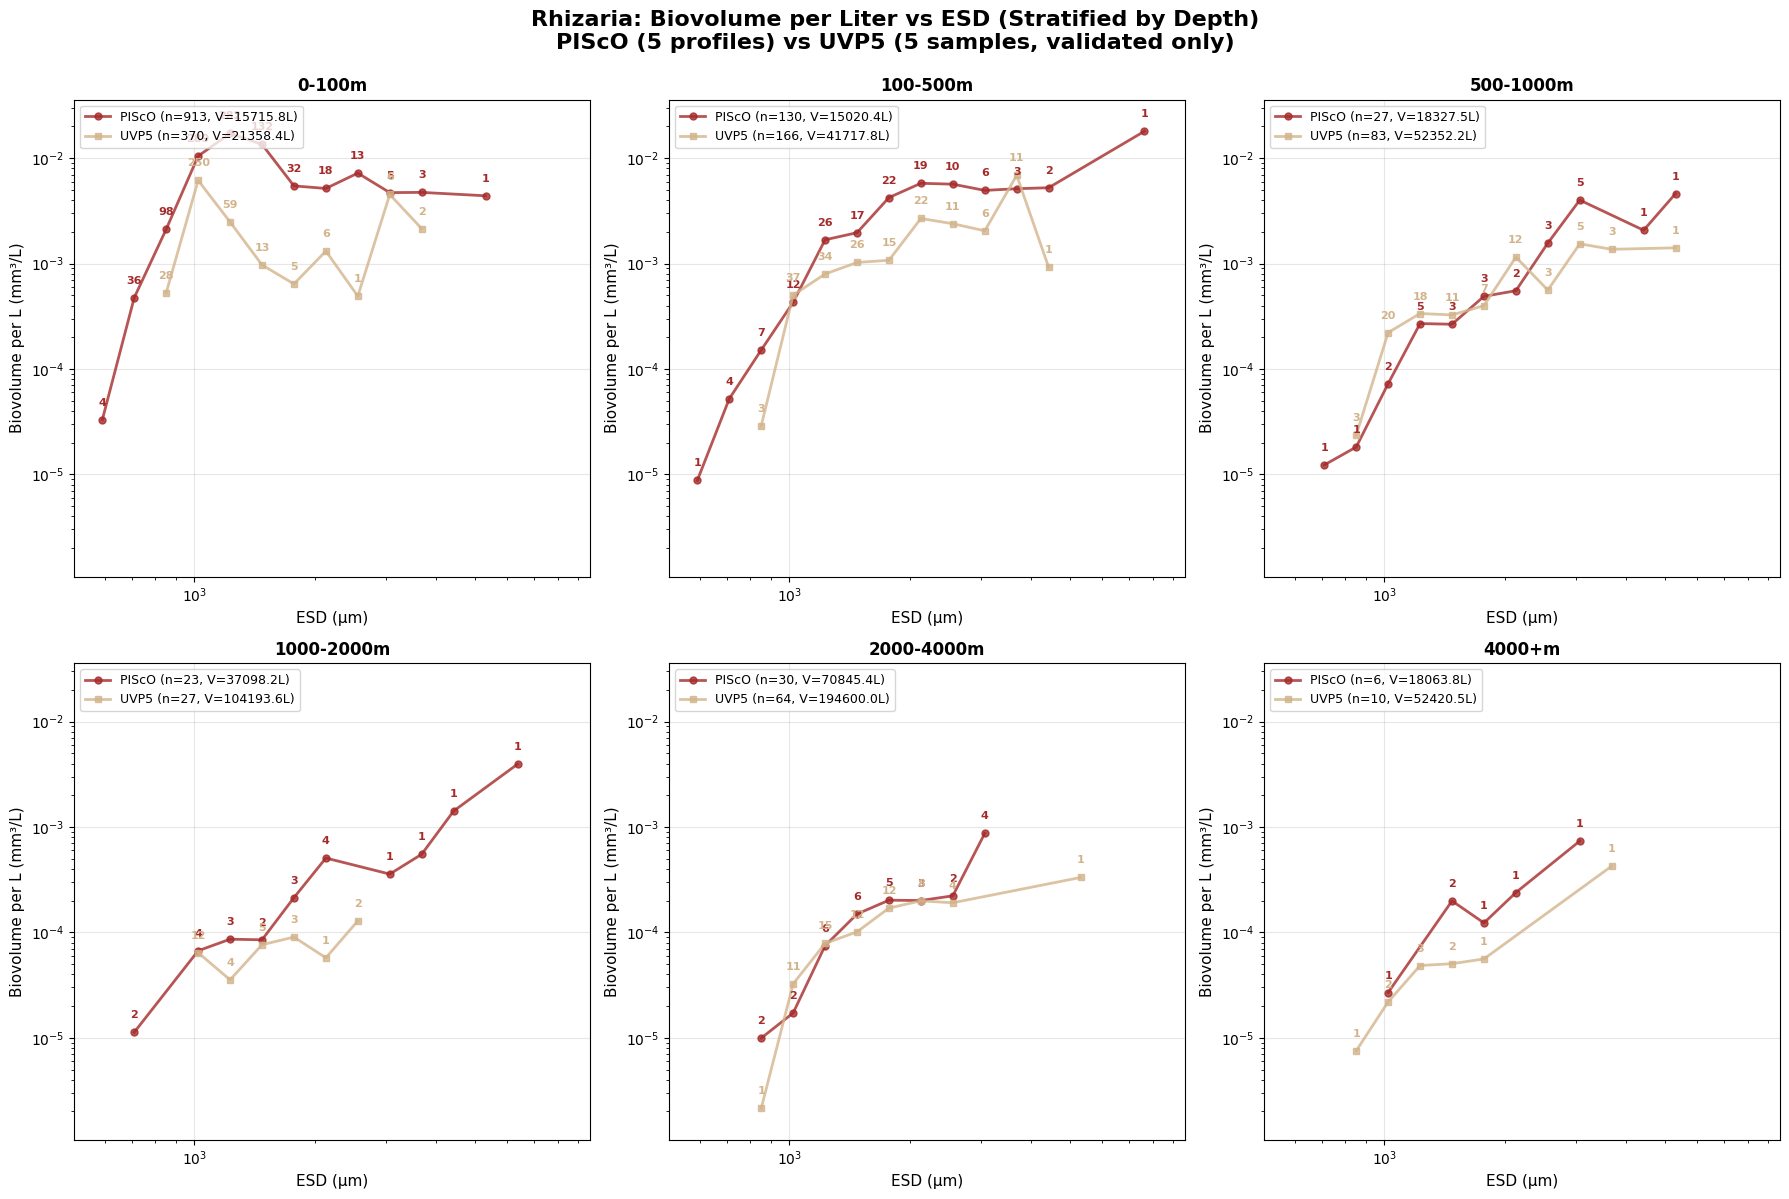


Rhizaria depth-stratified comparison figure saved to: /home/veit/PIScO_dev/Segmentation_results/pisco_vs_uvp5_rhizaria_biovolume_per_L_by_depth_multi_validated.png

RHIZARIA BIOVOLUME PER LITER BY DEPTH BIN:

0-100m:
------------------------------------------------------------
  PIScO:
    Rhizaria: 913
    Total biovolume: 1186.31 mm³
    Biovolume per L: 0.0755 mm³/L
  UVP5 (validated):
    Rhizaria: 370
    Total biovolume: 411.21 mm³
    Biovolume per L: 0.0193 mm³/L
  Ratio (PIScO/UVP5): 3.92x

100-500m:
------------------------------------------------------------
  PIScO:
    Rhizaria: 130
    Total biovolume: 800.45 mm³
    Biovolume per L: 0.0533 mm³/L
  UVP5 (validated):
    Rhizaria: 166
    Total biovolume: 765.03 mm³
    Biovolume per L: 0.0183 mm³/L
  Ratio (PIScO/UVP5): 2.91x

500-1000m:
------------------------------------------------------------
  PIScO:
    Rhizaria: 27
    Total biovolume: 255.39 mm³
    Biovolume per L: 0.0139 mm³/L
  UVP5 (validated):
    Rhizaria:

In [25]:

# ============ PROCESS RHIZARIA FOR MULTIPLE PROFILES ============
print("\n" + "="*80)
print("PROCESSING RHIZARIA - MULTIPLE PROFILES")
print("="*80)

all_rhizaria_pisco = []
# Reuse all_pisco_volumes from copepod analysis (same volumes apply)

for profile_config in pisco_profiles:
    tsv_path = profile_config['tsv_path']
    profile_name = profile_config['profile_name']
    
    print(f"\nProcessing Rhizaria for PIScO profile: {profile_name}")
    
    # Read Rhizaria data
    df_pisco = pd.read_csv(tsv_path, sep='\t')
    df_pisco['pressure_dbar'] = df_pisco['object_pressure']
    
    # Filter for Rhizaria
    rhizaria_pisco = df_pisco[
        df_pisco['object_annotation_category'].str.contains('Rhizaria', case=False, na=False)
    ].copy()
    
    print(f"  Found {len(rhizaria_pisco)} Rhizaria")
    
    # Calculate biovolume
    rhizaria_pisco['esd_um'] = rhizaria_pisco['object_esd']
    esd_mm = rhizaria_pisco['esd_um'] / 1000
    rhizaria_pisco['biovolume_mm3'] = (np.pi / 6) * (esd_mm ** 3)
    
    # Assign depth bins
    rhizaria_pisco['depth_bin'] = pd.cut(rhizaria_pisco['pressure_dbar'], 
                                          bins=depth_bin_edges, 
                                          labels=depth_bin_labels,
                                          include_lowest=True,
                                          right=False)
    
    rhizaria_pisco['profile'] = profile_name
    all_rhizaria_pisco.append(rhizaria_pisco)

# Combine all PIScO Rhizaria data
rhizaria_pisco = pd.concat(all_rhizaria_pisco, ignore_index=True)

print(f"\n✅ Combined PIScO Rhizaria: {len(rhizaria_pisco)} individuals from {len(pisco_profiles)} profiles")


# ============ PROCESS UVP5 RHIZARIA (VALIDATED ONLY) ============
print("\n" + "="*80)
print("PROCESSING UVP5 RHIZARIA (VALIDATED ONLY)")
print("="*80)

# Filter for validated Rhizaria only
if 'object_annotation_status' in df_uvp5.columns:
    print("✅ Filtering for validated Rhizaria annotations only...")
    
    rhizaria_uvp5 = df_uvp5[
        (df_uvp5['object_annotation_category'].str.contains('Rhizaria', case=False, na=False)) &
        (df_uvp5['object_annotation_status'] == 'validated')
    ].copy()
    
    all_rhizaria = df_uvp5[df_uvp5['object_annotation_category'].str.contains('Rhizaria', case=False, na=False)]
    
    print(f"   Total UVP5 Rhizaria (all statuses): {len(all_rhizaria)}")
    print(f"   Total UVP5 validated Rhizaria: {len(rhizaria_uvp5)}")
    print(f"   Filtered out: {len(all_rhizaria) - len(rhizaria_uvp5)} ({100 * (len(all_rhizaria) - len(rhizaria_uvp5)) / max(len(all_rhizaria), 1):.1f}%)")
else:
    print("\n⚠️ WARNING: 'object_annotation_status' column not found! Using all Rhizaria.")
    rhizaria_uvp5 = df_uvp5[df_uvp5['object_annotation_category'].str.contains('Rhizaria', case=False, na=False)].copy()

print(f"✅ Combined UVP5 Rhizaria: {len(rhizaria_uvp5)} validated individuals from {len(uvp5_samples)} samples")

# Calculate biovolume
rhizaria_uvp5['esd_um'] = rhizaria_uvp5['object_esd'] * 88
esd_mm_uvp5 = rhizaria_uvp5['esd_um'] / 1000
rhizaria_uvp5['biovolume_mm3'] = (np.pi / 6) * (esd_mm_uvp5 ** 3)
rhizaria_uvp5['pressure_dbar'] = rhizaria_uvp5['object_depth_min']

# Assign depth bins
rhizaria_uvp5['depth_bin'] = pd.cut(rhizaria_uvp5['pressure_dbar'], 
                                     bins=depth_bin_edges, 
                                     labels=depth_bin_labels,
                                     include_lowest=True,
                                     right=False)


# ============ BIN RHIZARIA BY ESD ============
rhizaria_pisco['esd_bin'] = pd.cut(rhizaria_pisco['esd_um'], bins=esd_bin_edges)
rhizaria_uvp5['esd_bin'] = pd.cut(rhizaria_uvp5['esd_um'], bins=esd_bin_edges)


# ============ DETERMINE GLOBAL AXIS LIMITS FOR RHIZARIA ============
all_esd_pisco_rhizaria = []
all_esd_uvp5_rhizaria = []
all_biovol_pisco_rhizaria = []
all_biovol_uvp5_rhizaria = []

for depth_label in depth_bin_labels:
    pisco_depth = rhizaria_pisco[rhizaria_pisco['depth_bin'] == depth_label]
    uvp5_depth = rhizaria_uvp5[rhizaria_uvp5['depth_bin'] == depth_label]
    
    pisco_volume = pisco_depth_volumes.get(depth_label, 0)
    uvp5_volume = uvp5_depth_volumes.get(depth_label, 0)
    
    if len(pisco_depth) > 0 and pisco_volume > 0:
        pisco_binned = pisco_depth.groupby('esd_bin', observed=True).agg({
            'esd_um': 'mean',
            'biovolume_mm3': 'sum'
        }).dropna().reset_index(drop=True)
        pisco_binned['biovolume_mm3_per_L'] = pisco_binned['biovolume_mm3'] / pisco_volume
        
        all_esd_pisco_rhizaria.extend(pisco_binned['esd_um'].tolist())
        all_biovol_pisco_rhizaria.extend(pisco_binned['biovolume_mm3_per_L'].tolist())
    
    if len(uvp5_depth) > 0 and uvp5_volume > 0:
        uvp5_binned = uvp5_depth.groupby('esd_bin', observed=True).agg({
            'esd_um': 'mean',
            'biovolume_mm3': 'sum'
        }).dropna().reset_index(drop=True)
        uvp5_binned['biovolume_mm3_per_L'] = uvp5_binned['biovolume_mm3'] / uvp5_volume
        
        all_esd_uvp5_rhizaria.extend(uvp5_binned['esd_um'].tolist())
        all_biovol_uvp5_rhizaria.extend(uvp5_binned['biovolume_mm3_per_L'].tolist())

if all_esd_pisco_rhizaria or all_esd_uvp5_rhizaria:
    all_esd_rhizaria = all_esd_pisco_rhizaria + all_esd_uvp5_rhizaria
    esd_min_rhizaria = min(all_esd_rhizaria) * 0.8
    esd_max_rhizaria = max(all_esd_rhizaria) * 1.2
else:
    esd_min_rhizaria, esd_max_rhizaria = 50, 10000

if all_biovol_pisco_rhizaria or all_biovol_uvp5_rhizaria:
    all_biovol_rhizaria = all_biovol_pisco_rhizaria + all_biovol_uvp5_rhizaria
    biovol_min_rhizaria = min(all_biovol_rhizaria) * 0.5
    biovol_max_rhizaria = max(all_biovol_rhizaria) * 2
else:
    biovol_min_rhizaria, biovol_max_rhizaria = 1e-6, 1e-1

print(f"\n✅ Global axis limits for Rhizaria:")
print(f"   ESD: {esd_min_rhizaria:.1f} - {esd_max_rhizaria:.1f} µm")
print(f"   Biovolume per L: {biovol_min_rhizaria:.6f} - {biovol_max_rhizaria:.6f} mm³/L")


# ============ PLOT RHIZARIA ============
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, depth_label in enumerate(depth_bin_labels):
    ax = axes[idx]
    
    pisco_depth = rhizaria_pisco[rhizaria_pisco['depth_bin'] == depth_label].copy()
    uvp5_depth = rhizaria_uvp5[rhizaria_uvp5['depth_bin'] == depth_label].copy()
    
    pisco_volume = pisco_depth_volumes.get(depth_label, 0)
    uvp5_volume = uvp5_depth_volumes.get(depth_label, 0)
    
    if len(pisco_depth) > 0 and pisco_volume > 0:
        pisco_binned = pisco_depth.groupby('esd_bin', observed=True).agg({
            'esd_um': 'mean',
            'biovolume_mm3': 'sum',
            'depth_bin': 'size'
        }).rename(columns={'depth_bin': 'n_objects'}).dropna()
        
        pisco_binned['esd_bin_center'] = pisco_binned.index.map(lambda x: (x.left + x.right) / 2)
        pisco_binned = pisco_binned.reset_index(drop=True)
        pisco_binned['biovolume_mm3_per_L'] = pisco_binned['biovolume_mm3'] / pisco_volume

        ax.plot(pisco_binned['esd_bin_center'], pisco_binned['biovolume_mm3_per_L'],
                marker='o', linewidth=2, markersize=5,
                label=f'PIScO (n={len(pisco_depth)}, V={pisco_volume:.1f}L)',
                color='brown', alpha=0.8)
        
        for _, row in pisco_binned.iterrows():
            ax.text(row['esd_bin_center'], row['biovolume_mm3_per_L'] * 1.3,
                   f"{int(row['n_objects'])}", 
                   ha='center', va='bottom', fontsize=8, 
                   color='brown', fontweight='bold')
    
    if len(uvp5_depth) > 0 and uvp5_volume > 0:
        uvp5_binned = uvp5_depth.groupby('esd_bin', observed=True).agg({
            'esd_um': 'mean',
            'biovolume_mm3': 'sum',
            'depth_bin': 'size'
        }).rename(columns={'depth_bin': 'n_objects'}).dropna()
        
        uvp5_binned['esd_bin_center'] = uvp5_binned.index.map(lambda x: (x.left + x.right) / 2)
        uvp5_binned = uvp5_binned.reset_index(drop=True)
        uvp5_binned['biovolume_mm3_per_L'] = uvp5_binned['biovolume_mm3'] / uvp5_volume
        
        ax.plot(uvp5_binned['esd_bin_center'], uvp5_binned['biovolume_mm3_per_L'],
                marker='s', linewidth=2, markersize=5,
                label=f'UVP5 (n={len(uvp5_depth)}, V={uvp5_volume:.1f}L)',
                color='tan', alpha=0.8)
        
        for _, row in uvp5_binned.iterrows():
            ax.text(row['esd_bin_center'], row['biovolume_mm3_per_L'] * 1.3,
                   f"{int(row['n_objects'])}", 
                   ha='center', va='bottom', fontsize=8,
                   color='tan', fontweight='bold')
    
    ax.set_xlabel('ESD (µm)', fontsize=11)
    ax.set_ylabel('Biovolume per L (mm³/L)', fontsize=11)
    ax.set_title(f'{depth_label}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(esd_min_rhizaria, esd_max_rhizaria)
    ax.set_ylim(biovol_min_rhizaria, biovol_max_rhizaria)

plt.suptitle(f'Rhizaria: Biovolume per Liter vs ESD (Stratified by Depth)\nPIScO ({len(pisco_profiles)} profiles) vs UVP5 ({len(uvp5_samples)} samples, validated only)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Save figure
fig_path = "/home/veit/PIScO_dev/Segmentation_results/pisco_vs_uvp5_rhizaria_biovolume_per_L_by_depth_multi_validated.png"
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\nRhizaria depth-stratified comparison figure saved to: {fig_path}")


# ============ PRINT RHIZARIA STATISTICS BY DEPTH BIN ============
print("\n" + "="*80)
print("RHIZARIA BIOVOLUME PER LITER BY DEPTH BIN:")
print("="*80)

for depth_label in depth_bin_labels:
    print(f"\n{depth_label}:")
    print("-" * 60)
    
    pisco_depth = rhizaria_pisco[rhizaria_pisco['depth_bin'] == depth_label]
    uvp5_depth = rhizaria_uvp5[rhizaria_uvp5['depth_bin'] == depth_label]
    
    pisco_volume = pisco_depth_volumes.get(depth_label, 0)
    uvp5_volume = uvp5_depth_volumes.get(depth_label, 0)
    
    if len(pisco_depth) > 0 and pisco_volume > 0:
        pisco_total_biovol = pisco_depth['biovolume_mm3'].sum()
        print(f"  PIScO:")
        print(f"    Rhizaria: {len(pisco_depth)}")
        print(f"    Total biovolume: {pisco_total_biovol:.2f} mm³")
        print(f"    Biovolume per L: {pisco_total_biovol / pisco_volume:.4f} mm³/L")
    else:
        print(f"  PIScO: No data")
    
    if len(uvp5_depth) > 0 and uvp5_volume > 0:
        uvp5_total_biovol = uvp5_depth['biovolume_mm3'].sum()
        print(f"  UVP5 (validated):")
        print(f"    Rhizaria: {len(uvp5_depth)}")
        print(f"    Total biovolume: {uvp5_total_biovol:.2f} mm³")
        print(f"    Biovolume per L: {uvp5_total_biovol / uvp5_volume:.4f} mm³/L")
    else:
        print(f"  UVP5 (validated): No data")
    
    if len(pisco_depth) > 0 and len(uvp5_depth) > 0 and pisco_volume > 0 and uvp5_volume > 0:
        ratio = (pisco_depth['biovolume_mm3'].sum() / pisco_volume) / (uvp5_depth['biovolume_mm3'].sum() / uvp5_volume)
        print(f"  Ratio (PIScO/UVP5): {ratio:.2f}x")

print("\n" + "="*80)
print("OVERALL RHIZARIA SUMMARY:")
print("="*80)
print(f"\nPIScO: {len(rhizaria_pisco)} individuals from {len(pisco_profiles)} profiles")
print(f"UVP5 (validated): {len(rhizaria_uvp5)} individuals from {len(uvp5_samples)} samples")


PROCESSING THALIACEA - MULTIPLE PROFILES

Processing Thaliacea for PIScO profile: M181-175-1_CTD-050_00°00S-019°00W_20220509-0543
  Found 45 Thaliacea

Processing Thaliacea for PIScO profile: M181-112-1_CTD-037_00°00S-008°00W_20220504-1758
  Found 21 Thaliacea

Processing Thaliacea for PIScO profile: M181-227-1_CTD-060_00°00S-027°00W_20220512-1748
  Found 8 Thaliacea

Processing Thaliacea for PIScO profile: M181-285-1_CTD-075_00°00S-039°00W_20220517-2024
  Found 10 Thaliacea

Processing Thaliacea for PIScO profile: M181-297-1_CTD-081_00°00S-041°50W_20220519-0218
  Found 6 Thaliacea

✅ Combined PIScO Thaliacea: 90 individuals from 5 profiles

PROCESSING UVP5 THALIACEA (VALIDATED ONLY)
✅ Filtering for validated Thaliacea annotations only...
   Total UVP5 Thaliacea (all statuses): 0
   Total UVP5 validated Thaliacea: 0
   Filtered out: 0 (0.0%)
✅ Combined UVP5 Thaliacea: 0 validated individuals from 5 samples

✅ Global axis limits for Thaliacea:
   ESD: 777.6 - 11960.1 µm
   Biovolume pe

/tmp/ipykernel_699094/931723019.py:203: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9, loc='upper left')


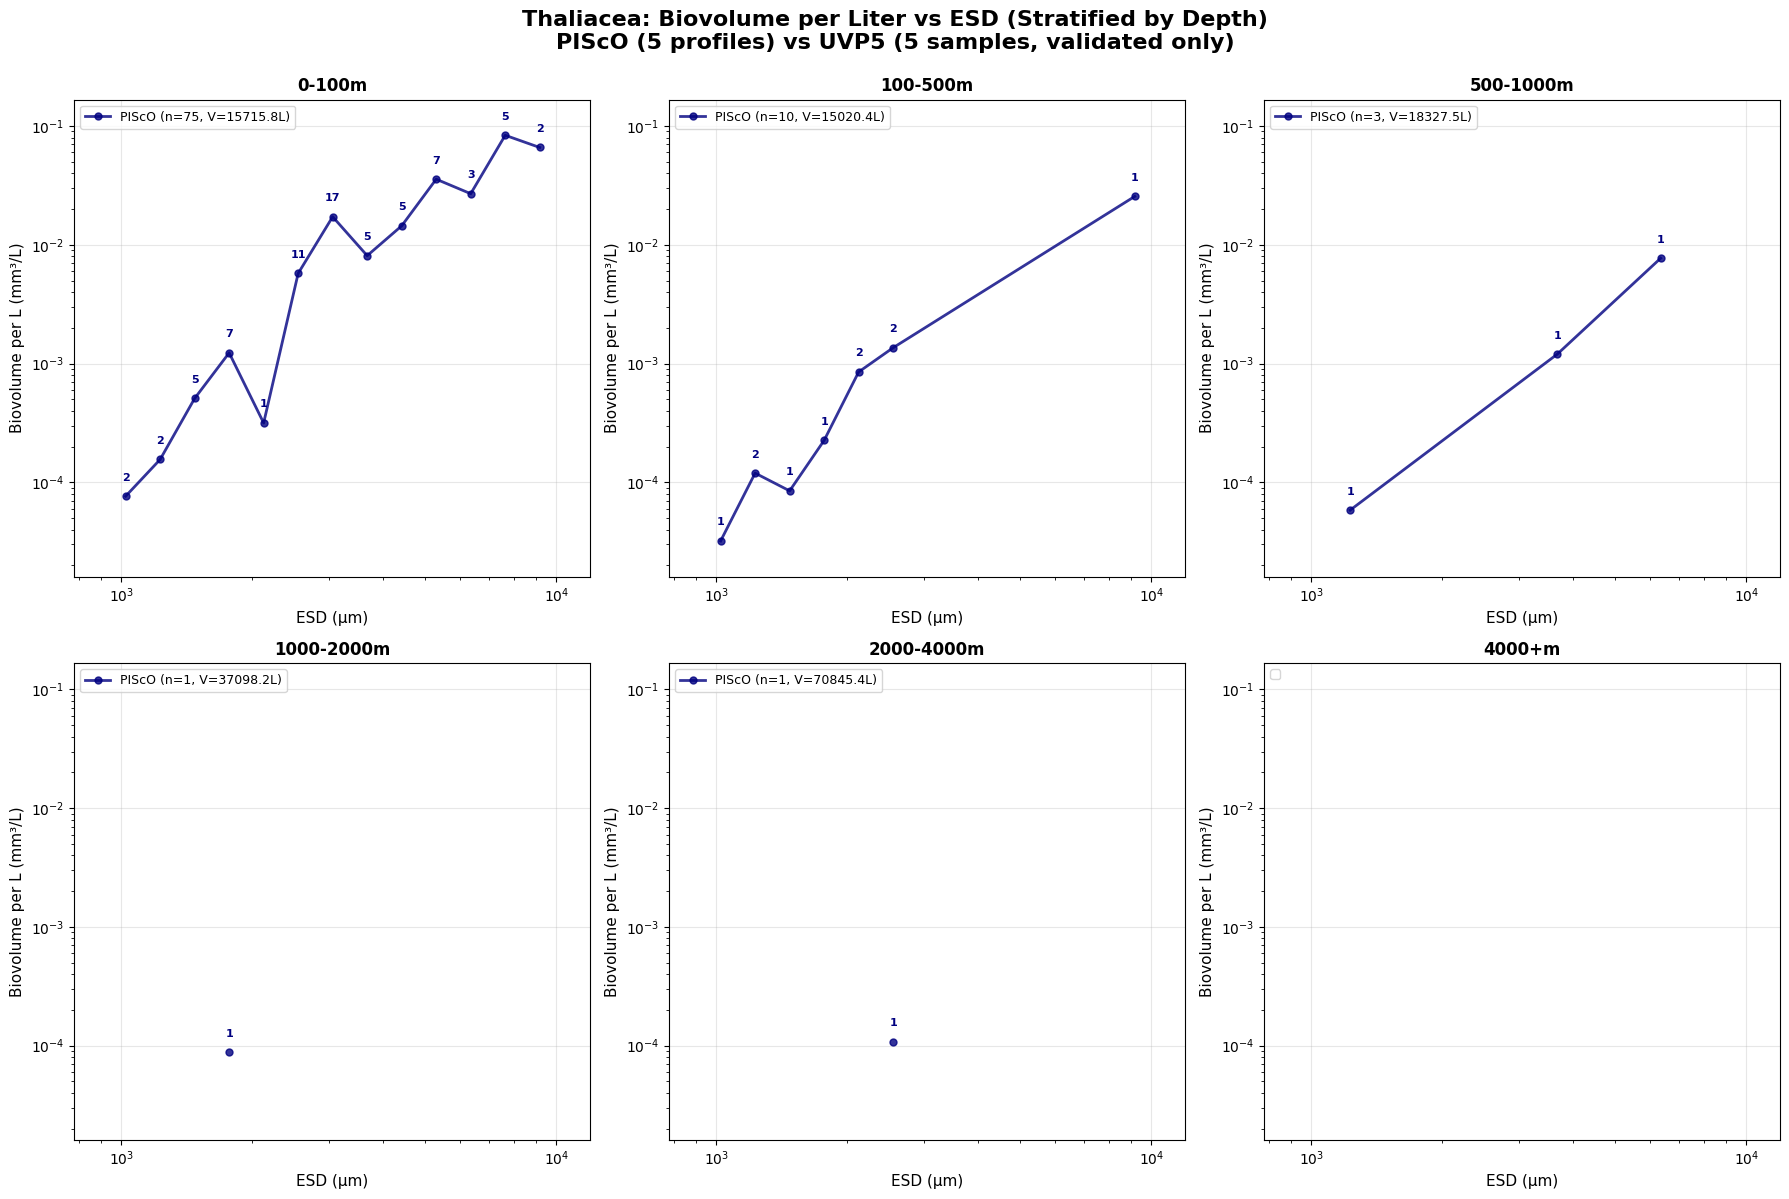


Thaliacea depth-stratified comparison figure saved to: /home/veit/PIScO_dev/Segmentation_results/pisco_vs_uvp5_thaliacea_biovolume_per_L_by_depth_multi_validated.png

THALIACEA BIOVOLUME PER LITER BY DEPTH BIN:

0-100m:
------------------------------------------------------------
  PIScO:
    Thaliacea: 75
    Total biovolume: 6662.40 mm³
    Biovolume per L: 0.4239 mm³/L
  UVP5 (validated): No data

100-500m:
------------------------------------------------------------
  PIScO:
    Thaliacea: 10
    Total biovolume: 423.74 mm³
    Biovolume per L: 0.0282 mm³/L
  UVP5 (validated): No data

500-1000m:
------------------------------------------------------------
  PIScO:
    Thaliacea: 3
    Total biovolume: 164.31 mm³
    Biovolume per L: 0.0090 mm³/L
  UVP5 (validated): No data

1000-2000m:
------------------------------------------------------------
  PIScO:
    Thaliacea: 1
    Total biovolume: 3.27 mm³
    Biovolume per L: 0.0001 mm³/L
  UVP5 (validated): No data

2000-4000m:
-----

In [26]:


# ============ PROCESS THALIACEA FOR MULTIPLE PROFILES ============
print("\n" + "="*80)
print("PROCESSING THALIACEA - MULTIPLE PROFILES")
print("="*80)

all_thaliacea_pisco = []
# Reuse all_pisco_volumes from copepod analysis (same volumes apply)

for profile_config in pisco_profiles:
    tsv_path = profile_config['tsv_path']
    profile_name = profile_config['profile_name']
    
    print(f"\nProcessing Thaliacea for PIScO profile: {profile_name}")
    
    # Read Thaliacea data
    df_pisco = pd.read_csv(tsv_path, sep='\t')
    df_pisco['pressure_dbar'] = df_pisco['object_pressure']
    
    # Filter for Thaliacea
    thaliacea_pisco = df_pisco[
        df_pisco['object_annotation_category'].str.contains('Thaliacea', case=False, na=False)
    ].copy()
    
    print(f"  Found {len(thaliacea_pisco)} Thaliacea")
    
    # Calculate biovolume
    thaliacea_pisco['esd_um'] = thaliacea_pisco['object_esd']
    esd_mm = thaliacea_pisco['esd_um'] / 1000
    thaliacea_pisco['biovolume_mm3'] = (np.pi / 6) * (esd_mm ** 3)
    
    # Assign depth bins
    thaliacea_pisco['depth_bin'] = pd.cut(thaliacea_pisco['pressure_dbar'], 
                                           bins=depth_bin_edges, 
                                           labels=depth_bin_labels,
                                           include_lowest=True,
                                           right=False)
    
    thaliacea_pisco['profile'] = profile_name
    all_thaliacea_pisco.append(thaliacea_pisco)

# Combine all PIScO Thaliacea data
thaliacea_pisco = pd.concat(all_thaliacea_pisco, ignore_index=True)

print(f"\n✅ Combined PIScO Thaliacea: {len(thaliacea_pisco)} individuals from {len(pisco_profiles)} profiles")


# ============ PROCESS UVP5 THALIACEA (VALIDATED ONLY) ============
print("\n" + "="*80)
print("PROCESSING UVP5 THALIACEA (VALIDATED ONLY)")
print("="*80)

# Filter for validated Thaliacea only
if 'object_annotation_status' in df_uvp5.columns:
    print("✅ Filtering for validated Thaliacea annotations only...")
    
    thaliacea_uvp5 = df_uvp5[
        (df_uvp5['object_annotation_category'].str.contains('Thaliacea', case=False, na=False)) &
        (df_uvp5['object_annotation_status'] == 'validated')
    ].copy()
    
    all_thaliacea = df_uvp5[df_uvp5['object_annotation_category'].str.contains('Thaliacea', case=False, na=False)]
    
    print(f"   Total UVP5 Thaliacea (all statuses): {len(all_thaliacea)}")
    print(f"   Total UVP5 validated Thaliacea: {len(thaliacea_uvp5)}")
    print(f"   Filtered out: {len(all_thaliacea) - len(thaliacea_uvp5)} ({100 * (len(all_thaliacea) - len(thaliacea_uvp5)) / max(len(all_thaliacea), 1):.1f}%)")
else:
    print("\n⚠️ WARNING: 'object_annotation_status' column not found! Using all Thaliacea.")
    thaliacea_uvp5 = df_uvp5[df_uvp5['object_annotation_category'].str.contains('Thaliacea', case=False, na=False)].copy()

print(f"✅ Combined UVP5 Thaliacea: {len(thaliacea_uvp5)} validated individuals from {len(uvp5_samples)} samples")

# Calculate biovolume
thaliacea_uvp5['esd_um'] = thaliacea_uvp5['object_esd'] * 88
esd_mm_uvp5 = thaliacea_uvp5['esd_um'] / 1000
thaliacea_uvp5['biovolume_mm3'] = (np.pi / 6) * (esd_mm_uvp5 ** 3)
thaliacea_uvp5['pressure_dbar'] = thaliacea_uvp5['object_depth_min']

# Assign depth bins
thaliacea_uvp5['depth_bin'] = pd.cut(thaliacea_uvp5['pressure_dbar'], 
                                      bins=depth_bin_edges, 
                                      labels=depth_bin_labels,
                                      include_lowest=True,
                                      right=False)


# ============ BIN THALIACEA BY ESD ============
thaliacea_pisco['esd_bin'] = pd.cut(thaliacea_pisco['esd_um'], bins=esd_bin_edges)
thaliacea_uvp5['esd_bin'] = pd.cut(thaliacea_uvp5['esd_um'], bins=esd_bin_edges)


# ============ DETERMINE GLOBAL AXIS LIMITS FOR THALIACEA ============
all_esd_pisco_thaliacea = []
all_esd_uvp5_thaliacea = []
all_biovol_pisco_thaliacea = []
all_biovol_uvp5_thaliacea = []

for depth_label in depth_bin_labels:
    pisco_depth = thaliacea_pisco[thaliacea_pisco['depth_bin'] == depth_label]
    uvp5_depth = thaliacea_uvp5[thaliacea_uvp5['depth_bin'] == depth_label]
    
    pisco_volume = pisco_depth_volumes.get(depth_label, 0)
    uvp5_volume = uvp5_depth_volumes.get(depth_label, 0)
    
    if len(pisco_depth) > 0 and pisco_volume > 0:
        pisco_binned = pisco_depth.groupby('esd_bin', observed=True).agg({
            'esd_um': 'mean',
            'biovolume_mm3': 'sum'
        }).dropna().reset_index(drop=True)
        pisco_binned['biovolume_mm3_per_L'] = pisco_binned['biovolume_mm3'] / pisco_volume
        
        all_esd_pisco_thaliacea.extend(pisco_binned['esd_um'].tolist())
        all_biovol_pisco_thaliacea.extend(pisco_binned['biovolume_mm3_per_L'].tolist())
    
    if len(uvp5_depth) > 0 and uvp5_volume > 0:
        uvp5_binned = uvp5_depth.groupby('esd_bin', observed=True).agg({
            'esd_um': 'mean',
            'biovolume_mm3': 'sum'
        }).dropna().reset_index(drop=True)
        uvp5_binned['biovolume_mm3_per_L'] = uvp5_binned['biovolume_mm3'] / uvp5_volume
        
        all_esd_uvp5_thaliacea.extend(uvp5_binned['esd_um'].tolist())
        all_biovol_uvp5_thaliacea.extend(uvp5_binned['biovolume_mm3_per_L'].tolist())

if all_esd_pisco_thaliacea or all_esd_uvp5_thaliacea:
    all_esd_thaliacea = all_esd_pisco_thaliacea + all_esd_uvp5_thaliacea
    esd_min_thaliacea = min(all_esd_thaliacea) * 0.8
    esd_max_thaliacea = max(all_esd_thaliacea) * 1.2
else:
    esd_min_thaliacea, esd_max_thaliacea = 50, 10000

if all_biovol_pisco_thaliacea or all_biovol_uvp5_thaliacea:
    all_biovol_thaliacea = all_biovol_pisco_thaliacea + all_biovol_uvp5_thaliacea
    biovol_min_thaliacea = min(all_biovol_thaliacea) * 0.5
    biovol_max_thaliacea = max(all_biovol_thaliacea) * 2
else:
    biovol_min_thaliacea, biovol_max_thaliacea = 1e-6, 1e-1

print(f"\n✅ Global axis limits for Thaliacea:")
print(f"   ESD: {esd_min_thaliacea:.1f} - {esd_max_thaliacea:.1f} µm")
print(f"   Biovolume per L: {biovol_min_thaliacea:.6f} - {biovol_max_thaliacea:.6f} mm³/L")


# ============ PLOT THALIACEA ============
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, depth_label in enumerate(depth_bin_labels):
    ax = axes[idx]
    
    pisco_depth = thaliacea_pisco[thaliacea_pisco['depth_bin'] == depth_label].copy()
    uvp5_depth = thaliacea_uvp5[thaliacea_uvp5['depth_bin'] == depth_label].copy()
    
    pisco_volume = pisco_depth_volumes.get(depth_label, 0)
    uvp5_volume = uvp5_depth_volumes.get(depth_label, 0)
    
    if len(pisco_depth) > 0 and pisco_volume > 0:
        pisco_binned = pisco_depth.groupby('esd_bin', observed=True).agg({
            'esd_um': 'mean',
            'biovolume_mm3': 'sum',
            'depth_bin': 'size'
        }).rename(columns={'depth_bin': 'n_objects'}).dropna()
        
        pisco_binned['esd_bin_center'] = pisco_binned.index.map(lambda x: (x.left + x.right) / 2)
        pisco_binned = pisco_binned.reset_index(drop=True)
        pisco_binned['biovolume_mm3_per_L'] = pisco_binned['biovolume_mm3'] / pisco_volume

        ax.plot(pisco_binned['esd_bin_center'], pisco_binned['biovolume_mm3_per_L'],
                marker='o', linewidth=2, markersize=5,
                label=f'PIScO (n={len(pisco_depth)}, V={pisco_volume:.1f}L)',
                color='navy', alpha=0.8)
        
        for _, row in pisco_binned.iterrows():
            ax.text(row['esd_bin_center'], row['biovolume_mm3_per_L'] * 1.3,
                   f"{int(row['n_objects'])}", 
                   ha='center', va='bottom', fontsize=8, 
                   color='navy', fontweight='bold')
    
    if len(uvp5_depth) > 0 and uvp5_volume > 0:
        uvp5_binned = uvp5_depth.groupby('esd_bin', observed=True).agg({
            'esd_um': 'mean',
            'biovolume_mm3': 'sum',
            'depth_bin': 'size'
        }).rename(columns={'depth_bin': 'n_objects'}).dropna()
        
        uvp5_binned['esd_bin_center'] = uvp5_binned.index.map(lambda x: (x.left + x.right) / 2)
        uvp5_binned = uvp5_binned.reset_index(drop=True)
        uvp5_binned['biovolume_mm3_per_L'] = uvp5_binned['biovolume_mm3'] / uvp5_volume
        
        ax.plot(uvp5_binned['esd_bin_center'], uvp5_binned['biovolume_mm3_per_L'],
                marker='s', linewidth=2, markersize=5,
                label=f'UVP5 (n={len(uvp5_depth)}, V={uvp5_volume:.1f}L)',
                color='skyblue', alpha=0.8)
        
        for _, row in uvp5_binned.iterrows():
            ax.text(row['esd_bin_center'], row['biovolume_mm3_per_L'] * 1.3,
                   f"{int(row['n_objects'])}", 
                   ha='center', va='bottom', fontsize=8,
                   color='skyblue', fontweight='bold')
    
    ax.set_xlabel('ESD (µm)', fontsize=11)
    ax.set_ylabel('Biovolume per L (mm³/L)', fontsize=11)
    ax.set_title(f'{depth_label}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(esd_min_thaliacea, esd_max_thaliacea)
    ax.set_ylim(biovol_min_thaliacea, biovol_max_thaliacea)

plt.suptitle(f'Thaliacea: Biovolume per Liter vs ESD (Stratified by Depth)\nPIScO ({len(pisco_profiles)} profiles) vs UVP5 ({len(uvp5_samples)} samples, validated only)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Save figure
fig_path = "/home/veit/PIScO_dev/Segmentation_results/pisco_vs_uvp5_thaliacea_biovolume_per_L_by_depth_multi_validated.png"
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\nThaliacea depth-stratified comparison figure saved to: {fig_path}")


# ============ PRINT THALIACEA STATISTICS BY DEPTH BIN ============
print("\n" + "="*80)
print("THALIACEA BIOVOLUME PER LITER BY DEPTH BIN:")
print("="*80)

for depth_label in depth_bin_labels:
    print(f"\n{depth_label}:")
    print("-" * 60)
    
    pisco_depth = thaliacea_pisco[thaliacea_pisco['depth_bin'] == depth_label]
    uvp5_depth = thaliacea_uvp5[thaliacea_uvp5['depth_bin'] == depth_label]
    
    pisco_volume = pisco_depth_volumes.get(depth_label, 0)
    uvp5_volume = uvp5_depth_volumes.get(depth_label, 0)
    
    if len(pisco_depth) > 0 and pisco_volume > 0:
        pisco_total_biovol = pisco_depth['biovolume_mm3'].sum()
        print(f"  PIScO:")
        print(f"    Thaliacea: {len(pisco_depth)}")
        print(f"    Total biovolume: {pisco_total_biovol:.2f} mm³")
        print(f"    Biovolume per L: {pisco_total_biovol / pisco_volume:.4f} mm³/L")
    else:
        print(f"  PIScO: No data")
    
    if len(uvp5_depth) > 0 and uvp5_volume > 0:
        uvp5_total_biovol = uvp5_depth['biovolume_mm3'].sum()
        print(f"  UVP5 (validated):")
        print(f"    Thaliacea: {len(uvp5_depth)}")
        print(f"    Total biovolume: {uvp5_total_biovol:.2f} mm³")
        print(f"    Biovolume per L: {uvp5_total_biovol / uvp5_volume:.4f} mm³/L")
    else:
        print(f"  UVP5 (validated): No data")
    
    if len(pisco_depth) > 0 and len(uvp5_depth) > 0 and pisco_volume > 0 and uvp5_volume > 0:
        ratio = (pisco_depth['biovolume_mm3'].sum() / pisco_volume) / (uvp5_depth['biovolume_mm3'].sum() / uvp5_volume)
        print(f"  Ratio (PIScO/UVP5): {ratio:.2f}x")

print("\n" + "="*80)
print("OVERALL THALIACEA SUMMARY:")
print("="*80)
print(f"\nPIScO: {len(thaliacea_pisco)} individuals from {len(pisco_profiles)} profiles")
print(f"UVP5 (validated): {len(thaliacea_uvp5)} individuals from {len(uvp5_samples)} samples")